<a href="https://colab.research.google.com/github/IhkafAmeny/HSSF_Implementation/blob/main/Implementation_of_HSSF_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvcc --version
!nvidia-smi
#vérifier la version du compilateur NVIDIA CUDA
#CUDA : C++ étendu pour la programmation GPU

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0
/bin/bash: line 1: nvidia-smi: command not found


In [2]:
# Vérifiez si un GPU est disponible
import torch
torch.cuda.is_available()

False

In [3]:
# Cloner dans un dossier temporaire
!git clone https://github.com/YxMa666/HSSF.git /content/HSSF1

# Copier tous les fichiers dans le dossier de travail
!cp -r /content/HSSF1/* /content/

# Afficher les fichiers dans l’explorateur à gauche
!ls

Cloning into '/content/HSSF1'...
remote: Enumerating objects: 63, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 63 (delta 9), reused 60 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (63/63), 1.15 MiB | 3.60 MiB/s, done.
Resolving deltas: 100% (9/9), done.
data_split  fig  HSSF1	networks  README.md  sample_data  test.py  train.py  utils


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

<font color="#B22222"><h2>Dossier : /utils</h2></font>


<font color="Green"><h3> 1: Fichier : datasets.py</h3></font>





In [ ]:
import os #utilisé pour gérer les chemins de fichiers
from torch.utils.data import Dataset #créer une classe qui hérite de Dataset pour charger les images et les  masques.
from glob import glob #permet de trouver tous les fichiers correspondant à un motif dans un répertoire. exp : glob("data/*.png") va retourner tous les fichiers .png dans data/.
import numpy as np # manipuler des tableaux
import random
import json #charger des annotations ou paramètres stockés en .json.
from PIL import Image # le module Pillow (PIL) pour ouvrir et manipuler des images.
random.seed(42)
import torch # utilisé pour convertir les images/masques en tensors.
from torchvision import transforms  #Importe les transformations de données standard (redimensionnement, normalisation)
from utils.randaugment import RandAugmentMC #créer plus de diversité dans les données en modifiant les images (couleurs, contrastes, etc.).


*   args : objet contenant tous les paramètres nécessaires (chemins, taille)
*   dataset : nom du dataset (ex. : 'fundus' ou 'pathology')
*   transform : booléen, applique ou non les augmentations (par défaut True).
*   split : indique quelle partie du dataset charger ('labeled_train', 'unlabeled_train', 'val_list', 'test_list').
*   noise : booléen, active l’ajout de bruit aléatoire.


self = l’objet lui-même → permet de stocker et réutiliser ce qu’on a défini dans la classe.

exemple : self.valeur = valeur : on crée un attribut de l’objet x appelé valeur.
Plus tard, on accède à x.valeur via self.valeur.









**but de FEDDATASET**
Fournir un dataset personnalisable pour l’apprentissage semi-supervisé fédéré, en chargeant images, masques et contours avec ou sans augmentations (faibles/fortes), en fonction de si les données sont étiquetées ou non.

In [ ]:
class FEDDataset(Dataset): #FEDDataset hérite de torch.utils.data.Dataset. Cela signifie que la classe va avoir la structure de base d'un dataset PyTorch.
    """ FED Dataset """ #utilisée pour charger des images, masques et contours avec des augmentations adaptées à l’apprentissage semi-supervisé.
    def __init__(self, args, dataset, transform = True, split='labeled_train', noise=False):
        self.root_dir = os.path.join(args.img_path,args.data,dataset) #Construit le chemin complet vers les images
        self.split_dict = json.load(open(os.path.join(args.split_path,'{}-{}-{}.json'.format(args.data,str(args.labeled_ratio),str(args.datasets))),'r'))#Ouvre un fichier .json qui contient les listes des images pour chaque split (labeled, unlabeled...).

       #Stockage des paramètres et initialisation
        self.transform = transform
        self.trainsize = args.shape
        self.noise = noise
        self.noise_transform = RandomNoise()
        self.split = split # ['labeled_train', 'unlabeled_train', 'val_list', 'test_list']

        #Chargement de la liste d'images
        self.image_list = self.split_dict[dataset][split] #Récupère la liste des fichiers image correspondant au split choisi.
        print("total {} slices".format(len(self.image_list)))


        #Gestion des transformations d’image
        if self.transform:
            if split == 'unlabeled_train':
                print('unlabeled data Using RandomRotation, RandomFlip')
                self.weak = transforms.Compose([  #transformations légères (rotation, flips, crop).
                    transforms.RandomRotation(90, expand=False, center=None, fill=None),
                    transforms.RandomVerticalFlip(p=0.5),
                    transforms.RandomHorizontalFlip(p=0.5),
                    transforms.RandomCrop(size=self.trainsize,
                                        padding=int(self.trainsize*0.125),
                                        padding_mode='reflect'),
                    transforms.ToTensor(),
                    transforms.Normalize([0.5, 0.5, 0.5],
                                        [0.5, 0.5, 0.5])],)
                self.strong = transforms.Compose([ #transformations fortes (les mêmes + RandAugmentMC, augmentation aléatoire supplémentaire).
                    transforms.RandomRotation(90, expand=False, center=None, fill=None),
                    transforms.RandomVerticalFlip(p=0.5),
                    transforms.RandomHorizontalFlip(p=0.5),
                    transforms.RandomCrop(size=self.trainsize,
                                        padding=int(self.trainsize*0.125),
                                        padding_mode='reflect'),
                    RandAugmentMC(n=2, m=10),
                    transforms.ToTensor(),
                    transforms.Normalize([0.5, 0.5, 0.5],
                                        [0.5, 0.5, 0.5])])

                self.gt_transform = transforms.Compose([ #Transformation des masques (gt = ground truth) : rotation, flips, tensorisation.
                    transforms.RandomRotation(90, expand=False, center=None, fill=None),
                    transforms.RandomVerticalFlip(p=0.5),
                    transforms.RandomHorizontalFlip(p=0.5),
                    transforms.ToTensor()])

            else: #Cas des données étiquetées
                print('Using RandomRotation, RandomFlip')
                self.img_transform = transforms.Compose([ # transformations des images avec rotation, flip, normalisation
                    transforms.RandomRotation(90, expand=False, center=None, fill=None),
                    transforms.RandomVerticalFlip(p=0.5),
                    transforms.RandomHorizontalFlip(p=0.5),
                    transforms.ToTensor(),
                    transforms.Normalize([0.5, 0.5, 0.5],
                                        [0.5, 0.5, 0.5])
                    ])
                self.gt_transform = transforms.Compose([ # même chose pour les masques, sans normalisation (car ce sont des labels).
                    transforms.RandomRotation(90, expand=False, center=None, fill=None),
                    transforms.RandomVerticalFlip(p=0.5),
                    transforms.RandomHorizontalFlip(p=0.5),
                    transforms.ToTensor()])

        else:
            print('no augmentation')
            self.img_transform = transforms.Compose([
                transforms.ToTensor(), #pour convertir les images PIL en tenseurs.
                transforms.Normalize([0.5, 0.5, 0.5], #pour les images (pas les masques).
                                     [0.5, 0.5, 0.5])
                ])

            self.gt_transform = transforms.Compose([
                transforms.ToTensor()])

    def __len__(self):
        return len(self.image_list) #Utilisé par PyTorch pour connaître la taille du dataset.


    def __getitem__(self, idx):#Cette méthode est appelée quand on veut accéder à un échantillon précis du dataset
        idx = idx % len(self.image_list) #assurer que l’index idx utilisé pour accéder à un élément de la liste self.image_list ne dépasse pas la taille de la liste.

        #Chargement image, masque et contour
        image = self.rgb_loader(os.path.join(self.root_dir,'image',self.image_list[idx])) #RGB
        mask = self.binary_loader(os.path.join(self.root_dir,'mask',self.image_list[idx])) #segmentation
        boundary = self.binary_loader(os.path.join(self.root_dir,'boundary',self.image_list[idx]))
        image,mask,boundary = self.resize(image,mask,boundary) #Mise à l’échelle à la taille cible , Redimenssionnement

        if self.split == 'unlabeled_train':
            seed = np.random.randint(42) # make a seed with numpy generator
            random.seed(seed) # apply this seed to img tranfsorms
            torch.manual_seed(seed) # needed for torchvision 0.7
            w_image = self.weak(image)
            random.seed(seed) # apply this seed to img tranfsorms
            torch.manual_seed(seed) # needed for torchvision 0.7
            s_image = self.strong(image)
            # Transformer le masque et la bordure
            random.seed(seed) # apply this seed to img tranfsorms
            torch.manual_seed(seed) # needed for torchvision 0.7
            mask = self.gt_transform(mask)
            random.seed(seed) # apply this seed to img tranfsorms
            torch.manual_seed(seed) # needed for torchvision 0.7
            boundary = self.gt_transform(boundary)
        else:
            seed = np.random.randint(42) # make a seed with numpy generator
            random.seed(seed) # apply this seed to img tranfsorms
            torch.manual_seed(seed) # needed for torchvision 0.7
            image = self.img_transform(image)
            random.seed(seed) # apply this seed to img tranfsorms
            torch.manual_seed(seed) # needed for torchvision 0.7
            mask = self.gt_transform(mask)
            random.seed(seed) # apply this seed to img tranfsorms
            torch.manual_seed(seed) # needed for torchvision 0.7
            boundary = self.gt_transform(boundary)
            if self.noise:
                image = self.noise_transform(image)
        if self.split=='unlabeled_train':
            return w_image,s_image,self.image_list[idx]
        return image,(mask>0).to(torch.float),(boundary>0).to(torch.float),self.image_list[idx]

    def rgb_loader(self, path): #charge une image RGB
        with open(path, 'rb') as f:
            img = Image.open(f)
            return img.convert('RGB')

    def binary_loader(self, path): #charge un masque en niveau de gris
        with open(path, 'rb') as f:
            img = Image.open(f)
            # return img.convert('1')
            return img.convert('L')

    def resize(self, img, gt, boundary): #redimensionne image, masque, bordure
        assert img.size == gt.size == boundary.size
        w, h = img.size
        h = self.trainsize # max(h, self.trainsize)
        w = self.trainsize # max(w, self.trainsize)
        return img.resize((w, h), Image.Resampling.BILINEAR), gt.resize((w, h), Image.Resampling.NEAREST), boundary.resize((w, h), Image.Resampling.NEAREST) #Le masque et la bordure sont redimensionnés avec NEAREST (pour éviter le flou), et l’image RGB avec BILINEAR.

**but de class RandomNoise :**
Ajouter du bruit aléatoire contrôlé à une image, ce qui aide à l’augmentation des données et rend le modèle plus robuste aux perturbations (bruit d’acquisition, artefacts...).



In [ ]:
class RandomNoise(object): #Cette classe est utilisée comme transformation personnalisée pour ajouter du bruit aléatoire à une image. Cela aide à rendre les modèles plus robustes face à des variations ou du bruit dans les données d'entrée.
    def __init__(self, mu=0, sigma=0.1): #mu et sigma contrôlent la distribution du bruit qui sera ajouté.
        self.mu = mu
        self.sigma = sigma

    def __call__(self, image): #endre l’objet appelable comme une fonction
        noise = torch.clamp(
            torch.rand(image.size()) * self.sigma, -2 * self.sigma,
            2 * self.sigma)
        noise = noise + self.mu
        image = image + noise
        return image

**But de get_dataspilit :**
Créer une répartition personnalisée des images (labeled, unlabeled, validation, test) pour chaque client dans un cadre d’apprentissage fédéré semi-supervisé.
Le résultat est enregistré dans un fichier JSON et retourné sous forme de dictionnaire.

**Ratio :** Dans ton code, le ratio est utilisé pour définir quelle fraction d’un ensemble est annotée ou utilisée à une certaine étape

Si tu as 100 images dans un dataset, et un ratio de 0.3, cela veut dire :

30 images (30%) sont sélectionnées selon ce critère,

les 70 autres (70%) sont exclues ou utilisées différemment.


**Contexte d’utilisation**

Dans un environnement de federated learning semi-supervisé :

Un ou plusieurs clients ont toutes les images annotées (labeled_train),

D'autres clients n'ont qu'une partie annotée et le reste non (unlabeled_train),

Le tout est séparé aussi en val_list et test_list pour validation/test.

In [ ]:
def get_datasplit(args):
    """
    """# Initialise les paramètres : liste des datasets clients, ratios d’annotations, et crée le dossier de sauvegarde des splits s’il n'existe pas.
    data_root = os.path.join(args.img_path,args.data) # ../data/polyp
    client_datasets = args.datasets
    labeled_ratio = args.labeled_ratio # [1,0,0,0,0] # Liste des ratios de données annotées pour chaque client.Le premier client  est souvent complètement annoté (1), les autres non
    split_path = args.split_path # Chemin vers le dossier où sera sauvegardé le fichier .json contenant les splits (partitions).
    os.makedirs(split_path,exist_ok=True)

    assert len(labeled_ratio)==len(client_datasets),"the labeled_ratio is not equal to client_datasets" # Vérifie que chaque client a bien un ratio associé, sinon une erreur est levée.
    tra,val,test = args.train_val_test # 0.8:0.1:0.1 # Extrait les ratios d'entraînement, validation et test à partir de la liste train_val_test.

    split_dict = {}
    dict1 = {} #dictionnaire temporaire pour stocker les splits du client en cours.
    ind = 0 # indexe de client en cours
    img_list = os.listdir(os.path.join(data_root,client_datasets[ind],'image')) #Récupère tous les fichiers image (noms) du premier client
    random.shuffle(img_list) #Mélange aléatoirement les noms de fichiers pour éviter un biais d’ordre.

    img_length = len(img_list) #Nombre total d’images pour ce client.
    labeled_train = img_list
    dict1['labeled_train'] = labeled_train #Ajoute cette liste au dictionnaire temporaire.
    split_dict[client_datasets[ind]] = dict1 #  Associe ce dictionnaire au client courant dans split_dict.

    ind += 1 # Incrémente l’indice pour passer au client suivant.
    for dataset in client_datasets[1:]: #Débute la boucle sur les autres clients (hors premier).
        dict1 = {}
        img_list = os.listdir(os.path.join(data_root,dataset,'image'))
        random.shuffle(img_list)
        img_length = len(img_list)
        labeled_train = img_list[:int(img_length*tra*labeled_ratio[ind])]
        unlabeled_train = img_list[int(img_length*tra*labeled_ratio[ind]):int(img_length*tra)]
        val_list = img_list[int(img_length*tra):int(img_length*tra+img_length*val)]
        test_list = img_list[int(img_length*tra+img_length*val):]
        dict1['labeled_train'] = labeled_train
        dict1['unlabeled_train'] = unlabeled_train
        dict1['val_list'] = val_list
        dict1['test_list'] = test_list
        split_dict[dataset] = dict1
        ind+=1
    json.dump(split_dict,open(os.path.join(split_path,'{}-{}-{}.json'.format(args.data,str(args.labeled_ratio),str(args.datasets))),'w')) #Sauvegarde le dictionnaire split_dict dans un fichier JSON
    return split_dict

**But**


*  Définir les paramètres du traitement (args).

*  Appeler la fonction get_datasplit() pour créer les splits.
*  Charger le split généré (split_dict) depuis le fichier JSON.

*   Pour chaque dataset client :
Créer une instance FEDDataset avec le split de validation.

Sauvegarder localement quelques images, masques et bords pour vérification visuelle.

 <H3>Il Y a un prblm de DATASET

In [ ]:
if __name__ == "__main__":
 if __name__ == "__main__":
    # Création des arguments
    import argparse
    parser = argparse.ArgumentParser()
    # Define arguments and set default values
    parser.add_argument("--img_path", type=str, default='./data', help="Dossier contenant les données brutes")
    parser.add_argument("--data", type=str, default='polyp', help="Nom global du dataset utilisé")
    parser.add_argument("--datasets", type=str, nargs='+', default=['EndoTect-ETIS', 'CVC-300', 'CVC-ColonDB', 'CVC-ClinicDB', 'Kvasir'], help="Liste des datasets")
    parser.add_argument("--shape", type=int, default=384, help="Taille des images")
    parser.add_argument("--train_val_test", type=float, nargs=3, default=[0.7, 0.15, 0.15], help="Proportions pour les partitions")
    parser.add_argument("--labeled_ratio", type=float, nargs='+', default=[1, 0.5, 0, 0, 0], help="Pourcentage annoté par client")
    parser.add_argument("--split_path", type=str, default='./split_data', help="Chemin vers le dossier des splits")

    # Instead of parsing arguments from the command line, directly set them:
    args = parser.parse_args("") # Pass an empty string to avoid command line parsing

    # Manually set the values for each argument if needed
    args.img_path = './data'  # Dossier contenant les données brutes
    args.data = 'polyp'  # Nom global du dataset utilisé
    args.datasets = ['EndoTect-ETIS', 'CVC-300', 'CVC-ColonDB', 'CVC-ClinicDB', 'Kvasir']
    args.shape = 384  # Taille des images (recentrées ou redimensionnées à 384x384)
    args.train_val_test = (0.7, 0.15, 0.15)  # Proportions pour les partitions
    assert sum(args.train_val_test) == 1, "Training validation test division beyond limits"
    args.labeled_ratio = [1, 0.5, 0, 0, 0]  # Pourcentage annoté par client
    args.split_path = './split_data'

    # The rest of your code remains unchanged
    get_datasplit(args)
    split_dict = json.load(open('./split_data/polyp.json', 'r'))  # Où enregistrer le fichier JSON des splits

    # print(split_dict)
    #Chargement et test de chaque dataset client pour le split val_list
    for str1 in ['EndoTect-ETIS', 'CVC-300', 'CVC-ColonDB', 'CVC-ClinicDB', 'Kvasir']:
        dataset = FEDDataset(args=args, dataset=str1, transform = True, split = 'val_list', noise = True)
        print(str1,len(dataset))
  # Sauvegarde visuelle de quelques échantillons
    for i in dataset:
        import cv2
        cv2.imwrite('./img.jpg',((i[0]+1)/2*255).permute(1,2,0).numpy()[:,:,[2,1,0]])
        cv2.imwrite('./mask.jpg',(i[1]*255).squeeze(0).numpy())
        cv2.imwrite('./boundary.jpg',(i[2]*255).squeeze(0).numpy())
        print(i[3])

FileNotFoundError: [Errno 2] No such file or directory: './data/polyp/EndoTect-ETIS/image'

<font color="Green"><h3> 2: Fichier : Losses.py</h3></font>


In [ ]:
import torch
import torch.nn.functional as F #fournit des fonctions comme F.cross_entropy, F.mse_loss
import numpy as np
from torch.autograd import Variable #(historique) permettait de créer des tenseurs traçables dans l’autograd
import torch.nn as nn # utilisé pour déclarer des modules de pertes comme nn.CrossEntropyLoss(), nn.MSELoss().
import random
from PIL import Image #utilisé pour manipuler des images
try:
    import accimage #une bibliothèque d'accélération d'affichage pour les images
except ImportError:
    accimage = None
random.seed(42)

Basé sur les arguments (args) fournis , la fonction retourne :


*   boundary_criterion : pour la perte sur les contours ou bords.

*  seg_criterion : pour la perte de segmentation principale.
*   kl_criterion : pour une perte de divergence (souvent entre prédictions client/serveur en fédéré semi-supervisé).









In [ ]:
def init_loss(args):
    if args.boundary_loss == 'CE':
        boundary_criterion = nn.CrossEntropyLoss() #standard pour la classification multi-classes.

#boundary_criterion
    if args.boundary_loss == 'MSE':
        boundary_criterion = nn.MSELoss() #erreur quadratique moyenne.

    if args.boundary_loss == 'SCE':
        boundary_criterion = SCELoss(alpha=0.1, beta=1.0, num_classes=10) #Symmetric Cross Entropy, robuste aux données bruitées.

    if args.boundary_loss == 'FocalLoss':
        boundary_criterion = FocalLoss()#accentue les exemples difficiles, utile pour le déséquilibre.

    if args.boundary_loss == 'softmax_mse_loss':
        boundary_criterion = softmax_mse_loss() #version de MSE entre les softmax.

    if args.boundary_loss == 'mse_loss':
        boundary_criterion = mse_loss()

    if args.boundary_loss == 'cosine_similarity':
        boundary_criterion = cosine_similarity(softmax_t = args.softmax_t) #distance angulaire entre vecteurs de prédiction

#seg_criterion
    if args.seg_loss == 'structure_loss':
        seg_criterion = structure_loss() #ne perte personnalisée combinant BCE + IoU/contour.

    if args.seg_loss == 'softmax_dice_loss':
        seg_criterion = softmax_dice_loss() #Dice appliqué après softmax pour segmentation multi-classes.

    if args.seg_loss == 'dice_loss':
        seg_criterion = dice_loss()#Dice Loss classique (souvent pour binaire).


#Pour divergence entre distributions (ex : connaissances entre clients ou client/serveur), kl_criterion

    if args.kl_loss == 'kl_loss':
        kl_criterion = kl_loss(softmax_t = args.softmax_t) # KL divergence classique
    if args.kl_loss == 'softmax_mse_loss':
        kl_criterion = softmax_mse_loss()
    if args.kl_loss == 'mse_loss':
        kl_criterion = mse_loss()
    if args.kl_loss == 'kl_mse_loss':
        kl_criterion = kl_mse_loss(softmax_t = args.softmax_t)
    if args.kl_loss == 'cosine_similarity':
        kl_criterion = cosine_similarity(softmax_t = args.softmax_t)
    return boundary_criterion,seg_criterion,kl_criterion

Définition d’une fonction personnalisée de cross-entropy.

inputs : sorties du modèle, de taille (B, C, H, W) — logits non normalisés.

gt : masques de vérité terrain (ground truth), soit en format (B, H, W) (entiers) soit (B, C, H, W) (one-hot).

ignore_index : indice à ignorer dans la vérité terrain. Très courant pour masquer des régions non étiquetées.

Si gt est one-hot, on le convertit avec .argmax(1) pour obtenir des entiers de classe de taille (B, H, W).

Applique ensuite CrossEntropyLoss, qui attend des logits et des étiquettes entières.

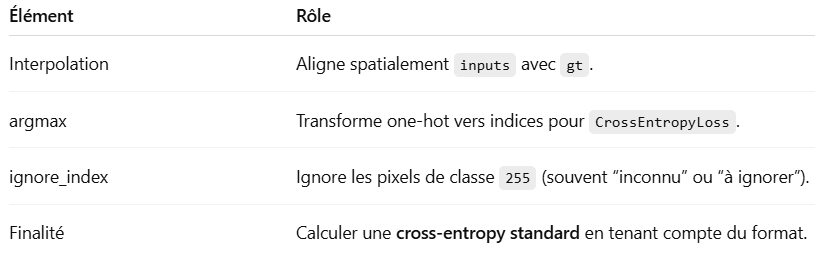

In [ ]:
def CEloss(inputs, gt, ignore_index=255):  # But : s’assurer que les dimensions sont compatibles pour appliquer une cross-entropie, avec masquage d’une classe si nécessaire (255 = ignore).
    if len(gt.size())==4:
        inputs = F.interpolate(
            inputs, size=gt.size()[2:], mode="bilinear", align_corners=True
        )
        return nn.CrossEntropyLoss(ignore_index=ignore_index)((inputs).to(torch.float), gt.argmax(1))
    else:
        return nn.CrossEntropyLoss(ignore_index=ignore_index)((inputs).to(torch.float), gt)

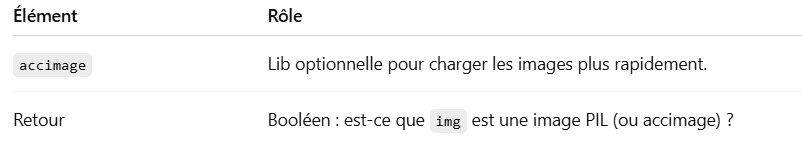

In [ ]:
def _is_pil_image(img): #vérifie si une image est au format PIL (ou accimage).
    if accimage is not None:
        return isinstance(img, (Image.Image, accimage.Image))
    else:
        return isinstance(img, Image.Image)

Le découpage aléatoire (random crop) est une technique d’augmentation de données (data augmentation) utilisée pour :

Augmenter la diversité des échantillons d'entraînement, même à partir d’une seule image.

Éviter le surapprentissage (overfitting) en exposant le modèle à différentes parties de l’image.

Renforcer l’invariance spatiale, en habituant le modèle à détecter des objets (polypes ici) peu importe leur position dans l’image.

Dans ce code spécifique : garantir que l’image, son masque, sa bordure et sa carte de confiance sont toujours alignées spatialement après crop → très important pour les tâches de segmentation.



In [ ]:
def crop(img, i, j, h, w): #Fonction qui recadre (crop) une image à partir d’un coin supérieur gauche (i, j) avec une taille (h, w).
    """Crop the given PIL Image.
    Args:
        img (PIL Image): Image to be cropped.
        i (int): i in (i,j) i.e coordinates of the upper left corner.
        j (int): j in (i,j) i.e coordinates of the upper left corner.
        h (int): Height of the cropped image.
        w (int): Width of the cropped image.
    Returns:
        PIL Image: Cropped image.
    """
    if not (_is_pil_image(img) or isinstance(img, torch.Tensor)): #Vérifie que img est soit une image PIL, soit un tenseur PyTorch.
        raise TypeError("img should be PIL Image. Got {}".format(type(img)))

    if _is_pil_image(img): #Si l’image est de type PIL, on appelle .crop((left, top, right, bottom)).
        return img.crop((j, i, j + w, i + h))

    return img[..., i : (i + h), j : (j + w)] #Sinon, si l’image est un tenseur PyTorch,

In [ ]:
class RandomCrop4(object): #Elle implémente une opération de crop aléatoire simultané sur 4 images (par exemple, image, masque, bordure, carte de confiance).
    def __init__(self, size):
        self.size = size

    @staticmethod
    def get_params(img, output_size): #Sert à calculer les coordonnées de découpe (i, j, h, w) en fonction d’une image img et d’une taille cible output_size.
        if len(img.shape) == 4:  # b x c x h x w #Si l’image est en batch (dimension 4D), on extrait la hauteur et la largeur à partir des dimensions 2 et 3
            h, w = img.shape[2:]
        elif len(img.shape) == 3:  # c x h x w #Si l’image est en 3D (sans batch), on prend la hauteur et la largeur depuis les indices 1 et 2

            h, w = img.shape[1:]
        else:
            raise NotImplementedError #Si les dimensions ne sont pas 3D ou 4D, une exception est levée.

        th, tw = output_size#écupération de la hauteur et de la largeur souhaitées pour le découpage.
        if w == tw and h == th: #Si la taille cible est égale à celle de l’image, on ne fait pas de découpe (crop démarre à (0,0)).
            return 0, 0, h, w

        i = random.randint(0, h - th)#Sinon, on génère aléatoirement un point de départ (i, j) pour faire un crop de taille (th, tw).
        j = random.randint(0, w - tw)
        return i, j, th, tw

    def __call__(self, i1, i2, i3, i4): #Méthode appelée lorsqu’on exécute crop_f(...) comme une fonction. Elle applique le même découpage aléatoire sur les 4 entrées i1, i2, i3, i4.
        # Pad if needed
        i, j, h, w = self.get_params(i1, self.size)

        i1 = crop(i1, i, j, h, w)
        i2 = crop(i2, i, j, h, w)
        i3 = crop(i3, i, j, h, w)
        i4 = crop(i4, i, j, h, w)

        return i1, i2, i3, i4 #Retourne les 4 images après découpage.

In [ ]:
#on crée une instance de la classe RandomCrop4 avec une taille de crop de 32x32.
crop_f = RandomCrop4(size=(32, 32))
#elle sera utilisée pour découper de manière aléatoire des patchs dans les tenseurs image, masque, etc., pour le calcul de la loss contrastive pixel-wise qui suit.

Cette fonction calcule une loss contrastive entre les pixels, en comparant des vecteurs d'embedding positifs et négatifs.

Elle est appelée dans une boucle par la fonction suivante pixelwisecontrastiveloss.

📌 Paramètres :
inputs : tenseur b x c x h x w – features du modèle.

target : tenseur b x c x h x w – vecteurs cibles (ex: features du teacher).

final_candidate : masque binaire b x h x w – indique les zones d'intérêt.

final_indices : indices des labels b x h x w pour regrouper les pixels selon leur classe.

elations suivantes :

Les pixels de même classe (même indice idx) doivent avoir des vecteurs proches dans l’espace des features.

Les pixels de classes différentes doivent avoir des vecteurs éloignés.

Cela aide le modèle à mieux structurer l’espace des représentations internes, ce qui est crucial :

En segmentation sémantique ou détection de bords.

Quand les données sont partiellement labellisées ou bruitées.

Dans un cadre de fédération, cela renforce la généralisation locale sans tout partager globalement.



In [ ]:
def batch_pixelwise_distanceloss(inputs, target, final_candidate, final_indices):
    # input : b x c x h x w
    # target : b x c x h x w
    # final_indicies : b x h x w

    assert ( #Vérifie que inputs et final_candidate ont bien les mêmes dimensions spatiales (h x w).
        inputs.size()[2:] == final_candidate.size()[1:]
    ), "input / final_candid : %s, %s" % (inputs.shape, final_candidate.shape)

    final_indices = torch.where(final_candidate == 1, final_indices, 255) #On masque les positions hors du final_candidate en les remplaçant par 255

    b_loss = 0
    label = torch.unique(final_indices)
    label = label[label != 255] #On extrait toutes les classes uniques sauf 255 (background ou non pertinent).


    # mask : b x h x w
    inputs = inputs.permute(1, 0, 2, 3)  # c x b x h x w
    target = target.permute(1, 0, 2, 3)  # c x b x h x w

    for idx in label:
        # if idx == 0:
        #     continue
        input_vec = inputs[:, (idx == final_indices)].T  # n x 128
        input_vec = input_vec / input_vec.norm(dim=1, keepdim=True).clamp(min=1e-8)

        pos_vec = target[:, (idx == final_indices)]  # 128 x n
        pos_vec = pos_vec / pos_vec.norm(dim=0, keepdim=True).clamp(min=1e-8)

        neg_v = target[:, (idx != final_indices) & (final_indices != 255)]  # 128 x m
        neg_v = neg_v / neg_v.norm(dim=0, keepdim=True).clamp(min=1e-8)

        pos_pair = torch.mm(input_vec, pos_vec)
        neg_pair = torch.mm(input_vec, neg_v)
        pos_pair = torch.exp(pos_pair / 0.5).to(torch.float64).sum().clamp(min=1e-8)
        neg_pair = torch.exp(neg_pair / 0.5).to(torch.float64).sum().clamp(min=1e-8)

        b_loss += -(torch.log(pos_pair / (neg_pair + pos_pair))) / torch.count_nonzero(
            (idx == final_indices).long()
        )

    if len(label) == 0: #Si aucune classe n’est présente → retourne 0.
        return 0
    else:
        return b_loss / len(label) #Sinon → loss moyenne par classe.

pixelwisecontrastiveloss applique une loss contrastive sur des sous-régions de l’image.

Elle renforce la cohérence locale et inter-classes des embeddings produits par le modèle.

Elle est utile pour des contextes semi-supervisés ou bruités.

In [ ]:
def pixelwisecontrastiveloss(inputs, target, final_candidate=None, final_indicies=None):

    assert final_candidate is not None

    tot_loss = 0
    crop_cnt = 8

    for _ in range(crop_cnt):
        cr_inputs, cr_target, cr_final_candid, cr_final_indicies = crop_f(
            inputs, target, final_candidate, final_indicies
        )

        tot_loss += batch_pixelwise_distanceloss(
            cr_inputs, cr_target, cr_final_candid, cr_final_indicies
        )
    return tot_loss / crop_cnt

confidence_loss est une fonction de perte pour entraîner un estimateur de confiance.
Elle apprend à prédire des scores de confiance élevés si la prédiction est correcte, et faibles sinon.
Elle est utile en semi-supervisé ou auto-étiquetage (self-training), pour peser les exemples fiables.

In [ ]:
class confidence_loss(nn.Module):
    """
    basic KD loss function based on "Distilling the Knowledge in a Neural Network"
    https://arxiv.org/abs/1503.02531
    :param input_logits: student score map
    :param target_logits: teacher score map
    :param T:  for softmax
    :return: loss value
    """
    def __init__(self):
        super(confidence_loss, self).__init__()
    def forward(self,predict, confidence,mask = None):
        input = predict.argmax(1)
        mask_l = mask.argmax(1)
        ind = (input==mask_l).to(torch.float)
        correction_loss = nn.BCEWithLogitsLoss(reduction="none")(confidence, ind.unsqueeze(1)) #Calcul de la Binary Cross-Entropy entre la confiance prédite et la vérité binaire (correct ou non).
        correction_loss.squeeze(1)[ind==0]*=((ind==1).sum()/(ind==0).sum())
        # correction_loss.squeeze(1)[ind==1]*=((ind==0).sum()/(ind==1).sum())
        # r_ind = 1-ind
        # conf = ((1-confidence)*ind + confidence*r_ind).mean()
        return correction_loss.mean()

Si un mask est fourni :

On calcule la KL divergence pixel par pixel (reduction='none').

On fait la moyenne sur les dimensions (canal, hauteur, largeur), puis on applique le masque.

Enfin, on prend la moyenne globale des pertes masquées.



In [ ]:
class kl_loss(nn.Module): #implémentation une fonction de perte basée sur la divergence de Kullback-Leibler (KL).
    """
    basic KD loss function based on "Distilling the Knowledge in a Neural Network"
    https://arxiv.org/abs/1503.02531
    :param input_logits: student score map
    :param target_logits: teacher score map
    :param T:  for softmax
    :return: loss value
    """
    def __init__(self,softmax_t):
        super(kl_loss, self).__init__()
        self.softmax_t = softmax_t
    def forward(self,input_logits, target_logits,mask = None):
        T = self.softmax_t
        assert input_logits.size() == target_logits.size()
        input_softmax = F.log_softmax(input_logits/T, dim=1)
        target_softmax = F.softmax(target_logits/T, dim=1)
        if mask is None:
            klloss = F.kl_div(input_softmax, target_softmax,reduction='batchmean')

            return klloss
        else:
            klloss = (F.kl_div(input_softmax, target_softmax,reduction='none')).mean((1,2,3))*mask
            return klloss.mean()


Cette classe implémente une fonction de perte basée sur la similarité cosinus entre les sorties du student et du teacher. Elle est utilisée en Knowledge Distillation pour rapprocher l’orientation (direction vectorielle) des prédictions du student de celles du teacher.

In [ ]:
class cosine_similarity(nn.Module):
    """
    :param input_logits: student score map
    :param target_logits: teacher score map
    :return: loss value
    """
    def __init__(self,softmax_t):
        super(cosine_similarity, self).__init__()
        self.softmax_t = softmax_t
    def forward(self,input_logits, target_logits):
        T = self.softmax_t
        assert input_logits.size() == target_logits.size()
        input_softmax = F.log_softmax(input_logits/T, dim=1)
        target_softmax = F.softmax(target_logits/T, dim=1)
        input_softmax = input_softmax.view(-1, 2)
        target_softmax = target_softmax.view(-1, 2)
        cosine_similarity_loss = ((1-F.cosine_similarity(input_softmax, target_softmax,dim=0)).mean())* (T ** 2)


        return cosine_similarity_loss

Cette classe combine deux types de pertes :

KL divergence (pour distillation des connaissances — "Knowledge Distillation").

MSE (pour encourager la correspondance directe des sorties).

Cela permet d’entraîner un modèle étudiant à imiter un modèle enseignant à la fois sur les distributions de probabilité (KL) et sur les valeurs brutes (MSE).
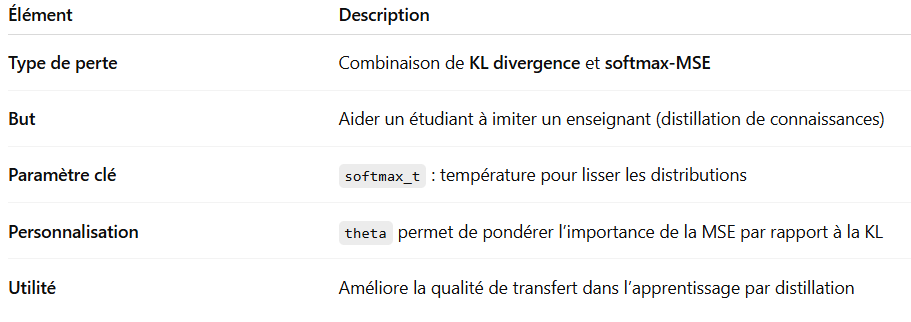


In [ ]:
class kl_mse_loss(nn.Module):
    """
    kl and mse
    """
    def __init__(self,softmax_t):
        super(kl_mse_loss, self).__init__()
        self.softmax_t = softmax_t
        self.soft_mse_loss = softmax_mse_loss()
    def forward(self,input_logits, target_logits,theta =1):
        T = self.softmax_t
        assert input_logits.size() == target_logits.size()
        mseloss = self.soft_mse_loss(input_logits, target_logits)
        input_softmax = F.log_softmax(input_logits/T, dim=1)
        target_softmax = F.softmax(target_logits/T, dim=1)
        input_softmax = input_softmax.view(-1, 2)
        target_softmax = target_softmax.view(-1, 2)

        klloss = F.kl_div(input_softmax, target_softmax,reduction = "batchmean") * (T ** 2)
        klloss = klloss + theta*mseloss
        return klloss

In [ ]:
class softmax_mse_loss(nn.Module):
    """Takes softmax on both sides and returns MSE loss

    Note:
    - Returns the sum over all examples. Divide by the batch size afterwards
      if you want the mean.
    - Sends gradients to inputs but not the targets.
    """
    def __init__(self):
        super(softmax_mse_loss, self).__init__()
    def forward(self,input_logits, target_logits, use_weight = True):
        assert input_logits.size() == target_logits.size()
        input_softmax = F.softmax(input_logits, dim=1)
        target_softmax = F.softmax(target_logits, dim=1)
        if use_weight:
            softmseloss =0.0
            allsum = target_logits.shape[-1]*target_logits.shape[-2]
            for i in range(target_softmax.shape[1]):
                softmseloss += ((allsum/target_softmax[:,i].sum())*(input_softmax[:,i] - target_softmax[:,i])**2).mean()
            softmseloss = softmseloss/target_softmax.shape[1]
        else:
            softmseloss = ((input_softmax - target_softmax)**2).sum()
        return softmseloss


In [ ]:
class mse_loss(nn.Module):
    """Takes softmax on both sides and returns MSE loss

    Note:
    - Returns the sum over all examples. Divide by the batch size afterwards
      if you want the mean.
    - Sends gradients to inputs but not the targets.
    """
    def __init__(self):
        super(mse_loss, self).__init__()
    def forward(self,input_logits, target_logits, use_weight = True):
        assert input_logits.size() == target_logits.size()
        # input_softmax = F.softmax(input_logits, dim=1)
        # target_softmax = F.softmax(target_logits, dim=1)
        input_softmax = input_logits
        target_softmax = target_logits
        if use_weight:
            mseloss =0.0
            allsum = target_logits.shape[-1]*target_logits.shape[-2]
            for i in range(target_softmax.shape[1]):
                weight = F.softmax(target_softmax,1).sum(-1).sum(-1)[:,i]/allsum
                mseloss += (weight*((input_softmax[:,i] - target_softmax[:,i])**2).sum(-1).sum(-1)/allsum).mean()
            mseloss = mseloss/target_softmax.shape[1]
        else:
            mseloss = ((input_softmax - target_softmax)**2).sum()
        return mseloss

In [ ]:
class dice_loss(nn.Module):
    """Takes softmax on both sides and returns MSE loss
        Note:
        - Returns the sum over all examples. Divide by the batch size afterwards
        if you want the mean.
        - Sends gradients to inputs but not the targets.
        """
    def __init__(self):
        super(dice_loss, self).__init__()
    def forward(self,input_logits, target_logits):
        assert input_logits.size() == target_logits.size()
        input_softmax = input_logits
        target_softmax = target_logits
        n = input_logits.shape[1]
        dice = 0
        for i in range(0, n):
            dice += dice_loss1(input_softmax[:, i], target_softmax[:, i])
        mean_dice = dice / n

        return mean_dice

In [ ]:
class softmax_dice_loss(nn.Module):
    """Takes softmax on both sides and returns MSE loss
        Note:
        - Returns the sum over all examples. Divide by the batch size afterwards
        if you want the mean.
        - Sends gradients to inputs but not the targets.
        """
    def __init__(self):
        super(softmax_dice_loss, self).__init__()
    def forward(self,input_logits, target_logits):
        assert input_logits.size() == target_logits.size()
        input_softmax = F.softmax(input_logits, dim=1)
        target_softmax = F.softmax(target_logits, dim=1)
        n = input_logits.shape[1]
        dice = 0
        for i in range(0, n):
            dice += dice_loss1(input_softmax[:, i], target_softmax[:, i])
        mean_dice = dice / n

        return mean_dice

In [ ]:
def dice_loss1(score, target):
    target = target.float()
    smooth = 1e-5
    intersect = torch.sum(score * target)
    y_sum = torch.sum(target)
    z_sum = torch.sum(score)
    loss = (2 * intersect + smooth) / (z_sum + y_sum + smooth)
    loss = 1 - loss
    return loss

structure_loss combine une version pondérée de la Cross Entropy (CE) et une forme pondérée de l’IoU (Intersection over Union). L’idée est d’améliorer la qualité des prédictions sur les objets avec des contours complexes ou des régions peu visibles dans des tâches de segmentation.

pred : la prédiction brute du modèle (logits).

mask : le masque de vérité terrain (ground truth), binaire ou catégoriel.

weight : une pondération optionnelle pour certaines zones.

In [ ]:
class structure_loss(nn.Module):

    def __init__(self):
        super(structure_loss, self).__init__()
    def forward(self,pred, mask,weight=None):
        '''
        pred:(b,c,h,w)
        mask:(b,1,h,w) type long
        weight:(b,1,h,w)
        '''
        weit = 1 + 5 * torch.abs(F.avg_pool2d(mask, kernel_size=31, stride=1, padding=15) - mask)
        # if weight is not None:
        #     pred = pred*weight
        # wbce = F.binary_cross_entropy_with_logits(pred, mask)

        wbce = nn.CrossEntropyLoss()(pred, mask) #Calcule la Cross Entropy entre pred et mask.
        # wbce = F.binary_cross_entropy_with_logits(pred, mask)

        # wbce = F.cross_entropy(pred,(mask.squeeze(1).to(torch.long)))#F.binary_cross_entropy_with_logits(pred, mask, reduce='none')
        # wbce = (weit * wbce).sum(dim=(-3,-2,-1)) / weit.sum(dim=(-3,-2,-1))

        # wbce = (weit * wbce) / weit
        if weight is not None:
            wbce = wbce*weight
        # wbce = wbce.mean()#.sum(dim=(-2,-1))
        pred = torch.sigmoid(pred)

        if weight is not None:
            inter = (((pred * mask) * weit)).sum(dim=(-3,-2,-1))
            union = (((pred + mask) * weit)).sum(dim=(-3,-2,-1))
            wiou = (1 - (inter + 1) / (union - inter + 1))*weight
            # wiou = wiou.mean()
        else:
            inter = ((pred * mask) * weit).sum(dim=(-3,-2,-1))
            union = ((pred + mask) * weit).sum(dim=(-3,-2,-1))
            wiou = (1 - (inter + 1) / (union - inter + 1))

        return (wbce + wiou).mean()

In [ ]:
class structure_loss(nn.Module):

    def __init__(self):
        super(structure_loss, self).__init__()
    def forward(self,pred, mask,weight=None):
        '''
        pred:(b,c,h,w)
        mask:(b,1,h,w) type long
        weight:(b,1,h,w)
        '''
        weit = 1 + 5 * torch.abs(F.avg_pool2d(mask, kernel_size=31, stride=1, padding=15) - mask)
        # if weight is not None:
        #     pred = pred*weight
        # wbce = F.binary_cross_entropy_with_logits(pred, mask)

        wbce = nn.CrossEntropyLoss()(pred, mask)
        # wbce = F.binary_cross_entropy_with_logits(pred, mask)

        # wbce = F.cross_entropy(pred,(mask.squeeze(1).to(torch.long)))#F.binary_cross_entropy_with_logits(pred, mask, reduce='none')
        # wbce = (weit * wbce).sum(dim=(-3,-2,-1)) / weit.sum(dim=(-3,-2,-1))

        # wbce = (weit * wbce) / weit
        if weight is not None:
            wbce = wbce*weight
        # wbce = wbce.mean()#.sum(dim=(-2,-1))
        pred = torch.sigmoid(pred)

        if weight is not None:
            inter = (((pred * mask) * weit)).sum(dim=(-3,-2,-1))
            union = (((pred + mask) * weit)).sum(dim=(-3,-2,-1))
            wiou = (1 - (inter + 1) / (union - inter + 1))*weight
            # wiou = wiou.mean()
        else:
            inter = ((pred * mask) * weit).sum(dim=(-3,-2,-1))
            union = ((pred + mask) * weit).sum(dim=(-3,-2,-1))
            wiou = (1 - (inter + 1) / (union - inter + 1))

        return (wbce + wiou).mean()

SCELoss est une fonction de perte robuste au bruit dans les étiquettes (label noise). Elle combine deux composantes :

Cross-Entropy standard (CE) — pour encourager l’apprentissage supervisé traditionnel.

Reverse Cross-Entropy (RCE) — pour mieux traiter les étiquettes corrompues (label flip, erreur humaine, etc.).

La combinaison équilibrée des deux permet de réduire la sensibilité aux labels incorrects.


*   alpha : pondération de la perte Cross-Entropy.

*   beta : pondération de la perte Reverse Cross-Entropy.
*   num_classes : nombre de classes (par défaut : 10).











In [ ]:
ps = 1e-7

class SCELoss(torch.nn.Module):
    def __init__(self, alpha, beta, num_classes=10):
        super(SCELoss, self).__init__()
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.alpha = alpha
        self.beta = beta
        self.num_classes = num_classes
        self.cross_entropy = torch.nn.CrossEntropyLoss()

    def forward(self, pred, labels):
        # CCE calcule la Cross Entropy classique (CCE) entre les prédictions et les vraies étiquettes.

        ce = self.cross_entropy(pred, labels)

        # RCE
        pred = F.softmax(pred, dim=1)
        pred = torch.clamp(pred, min=1e-7, max=1.0)
        label_one_hot = torch.nn.functional.one_hot(labels, self.num_classes).float().to(self.device)
        label_one_hot = torch.clamp(label_one_hot, min=1e-4, max=1.0)
        rce = (-1*torch.sum(pred * torch.log(label_one_hot), dim=1))

        # Loss
        loss = self.alpha * ce + self.beta * rce.mean()
        return loss

<font color="Green"><h3> 3: Fichier : Metrics.py</h3></font>

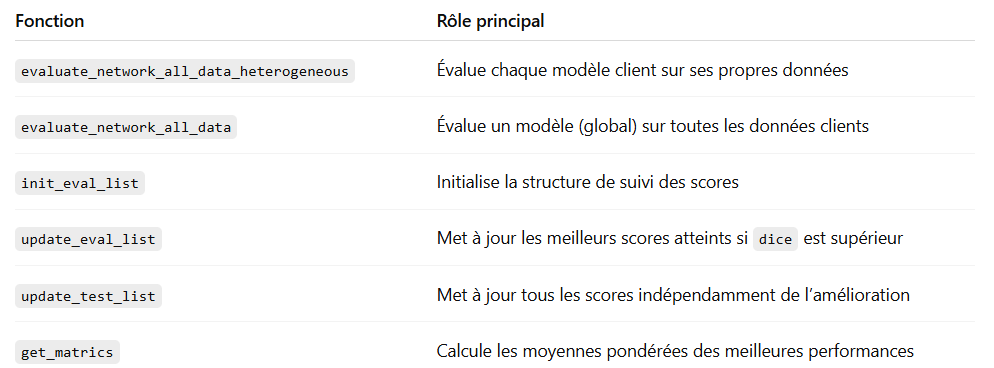


In [ ]:
import numpy as np
import torch

**Inputs :**


*   y_true : ground truth (shape : batch_size x channels x H x W)
*  y_pred : prédictions (même shape)

**But :** calculer la précision par échantillon, puis sommer.

**Output : **somme des précisions sur tous les échantillons.


In [ ]:
def precision(y_true, y_pred):
    intersection = (y_true * y_pred).sum((1,2,3))
    return ((intersection + 1e-15) / (y_pred.sum((1,2,3)) + 1e-15)).sum()

In [ ]:
def recall(y_true, y_pred):
    intersection = (y_true * y_pred).sum((1,2,3))
    return ((intersection + 1e-15) / (y_true.sum((1,2,3)) + 1e-15)).sum()

In [ ]:
def F2(y_true, y_pred, beta=2):
    p = precision(y_true,y_pred)
    r = recall(y_true, y_pred)
    return (1+beta**2.) *(p*r) / float(beta**2*p + r + 1e-15)

In [ ]:
def PPV(y_true,y_pred): #But : Positive Predictive Value (TP / (TP + FP)).
    TP = (y_true * y_pred).sum()
    FP = np.sum(y_true[y_pred>0]==0)
    return TP / float(TP+FP+1e-15)

In [ ]:
def dice_score(y_true, y_pred):  #But : Calculer la Dice coefficient.
    return ((2 * (y_true * y_pred).sum((1,2,3)) + 1e-15) / (y_true.sum((1,2,3)) + y_pred.sum((1,2,3)) + 1e-15)).sum()

In [ ]:
def iou_score(y_true, y_pred): #But : Intersection over Union (IoU).
    return (((y_true * y_pred).sum((1,2,3)) + 1e-15) / (y_true.sum((1,2,3)) + y_pred.sum((1,2,3)) -(y_true * y_pred).sum((1,2,3))+ 1e-15)).sum()

In [ ]:
def jac_score(y_true, y_pred): #Variante simplifiée de iou_score sans sommation par batch.
    intersection = (y_true * y_pred).sum()
    union = y_true.sum() + y_pred.sum() - intersection
    return (intersection + 1e-15) / (union + 1e-15)

**But :** évaluer un modèle de segmentation network sur un jeu de données (dataloader) avec plusieurs métriques (Dice, précision, rappel, IoU).

**Inputs :**

args : arguments globaux (pas utilisé dans cette fonction directement, mais inclus pour cohérence avec les autres fonctions du projet).

network : modèle PyTorch à évaluer.

dataloader : DataLoader contenant des lots (images, labels, boundary, img_name).

**Output :** un tuple de 4 valeurs moyennes : (dice, precision, recall, iou).



In [ ]:
def evaluate_network(args,network,dataloader):
    network = network.to(device) #Envoie le modèle sur GPU (.cuda()).
    network.eval() #Le passe en mode évaluation (.eval()) pour désactiver le dropout et batch norm training.

    with torch.no_grad(): #Désactive la sauvegarde du gradient de calcul => réduit l’utilisation mémoire et accélère le processus.
        prec = 0.
        rec = 0.
        dice = 0.
        iou = 0.
        length = 0
        for images, labels,boundary,img_name in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            pred = network(images) #(4,1,384,384)
            mask = pred['mask']
            mask = mask.argmax(1).unsqueeze(1)
            # mask = (torch.sigmoid(mask)>0.5).to(torch.float)
            # mask = mask.argmax(1).unsqueeze(1)
            prec += precision(labels,mask)
            rec += recall(labels, mask)
            dice += dice_score(labels, mask)
            iou += iou_score(labels, mask)
            length += len(labels)
    return dice/length,prec/length,rec/length,iou/length

**Objectif :** Évaluer plusieurs modèles locaux (clients) sur leurs données locales respectives, dans un contexte fédéré hétérogène.

**networks : **liste de modèles (len(networks) == num_clients)

**dataloaders :** liste des DataLoaders correspondants

In [ ]:
def evaluate_network_all_data_heterogeneous(args,networks,dataloaders):
    with torch.no_grad():
        prec = 0.
        rec = 0.
        dice = 0.
        iou = 0.
        length = 0
        for i in range(len(dataloaders)):
            dataloader = dataloaders[i]
            network = networks[i]
            network = network.to(args.device)
            network.eval()
            for images, labels,boundary,img_name in dataloader:
                images = images.to(args.device)
                labels = labels.to(args.device)
                pred = network(images) #(4,1,384,384)
                mask = pred['mask'] #Prédiction du modèle sur son propre jeu de données.
                mask = mask.argmax(1).unsqueeze(1)
                # mask = (torch.sigmoid(mask)>0.5).to(torch.float)
                # mask = mask.argmax(1).unsqueeze(1)
                prec += precision(labels,mask)
                rec += recall(labels, mask)
                dice += dice_score(labels, mask)
                iou += iou_score(labels, mask)
                length += len(labels)
    return dice/length,prec/length,rec/length,iou/length #Retour des moyennes pondérées globales (tous les clients confondus).

In [ ]:
def evaluate_network_all_data(args,network,dataloaders): #Évalue un seul modèle (souvent global) sur toutes les données de chaque client.
    network = network.to(args.device)
    network.eval()
    with torch.no_grad():
        prec = 0.
        rec = 0.
        dice = 0.
        iou = 0.
        length = 0
        for dataloader in dataloaders:
            for images, labels,_,_ in dataloader:
                images = images.to(args.device)
                labels = labels.to(args.device)
                pred = network(images) #(4,1,384,384) #Prédictions sur les données de chaque client.
                mask = pred['mask']

                mask = mask.argmax(1).unsqueeze(1)
                prec += precision(labels,mask)
                rec += recall(labels, mask)
                dice += dice_score(labels, mask)
                iou += iou_score(labels, mask)
                length += len(labels)
    return dice/length,prec/length,rec/length,iou/length #Retour global sur toutes les données.


In [ ]:
def init_eval_list(args): #Crée une structure de suivi pour les performances de chaque client + modèle global.
    eval_list = []
    for i in range(len(args.clients_model)+1):
        if i == len(args.clients_model): #Si dernier index, c'est le modèle global.
            eval_dict = {}
            eval_dict['client_id'] = 'global'
            eval_dict['net_name'] = args.global_name
            eval_dict['dice'] = 0.0
            eval_dict['iou'] = 0.0
            eval_dict['precision'] = 0.0
            eval_dict['recall'] = 0.0
            eval_dict['best_epoch'] = 0
            eval_list.append(eval_dict)
        else: #Sinon, c'est un client spécifique.
            eval_dict = {}
            eval_dict['client_id'] = i
            eval_dict['net_name'] = args.clients_model[i]
            eval_dict['dice'] = 0.0
            eval_dict['iou'] = 0.0
            eval_dict['precision'] = 0.0
            eval_dict['recall'] = 0.0
            eval_dict['best_epoch'] = 0
            eval_list.append(eval_dict)

    return eval_list #Retourne la liste complète.

In [ ]:
def update_eval_list(participant_index,dice,prec,rec,iou,eval_list,epoch_index): #Met à jour les scores si le nouveau Dice est meilleur que l’ancien.
    eval_dict = eval_list[participant_index]
    if dice>eval_dict['dice']:
        eval_dict['dice'] = dice.item()
        eval_dict['iou'] = iou.item()
        eval_dict['best_epoch'] = epoch_index
    # if prec>eval_dict['precision']:
        eval_dict['precision'] = prec.item()
    # if rec>eval_dict['recall']:
        eval_dict['recall'] = rec.item()
    eval_list[participant_index] = eval_dict
    return eval_list

In [ ]:
def update_test_list(participant_index,dice,prec,rec,iou,eval_list,epoch_index): #def update_test_list(participant_index,dice,prec,rec,iou,eval_list,epoch_index):
    eval_dict = eval_list[participant_index]
    eval_dict['dice'] = dice.item()
    eval_dict['iou'] = iou.item()
    eval_dict['best_epoch'] = epoch_index
    eval_dict['precision'] = prec.item()
    eval_dict['recall'] = rec.item()
    eval_list[participant_index] = eval_dict
    return eval_list

In [ ]:
def get_matrics(args,best_dice_list,dataloaders): #lcule une moyenne pondérée globale des meilleures performances.
    best_dice = 0.
    best_iou = 0.
    best_precision = 0.
    best_reacll = 0.
    length = 0.
    for participant_index in range(args.num_clients):
        best_dice+=best_dice_list[participant_index]['dice']*len(list(dataloaders[participant_index]))
        best_iou+=best_dice_list[participant_index]['iou']*len(list(dataloaders[participant_index]))
        best_precision+=best_dice_list[participant_index]['precision']*len(list(dataloaders[participant_index]))
        best_reacll+=best_dice_list[participant_index]['recall']*len(list(dataloaders[participant_index]))
        length+=len(list(dataloaders[participant_index]))
    return {"dice":best_dice/length,"iou":best_iou/length,"precision":best_precision/length,"reacll":best_reacll/length}

<font color="Green"><h3> 4: Fichier : randaugment.py</h3></font>


In [ ]:
import logging #Pour journaliser les actions/erreurs.
import random

import numpy as np
import PIL
import PIL.ImageOps
import PIL.ImageEnhance
import PIL.ImageDraw
from PIL import Image

logger = logging.getLogger(__name__)#Crée un logger pour ce module.

PARAMETER_MAX = 10 #Limite pour un paramètre (ex. : intensité de transformation).

In [ ]:
def AutoContrast(img, **kwarg): #Ajuster automatiquement le contraste d'une image pour maximiser la plage de couleurs
    return PIL.ImageOps.autocontrast(img)

In [ ]:
def Brightness(img, v, max_v, bias=0): #Modifier la luminosité de l'image en fonction d'une intensité donnée.
    v = _float_parameter(v, max_v) + bias
    return PIL.ImageEnhance.Brightness(img).enhance(v)

In [ ]:
def Color(img, v, max_v, bias=0): #Ajuster la saturation (vibrance) des couleurs de l'image.
    v = _float_parameter(v, max_v) + bias
    return PIL.ImageEnhance.Color(img).enhance(v)

In [ ]:
def Contrast(img, v, max_v, bias=0): #Modifier le contraste de l'image (différence entre clair et sombre)
    v = _float_parameter(v, max_v) + bias
    return PIL.ImageEnhance.Contrast(img).enhance(v)

In [ ]:
def Cutout(img, v, max_v, bias=0): #Masquer une zone carrée de l'image, avec une taille proportionnelle à ses dimensions.
    if v == 0:
        return img
    v = _float_parameter(v, max_v) + bias
    v = int(v * min(img.size))
    return CutoutAbs(img, v)

In [ ]:
def CutoutAbs(img, v, **kwarg): #Masquer une zone carrée de taille fixe avec une couleur grise.
    w, h = img.size
    x0 = np.random.uniform(0, w)
    y0 = np.random.uniform(0, h)
    x0 = int(max(0, x0 - v / 2.))
    y0 = int(max(0, y0 - v / 2.))
    x1 = int(min(w, x0 + v))
    y1 = int(min(h, y0 + v))
    xy = (x0, y0, x1, y1)
    # gray
    color = (127, 127, 127)
    img = img.copy()
    PIL.ImageDraw.Draw(img).rectangle(xy, color)
    return img

In [ ]:
def Equalize(img, **kwarg): #Égaliser l'histogramme pour équilibrer les intensités des pixels
    return PIL.ImageOps.equalize(img)

In [ ]:
def Identity(img, **kwarg): #Ne rien faire, retourner l'image telle quelle.
    return img

In [ ]:
def Invert(img, **kwarg): #Inverser les couleurs de l'image (effet négatif).
    return PIL.ImageOps.invert(img)

In [ ]:
def Posterize(img, v, max_v, bias=0): #Réduire le nombre de bits par canal de couleur (effet "affiche").
    v = _int_parameter(v, max_v) + bias
    return PIL.ImageOps.posterize(img, v) #Objet PIL.Image avec moins de couleurs.

In [ ]:
def Rotate(img, v, max_v, bias=0): #Faire pivoter l'image d’un angle donné (positif ou négatif).
    v = _int_parameter(v, max_v) + bias
    if random.random() < 0.5:
        v = -v
    return img.rotate(v)

In [ ]:
def Sharpness(img, v, max_v, bias=0): #Modifier la netteté de l’image (plus ou moins floue).
    v = _float_parameter(v, max_v) + bias
    return PIL.ImageEnhance.Sharpness(img).enhance(v)

In [ ]:
def ShearX(img, v, max_v, bias=0): #Appliquer un cisaillement horizontal à l'image (déformation en biais sur l'axe X).
    v = _float_parameter(v, max_v) + bias
    if random.random() < 0.5:
        v = -v
    return img.transform(img.size, PIL.Image.AFFINE, (1, v, 0, 0, 1, 0))

In [ ]:
def ShearY(img, v, max_v, bias=0): #Appliquer un cisaillement vertical à l'image (déformation en biais sur l'axe Y).
    v = _float_parameter(v, max_v) + bias
    if random.random() < 0.5:
        v = -v
    return img.transform(img.size, PIL.Image.AFFINE, (1, 0, 0, v, 1, 0))

In [ ]:
def Solarize(img, v, max_v, bias=0): #Appliquer un effet de solarisation (inverser les pixels au-dessus d’un seuil).
    v = _int_parameter(v, max_v) + bias
    return PIL.ImageOps.solarize(img, 256 - v)

In [ ]:
def SolarizeAdd(img, v, max_v, bias=0, threshold=128): #Ajouter une valeur aux pixels, puis appliquer une solarisation.
    v = _int_parameter(v, max_v) + bias
    if random.random() < 0.5:
        v = -v
    img_np = np.array(img).astype(np.int)
    img_np = img_np + v
    img_np = np.clip(img_np, 0, 255)
    img_np = img_np.astype(np.uint8)
    img = Image.fromarray(img_np)
    return PIL.ImageOps.solarize(img, threshold)

In [ ]:
def TranslateX(img, v, max_v, bias=0): #Déplacer l’image horizontalement (gauche ou droite).
    v = _float_parameter(v, max_v) + bias
    if random.random() < 0.5:
        v = -v
    v = int(v * img.size[0])
    return img.transform(img.size, PIL.Image.AFFINE, (1, 0, v, 0, 1, 0))

In [ ]:
def TranslateY(img, v, max_v, bias=0): #Déplacer l’image verticalement (haut ou bas)
    v = _float_parameter(v, max_v) + bias
    if random.random() < 0.5:
        v = -v
    v = int(v * img.size[1])
    return img.transform(img.size, PIL.Image.AFFINE, (1, 0, 0, 0, 1, v))

In [ ]:
def _float_parameter(v, max_v): #Normaliser une valeur en flottant proportionnellement à PARAMETER_MAX.
    return float(v) * max_v / PARAMETER_MAX

In [ ]:
def _int_parameter(v, max_v): #Normaliser une valeur en entier proportionnellement à PARAMETER_MAX.
    return int(v * max_v / PARAMETER_MAX)

In [ ]:
def fixmatch_augment_pool(): #Créer une liste de transformations inspirée du papier FixMatch pour l’augmentation de données.
    # FixMatch paper
    augs = [(AutoContrast, None, None),
            (Brightness, 0.9, 0.05),
            (Color, 0.9, 0.05),
            (Contrast, 0.9, 0.05),
            (Equalize, None, None),
            (Identity, None, None),
            (Posterize, 4, 4),
            # (Rotate, 30, 0),
            (Sharpness, 0.9, 0.05),
            # (ShearX, 0.3, 0),
            # (ShearY, 0.3, 0),
            (Solarize, 256, 0),
            # (TranslateX, 0.3, 0),
            # (TranslateY, 0.3, 0)]
    ]
    return augs

In [ ]:
def my_augment_pool(): #Créer une liste personnalisée de transformations pour l’augmentation de données.
    # Test
    augs = [(AutoContrast, None, None),
            (Brightness, 1.8, 0.1),
            (Color, 1.8, 0.1),
            (Contrast, 1.8, 0.1),
            (Cutout, 0.2, 0),
            (Equalize, None, None),
            (Invert, None, None),
            (Posterize, 4, 4),
            # (Rotate, 30, 0),
            (Sharpness, 1.8, 0.1),
            # (ShearX, 0.3, 0),
            # (ShearY, 0.3, 0),
            (Solarize, 256, 0),
            (SolarizeAdd, 110, 0),
            # (TranslateX, 0.45, 0),
            # (TranslateY, 0.45, 0)]
    ]
    return augs

In [ ]:
class RandAugmentPC(object): #Initialiser un objet RandAugmentPC pour appliquer des augmentations aléatoires personnalisées.
    def __init__(self, n, m):
        assert n >= 1
        assert 1 <= m <= 10
        self.n = n
        self.m = m
        self.augment_pool = my_augment_pool()

    def __call__(self, img):
        ops = random.choices(self.augment_pool, k=self.n)
        for op, max_v, bias in ops:
            prob = np.random.uniform(0.2, 0.8)
            if random.random() + prob >= 1:
                img = op(img, v=self.m, max_v=max_v, bias=bias)
        img = CutoutAbs(img, int(32*0.5))
        return img

In [ ]:
class RandAugmentMC(object): #Appliquer n transformations aléatoires à une image avec probabilité ajustée.
    def __init__(self, n, m):
        assert n >= 1
        assert 1 <= m <= 10
        self.n = n
        self.m = m
        self.augment_pool = fixmatch_augment_pool()

    def __call__(self, img):
        ops = random.choices(self.augment_pool, k=self.n)
        for op, max_v, bias in ops:
            v = np.random.randint(1, self.m)
            if random.random() < 0.5:
                img = op(img, v=v, max_v=max_v, bias=bias)
        img = CutoutAbs(img, int(32*0.5))
        return img

<font color="Green"><h3> 4: Fichier : utils.py</h3></font>
**Partie Création des Modéles **

In [ ]:
import os
import torch
from networks.SegmentationModel import SegmentationModel,DeepLabHeadV3Plus #
from utils.datasets import get_datasplit,FEDDataset
from torch.utils.data import DataLoader
import numpy as np
import torch.optim.lr_scheduler as lr_scheduler
import math
import cv2
from copy import deepcopy

In [ ]:
def normal_loss(loss): #Normaliser une perte en appliquant une fonction sigmoïde et en la remettant à l'échelle entre -1 et 1.
    loss = torch.sigmoid(loss)
    loss = (loss-0.5)*2
    return loss #Tenseur PyTorch avec la perte normalisée.

In [ ]:
#Calculer des poids pour l’agrégation des contributions de données étiquetées et non étiquetées, en tenant compte des pertes et du paramètre theta.

def update_weight(num_labeled,num_unlabeled,loss_labeled,loss_unlabeled,pre_labeled_mean_loss_list,pre_unlabeled_mean_loss_list,theta = 1):
    num_labeled = torch.tensor(num_labeled)
    num_unlabeled = torch.tensor(num_unlabeled)
    weight = num_labeled*loss_labeled+theta*num_unlabeled*loss_unlabeled
    weight = weight/(num_labeled+num_unlabeled)
    weight = weight.sum()/weight
    weight = torch.softmax(weight,-1)
    if torch.isnan(weight).any():
        print(weight)

    return weight #Tenseur PyTorch contenant les poids normalisés.

In [ ]:
#Mettre à jour les paramètres d’un modèle à moyenne exponentielle mobile (EMA) en combinant les paramètres du modèle principal avec un facteur alpha.
def update_ema_variables(model, ema_model, alpha, global_step):
    # Use the true average until the exponential average is more correct
    alpha = min(1 - 1 / (global_step + 1), alpha)
    for ema_param, param in zip(ema_model.parameters(), model.parameters()):
        ema_param.data.mul_(alpha).add_(1 - alpha, param.data)
        # ema_param.data.mul_(alpha).add_(param.data, 1 - alpha)

In [ ]:
#Créer un modèle de segmentation basé sur différents backbones (ResNet, Xception, etc.) avec une tête DeepLabV3+.
def get_net(net_name,num_classes,ema=False):
    from networks.backbone.deeplab import Decoder
    if net_name=='resnet34':
        from networks.backbone.resnet import resnet34
        bkbone = resnet34()
        head = DeepLabHeadV3Plus(in_channels=512,low_level_channels=64,num_classes=num_classes)
        net =  SegmentationModel(bkbone,head)
    elif net_name=='resnet50':
        from networks.backbone.resnet import resnet50 #
        bkbone = resnet50()
        head = DeepLabHeadV3Plus(in_channels=2048,low_level_channels=256,num_classes=num_classes)
        net =  SegmentationModel(bkbone,head)
    elif net_name=='resnet18':
        from networks.backbone.resnet import resnet18 #
        bkbone = resnet18()
        head = DeepLabHeadV3Plus(in_channels=512,low_level_channels=64,num_classes=num_classes)
        net =  SegmentationModel(bkbone,head)
    elif net_name=='resnet101':
        from networks.backbone.resnet import resnet101 #
        bkbone = resnet101()
        head = DeepLabHeadV3Plus(in_channels=2048,low_level_channels=256,num_classes=num_classes)
        net =  SegmentationModel(bkbone,head)
    elif net_name=='resnet152':
        from networks.backbone.resnet import resnet152 #
        bkbone = resnet152()
        head = DeepLabHeadV3Plus(in_channels=2048,low_level_channels=256,num_classes=num_classes)
        net =  SegmentationModel(bkbone,head)
    elif net_name =='xception':
        from networks.backbone.xception import xception
        bkbone = xception(pretrained=False)
        head = DeepLabHeadV3Plus(in_channels=2048,low_level_channels=64,num_classes=num_classes)
        net =  SegmentationModel(bkbone,head)
    elif net_name =='mobilenetv2':
        from networks.backbone.mobilenetv2 import mobilenet_v2 #networks.
        bkbone = mobilenet_v2(pretrained=False)
        head = DeepLabHeadV3Plus(in_channels=1280,low_level_channels=24,num_classes=num_classes)
        net =  SegmentationModel(bkbone,head)
    elif net_name =='vgg':
        from networks.backbone.vgg import VGG16 #networks.
        bkbone = VGG16(pretrained=False)
        head = DeepLabHeadV3Plus(in_channels=512,low_level_channels=64,num_classes=num_classes)
        net =  SegmentationModel(bkbone,head)
    elif net_name =='pvt':
        from networks.backbone.pvt import pvt_v2_b2 #networks.
        bkbone = pvt_v2_b2()
        head = DeepLabHeadV3Plus(in_channels=512,low_level_channels=64,num_classes=num_classes)
        net =  SegmentationModel(bkbone,head)
    print("build net with encoder {}.".format(net_name))
    if ema:
            for param in net.parameters():
                param.detach_()
    return net #Objet SegmentationModel (modèle PyTorch).

In [ ]:
#args : Objet contenant global_name (nom du backbone) et num_classes
def build_global_model(args): #Construire un modèle global de segmentation à partir des arguments.
    net_name = args.global_name
    num_classes = args.num_classes
    net = get_net(net_name,num_classes)
    return net #Objet SegmentationModel (modèle PyTorch global).

In [ ]:
def init_client_nets(args): #nitialiser les modèles de segmentation pour chaque client et leurs versions EMA
    nets_list = {net_i: None for net_i in range(args.num_clients)}
    ema_nets_list = {net_i: None for net_i in range(args.num_clients)}
    for net_i in range(args.num_clients):
        net_name = args.clients_model[net_i]
        net = get_net(net_name,args.num_classes)

        ema_net = ModelEMA(net, args.ema_decay)
        nets_list[net_i] = net
        ema_nets_list[net_i] = ema_net
    return nets_list,ema_nets_list #Dictionnaire de modèles clients , Dictionnaire de modèles EMA clients.

In [ ]:
def get_optimizer(optim_name,model,base_lr): #Créer un optimiseur (Adam, SGD, ou AdamW) pour un modèle donné.
    if optim_name == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=base_lr,
                                        betas=(0.9, 0.999), weight_decay=5e-4)
    elif optim_name == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=base_lr, momentum=0.9,
                                    weight_decay=5e-4)
    elif optim_name == 'adamw':
        optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=0.02)

    return optimizer

In [ ]:
def initial_trainer(args): #nitialiser tous les composants nécessaires pour l’entraînement fédéré (modèles, optimiseurs, schedulers, datasets, dataloaders).
    #定义模型 #Définir le model
    global_net = build_global_model(args=args)
    net_list,ema_net_list = init_client_nets(args)
    # Scheduler https://arxiv.org/pdf/1812.01187.pdf
    global_lf = lambda x: ((1 + math.cos(x * math.pi / (args.CommunicationEpoch*args.condensationEpoch))) / 2) * (1 - args.lrf) + args.lrf  # cosine
    client_lf = lambda x: ((1 + math.cos(x * math.pi / (args.CommunicationEpoch*args.condensationEpoch))) / 2) * (1 - args.lrf) + args.lrf  # cosine


    #定义优化器 définir l'optimiseur
    global_optimizer = get_optimizer(optim_name = args.global_optim,model = global_net,base_lr=args.base_lr)
    global_scheduler = lr_scheduler.LambdaLR(global_optimizer, lr_lambda=global_lf)
    print('global_optimizer',global_optimizer )
    # logging.info('global_optimizer',global_optimizer )
    optimizer_clients = []
    scheduler_clients = []
    for ind in range(len(net_list)):
        optimizer = get_optimizer(optim_name = args.client_optim,model = net_list[ind],base_lr=args.base_lr)
        scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda=client_lf)
        optimizer_clients.append(optimizer)
        scheduler_clients.append(scheduler)

    #定义全局dataset和dataloader # ['labeled_train', 'unlabeled_train', 'val_list', 'test_list']
    global_train_dataset = FEDDataset(args=args, dataset=args.datasets[0], transform = True, split ='labeled_train', noise = args.noise)
    global_train_dataloader = DataLoader(global_train_dataset,batch_size=args.batch_size,pin_memory=True,num_workers=args.num_workers,drop_last=True,shuffle=False)


    #定义局部dataset和 dataloader
    labeled_train_client_dataloaders = []
    unlabeled_train_client_dataloaders = []
    val_client_dataloaders = []
    test_client_dataloaders = []
    labeled_train_client_datasets = []
    unlabeled_train_client_datasets = []
    val_client_datasets = []
    test_client_datasets = []
    dataset_labeled_nums = []
    dataset_unlabeled_nums = []
    for ind in range(1,len(args.datasets)):
        client_dataset = FEDDataset(args=args, dataset=args.datasets[ind], transform = True, split ='labeled_train', noise = args.noise)
        if len(client_dataset)<=1:
            labeled_train_client_dataloaders.append(None)
            labeled_train_client_datasets.append(None)
            # dataset_labeled_nums.append(0)
            dataset_labeled_nums.append(len(global_train_dataset))
        else:
            client_dataloader = DataLoader(client_dataset,batch_size=args.batch_size,pin_memory=True,num_workers=args.num_workers,drop_last=True)
            labeled_train_client_dataloaders.append(client_dataloader)
            labeled_train_client_datasets.append(client_dataset)
            # dataset_labeled_nums.append(len(client_dataset))
            dataset_labeled_nums.append(len(client_dataset)+len(global_train_dataset))
        client_dataset = FEDDataset(args=args, dataset=args.datasets[ind], transform = True, split ='unlabeled_train', noise = args.noise)
        if len(client_dataset)<=1:
            unlabeled_train_client_dataloaders.append(None)
            unlabeled_train_client_datasets.append(None)
            dataset_unlabeled_nums.append(0)
        else:
            client_dataloader = DataLoader(client_dataset,batch_size=args.batch_size,pin_memory=True,num_workers=args.num_workers,drop_last=True)
            unlabeled_train_client_dataloaders.append(client_dataloader)
            unlabeled_train_client_datasets.append(client_dataset)
            dataset_unlabeled_nums.append(len(client_dataset))
            # dataset_length += len(client_dataset)

        client_dataset = FEDDataset(args=args, dataset=args.datasets[ind], transform = False, split ='val_list', noise = False)
        client_dataloader = DataLoader(client_dataset,batch_size=args.batch_size,pin_memory=True,num_workers=args.num_workers,drop_last=True)
        val_client_dataloaders.append(client_dataloader)
        val_client_datasets.append(client_dataset)
        client_dataset = FEDDataset(args=args, dataset=args.datasets[ind], transform = False, split ='test_list', noise = False)
        client_dataloader = DataLoader(client_dataset,batch_size=args.batch_size,pin_memory=True,num_workers=args.num_workers,drop_last=True)
        test_client_dataloaders.append(client_dataloader)
        test_client_datasets.append(client_dataset)

    return global_net,net_list,ema_net_list,global_optimizer,optimizer_clients, \
                global_train_dataloader,labeled_train_client_dataloaders, \
                               unlabeled_train_client_dataloaders,val_client_dataloaders, \
                                   test_client_dataloaders,dataset_labeled_nums,dataset_unlabeled_nums, \
                                       global_scheduler,scheduler_clients
                                       #Tuple contenant le modèle global, les modèles clients, les optimiseurs, les schedulers, les dataloaders, et les tailles des datasets.

In [ ]:
def exp_normalize(args,last_mean_loss_list,current_mean_loss_list,epoch_index): #Normaliser les poids des clients en fonction de l’amélioration des pertes entre deux époques
    #EXP标准化处理 Traitement de normalisation EXP
    quality_list = []
    amount_with_quality = [1 / (args.num_clients - 1) for i in range(args.num_clients)]
    amount_with_quality_exp = []
    weight_with_quality = []
    if args.Client_Confidence_Reweight:
        beta = 0.5
    else:
        beta = 0
    if epoch_index > 0 :
        for participant_index in range(args.num_clients):
            delta_loss = last_mean_loss_list[participant_index] - current_mean_loss_list[participant_index]
            quality_list.append(delta_loss / current_mean_loss_list[participant_index])
        quality_sum = sum(quality_list)
        for participant_index in range(args.num_clients):
            amount_with_quality[participant_index] += beta * quality_list[participant_index] / quality_sum
            amount_with_quality_exp.append(np.exp(amount_with_quality[participant_index]))
        amount_with_quality_sum = sum(amount_with_quality_exp)
        for participant_index in range(args.num_clients):
            weight_with_quality.append(amount_with_quality_exp[participant_index] / amount_with_quality_sum)
    else:
        weight_with_quality = [1 / (args.num_clients - 1) for i in range(args.num_clients)]
    weight_with_quality = torch.tensor(weight_with_quality)
    return weight_with_quality


In [ ]:
#Visualiser et sauvegarder des images avec leurs étiquettes, frontières, masques prédits, et versions EMA pour différents scénarios.

def visual_img(images,labels,boundary,ema_images,participant_index,mask,pre_boundary,ema_mask,ema_pre_boundary,flag ='local',save_dir = './plot'):
    os.makedirs(os.path.join(save_dir,flag),exist_ok=True)
    if flag == 'local':
        pred_image = deepcopy(images.detach())
        # pre_ema_image = deepcopy(ema_images.detach())
        # 原始图片及边界 Image et bordure originales
        images[0,0][labels.argmax(1)[0]==1] = 1
        images[0,1][boundary.argmax(1)[0]==1] = 1
        cv2.imwrite(os.path.join(save_dir,flag,'loc_data_client_{}_image.jpg'.format(participant_index)),((images[0]+1)/2*255).permute(1,2,0)[:,:,[2,1,0]].cpu().numpy())
        # # ema输入图片及边界 Images et limites de prédiction de l'EMA
        # ema_images[0,0][labels.argmax(1)[0]==1] = 1
        # ema_images[0,1][boundary.argmax(1)[0]==1] = 1
        # cv2.imwrite(os.path.join(save_dir,flag,'loc_data_client_{}_ema_image.jpg'.format(participant_index)),((ema_images[0]+1)/2*255).permute(1,2,0)[:,:,[2,1,0]].cpu().numpy())
        # 预测图片及边界 Prédire les images et les limites
        pred_image[0,0][mask.argmax(1)[0]==1] = 1
        pred_image[0,1][pre_boundary.argmax(1)[0]==1] = 1
        cv2.imwrite(os.path.join(save_dir,flag,'predict_data_client_{}_image.jpg'.format(participant_index)),((pred_image[0]+1)/2*255).permute(1,2,0)[:,:,[2,1,0]].cpu().numpy())
        # # ema预测图片及边界 Prédire les images et les limites
        # pre_ema_image[0,0][ema_mask.argmax(1)[0]==1] = 1
        # pre_ema_image[0,1][ema_pre_boundary.argmax(1)[0]==1] = 1
        # cv2.imwrite(os.path.join(save_dir,flag,'predict_data_client_{}_ema_image.jpg'.format(participant_index)),((pre_ema_image[0]+1)/2*255).permute(1,2,0)[:,:,[2,1,0]].cpu().numpy())
    if flag == 'unlabel_local':
        pred_image = deepcopy(images.detach())
        pre_ema_image = deepcopy(ema_images.detach())
        # 预测图片及边界
        pred_image[0,0][mask[0]==1] = 1
        pred_image[0,1][pre_boundary[0]==1] = 1
        cv2.imwrite(os.path.join(save_dir,flag,'predict_data_client_{}_image.jpg'.format(participant_index)),((pred_image[0]+1)/2*255).permute(1,2,0)[:,:,[2,1,0]].cpu().numpy())
        # ema预测图片及边界
        pre_ema_image[0,0][ema_mask.argmax(1)[0]==1] = 1
        pre_ema_image[0,1][ema_pre_boundary.argmax(1)[0]==1] = 1
        cv2.imwrite(os.path.join(save_dir,flag,'predict_data_client_{}_ema_image.jpg'.format(participant_index)),((pre_ema_image[0]+1)/2*255).permute(1,2,0)[:,:,[2,1,0]].cpu().numpy())
    if flag == 'server_local':
        pred_image = deepcopy(images.detach())
        # 原始图片及边界
        images[0,0][labels.argmax(1)[0]==1] = 1
        images[0,1][boundary.argmax(1)[0]==1] = 1
        cv2.imwrite(os.path.join(save_dir,flag,'loc_data_client_{}_image.jpg'.format(participant_index)),((images[0]+1)/2*255).permute(1,2,0)[:,:,[2,1,0]].cpu().numpy())
        # 预测图片及边界
        pred_image[0,0][mask.argmax(1)[0]==1] = 1
        pred_image[0,1][pre_boundary.argmax(1)[0]==1] = 1
        cv2.imwrite(os.path.join(save_dir,flag,'predict_data_client_{}_image.jpg'.format(participant_index)),((pred_image[0]+1)/2*255).permute(1,2,0)[:,:,[2,1,0]].cpu().numpy())
    if flag == 'kllocal':
        pred_image = deepcopy(images.detach())
        ema_images = deepcopy(images.detach())
        # 原始图片及边界
        images[0,0][labels.argmax(1)[0]==1] = 1
        images[0,1][boundary.argmax(1)[0]==1] = 1
        cv2.imwrite(os.path.join(save_dir,flag,'loc_data_client_{}_image.jpg'.format(participant_index)),((images[0]+1)/2*255).permute(1,2,0)[:,:,[2,1,0]].cpu().numpy())
        # server预测图片及边界
        ema_images[0,0][ema_mask.argmax(1)[0]==1] = 1
        ema_images[0,1][ema_pre_boundary.argmax(1)[0]==1] = 1
        cv2.imwrite(os.path.join(save_dir,flag,'predict_server_image.jpg'),((ema_images[0]+1)/2*255).permute(1,2,0)[:,:,[2,1,0]].cpu().numpy())
        # 预测图片及边界
        pred_image[0,0][mask.argmax(1)[0]==1] = 1
        pred_image[0,1][pre_boundary.argmax(1)[0]==1] = 1
        cv2.imwrite(os.path.join(save_dir,flag,'predict_data_client_{}_image.jpg'.format(participant_index)),((pred_image[0]+1)/2*255).permute(1,2,0)[:,:,[2,1,0]].cpu().numpy())

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class ModelEMA(object): #Gérer un modèle EMA en mettant à jour ses paramètres à partir d’un modèle principal.
    '''
    from https://github.com/kekmodel/FixMatch-pytorch/blob/master/models/ema.py
    '''

    def __init__(self,  model, decay):
        self.device = device if device is not None else torch.device("cpu")
        self.ema = deepcopy(model).to(self.device)
        self.ema.eval()
        self.decay = decay
        self.ema_has_module = hasattr(self.ema, 'module')
        # Fix EMA. https://github.com/valencebond/FixMatch_pytorch thank you!
        self.param_keys = [k for k, _ in self.ema.named_parameters()]
        self.buffer_keys = [k for k, _ in self.ema.named_buffers()]
        for p in self.ema.parameters():
            p.requires_grad_(False)

    def update(self, model ,global_step):
        needs_module = hasattr(model, 'module') and not self.ema_has_module
        self.decay = min(1 - 1 / (global_step + 1), self.decay)
        with torch.no_grad():
            msd = model.state_dict()
            esd = self.ema.state_dict()
            for k in self.param_keys:
                if needs_module:
                    j = 'module.' + k
                else:
                    j = k
                model_v = msd[j].detach()
                ema_v = esd[k]
                esd[k].copy_(ema_v * self.decay + (1. - self.decay) * model_v)

            for k in self.buffer_keys:
                if needs_module:
                    j = 'module.' + k
                else:
                    j = k
                esd[k].copy_(msd[j])

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if __name__ == '__main__':
    import os
    # os.environ['CUDA_VISIBLE_DEVICES'] = '3'

    model = get_net('resnet50', 2).to(device)

    ema_model = ModelEMA(model, 0.999)  # pas besoin de device ici

    input = torch.randn((2, 3, 384, 384)).to(device)  # Tensor sur le bon device

    out = model(input)

build net with encoder resnet50.


<font color="#B22222"><h2>Dossier : /networks</h2></font>

<font color="Purple"><h2>Dossier : bakbone </h2></font>

<font color="Green"><h4> 1: fichier : resnet.py</h4></font>
 Définit la structure de ResNet (backbone).



In [ ]:
import os
# os.environ['CUDA_VISIBLE_DEVICES'] = '5'

import torch
import torch.nn as nn
try: # for torchvision<0.4
    from torchvision.models.utils import load_state_dict_from_url #ert à télécharger et charger les poids pré-entraînés d’un modèle depuis une URL.
except: # for torchvision>=0.4
    from torch.hub import load_state_dict_from_url


In [ ]:
# Liste des modèles accessibles depuis l’extérieur

_all__ = ['ResNet', 'resnet18', 'resnet34', 'resnet50', 'resnet101',
           'resnet152', 'resnext50_32x4d', 'resnext101_32x8d',
           'wide_resnet50_2', 'wide_resnet101_2']
#Associe chaque nom de modèle à son URL de poids pré-entraînés sur les serveurs PyTorch.

model_urls = {
    'resnet18': 'https://download.pytorch.org/models/resnet18-5c106cde.pth',
    'resnet34': 'https://download.pytorch.org/models/resnet34-333f7ec4.pth',
    'resnet50': 'https://download.pytorch.org/models/resnet50-19c8e357.pth',
    'resnet101': 'https://download.pytorch.org/models/resnet101-5d3b4d8f.pth',
    'resnet152': 'https://download.pytorch.org/models/resnet152-b121ed2d.pth',
    'resnext50_32x4d': 'https://download.pytorch.org/models/resnext50_32x4d-7cdf4587.pth',
    'resnext101_32x8d': 'https://download.pytorch.org/models/resnext101_32x8d-8ba56ff5.pth',
    'wide_resnet50_2': 'https://download.pytorch.org/models/wide_resnet50_2-95faca4d.pth',
    'wide_resnet101_2': 'https://download.pytorch.org/models/wide_resnet101_2-32ee1156.pth',
}

In [ ]:
def conv3x3(in_planes, out_planes, stride=1, groups=1, dilation=1):
    """3x3 convolution with padding"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=dilation, groups=groups, bias=False, dilation=dilation)

In [ ]:
def conv1x1(in_planes, out_planes, stride=1):
    """1x1 convolution"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)

Structure générale du bloc BasicBlock :


*   Deux convolutions 3×3, chacune suivie de BatchNorm et ReLU.

*   Un raccourci (identity) ajouté à la sortie.
*  Optionnellement : une projection (downsample) si la taille change.










In [ ]:
class BasicBlock(nn.Module): # implémente un bloc de base (résiduel) de ResNet
    expansion = 1 # signifie que la sortie garde la même taille de canaux que planes

    def __init__(self, inplanes, planes, stride=1, downsample=None, groups=1,
                 base_width=64, dilation=1, norm_layer=None):
        super(BasicBlock, self).__init__()
        if norm_layer is None: #Si aucune couche de normalisation n'est spécifiée, on utilise la batch normalization standard.
            norm_layer = nn.BatchNorm2d
        if groups != 1 or base_width != 64: #ne prend pas en charge les convolutions groupées ni la largeur personnalisée.
            raise ValueError('BasicBlock only supports groups=1 and base_width=64')
        if dilation > 1:
            raise NotImplementedError("Dilation > 1 not supported in BasicBlock")
        # Both self.conv1 and self.downsample layers downsample the input when stride != 1
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = norm_layer(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = norm_layer(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x): #On conserve l’entrée originale dans identity pour l’ajouter à la fin
        identity = x #tenseur de forme [B, inplanes, H, W]

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out #Tenseur de forme [B, planes, H_out, W_out] (identique à x si pas de stride ou downsample)

Le bloc Bottleneck est une version optimisée et plus profonde d’un bloc résiduel classique (BasicBlock).
Il suit une structure 1x1 → 3x3 → 1x1, avec une expansion des canaux (souvent ×4).

Cela permet :


*   une réduction de complexité (en apprenant dans un espace plus petit),


*   une profondeur plus grande sans explosion des paramètres,
*  un apprentissage plus efficace avec les connexions résiduelles
    
    

| **Aspect**                 | **BasicBlock**                         | **Bottleneck**                                                             |
| -------------------------- | -------------------------------------- | -------------------------------------------------------------------------- |
| **Utilisé dans**           | ResNet-18, ResNet-34                   | ResNet-50, ResNet-101, ResNet-152                                          |
| **Structure des couches**  | Conv(3x3) → BN → ReLU → Conv(3x3) → BN | Conv(1x1) → BN → ReLU → Conv(3x3) → BN → ReLU → Conv(1x1) → BN             |
| **Nombre de convolutions** | 2                                      | 3                                                                          |
| **Expansion des canaux**   | Pas d'expansion (expansion = 1)        | Expansion = 4 (output has 4× more channels)                                |
| **Connexion résiduelle**   | Ajoute `x` directement                 | Peut nécessiter une projection (via `downsample`)                          |
| **Coût en calcul**         | Plus léger                             | Plus optimisé pour les réseaux profonds (moins de FLOPs malgré profondeur) |
| **Recommandé pour**        | Petits modèles ou peu de couches       | Modèles profonds, plus performants                                         |


In [ ]:
# une composante clé des réseaux ResNet profonds (ResNet-50, 101, 152).

class Bottleneck(nn.Module):
    expansion = 4 #la sortie aura 4 fois plus de canaux que planes.

    def __init__(self, inplanes, planes, stride=1, downsample=None, groups=1,
                 base_width=64, dilation=1, norm_layer=None):
        super(Bottleneck, self).__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        width = int(planes * (base_width / 64.)) * groups
        # Both self.conv2 and self.downsample layers downsample the input when stride != 1
        self.conv1 = conv1x1(inplanes, width)
        self.bn1 = norm_layer(width)
        self.conv2 = conv3x3(width, width, stride, groups, dilation)
        self.bn2 = norm_layer(width)
        self.conv3 = conv1x1(width, planes * self.expansion)
        self.bn3 = norm_layer(planes * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out

Cette classe ResNet définit une architecture de réseau neuronal résiduel pour la classification d'images, inspirée des architectures ResNet utilisées dans des tâches de vision par ordinateur. Elle utilise des blocs résiduels comme BasicBlock et Bottleneck pour l'entraînement de réseaux de profondeur élevée sans souffrir de problèmes de gradient qui s'éteint (vanishing gradients).

In [ ]:
class ResNet(nn.Module):

    def __init__(self, block, layers, num_classes=1000, zero_init_residual=False,
                 groups=1, width_per_group=64, replace_stride_with_dilation=None,
                 norm_layer=None):
        super(ResNet, self).__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        self._norm_layer = norm_layer

        self.inplanes = 64 #Le nombre de canaux d'entrée pour la première couche
        self.dilation = 1 #Facteur de dilatation, utilisé dans les convolutions dilatées
        if replace_stride_with_dilation is None:
            # each element in the tuple indicates if we should replace
            # the 2x2 stride with a dilated convolution instead
            replace_stride_with_dilation = [False, False, False]
        if len(replace_stride_with_dilation) != 3:
            raise ValueError("replace_stride_with_dilation should be None "
                             "or a 3-element tuple, got {}".format(replace_stride_with_dilation))
        self.groups = groups
        self.base_width = width_per_group
        self.conv1 = nn.Conv2d(3, self.inplanes, kernel_size=7, stride=2, padding=3,
                               bias=False)
        self.bn1 = norm_layer(self.inplanes)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2,
                                       dilate=replace_stride_with_dilation[0])
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2,
                                       dilate=replace_stride_with_dilation[1])
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2,
                                       dilate=replace_stride_with_dilation[2])
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

#Cette boucle initialise les poids des couches convolutives avec l'initialisation de He (kaiming_normal_)
#et les poids des couches de normalisation de lot avec 1 et les biais avec 0.
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

        # Zero-initialize the last BN in each residual branch,
        # so that the residual branch starts with zeros, and each residual block behaves like an identity.
        # This improves the model by 0.2~0.3% according to https://arxiv.org/abs/1706.02677
        if zero_init_residual:
            for m in self.modules():
                if isinstance(m, Bottleneck):
                    nn.init.constant_(m.bn3.weight, 0)
                elif isinstance(m, BasicBlock):
                    nn.init.constant_(m.bn2.weight, 0)

    def _make_layer(self, block, planes, blocks, stride=1, dilate=False): #Crée une séquence de blocs résiduels pour une couche donnée
        norm_layer = self._norm_layer
        downsample = None
        previous_dilation = self.dilation
        if dilate:
            self.dilation *= stride
            stride = 1
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                conv1x1(self.inplanes, planes * block.expansion, stride),
                norm_layer(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample, self.groups,
                            self.base_width, previous_dilation, norm_layer))
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes, groups=self.groups,
                                base_width=self.base_width, dilation=self.dilation,
                                norm_layer=norm_layer))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x1 = self.layer1(x)
        x = self.layer2(x1)
        x = self.layer3(x)
        x = self.layer4(x)

        # x = self.avgpool(x)
        # x = torch.flatten(x, 1)
        # x = self.fc(x)

        return {'low_level':x1,'out':x}


        #Cette classe ResNet définit un modèle de réseau neuronal convolutif résiduel permettant d'apprendre des représentations visuelles profondes tout en maintenant une bonne performance grâce aux blocs résiduels

In [ ]:
def _resnet(arch, block, layers, pretrained, progress, **kwargs):
    model = ResNet(block, layers, **kwargs)
    if pretrained:
        state_dict = load_state_dict_from_url(model_urls[arch],
                                              progress=progress)
        model.load_state_dict(state_dict)
    return model

In [ ]:
def resnet18(pretrained=False, progress=True, **kwargs):
    r"""ResNet-18 model from
    `"Deep Residual Learning for Image Recognition" <https://arxiv.org/pdf/1512.03385.pdf>`_
    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
        progress (bool): If True, displays a progress bar of the download to stderr
    """
    return _resnet('resnet18', BasicBlock, [2, 2, 2, 2], pretrained, progress,
                   **kwargs)

In [ ]:
def resnet34(pretrained=False, progress=True, **kwargs):
    r"""ResNet-34 model from
    `"Deep Residual Learning for Image Recognition" <https://arxiv.org/pdf/1512.03385.pdf>`_
    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
        progress (bool): If True, displays a progress bar of the download to stderr
    """
    return _resnet('resnet34', BasicBlock, [3, 4, 6, 3], pretrained, progress,
                   **kwargs)

In [ ]:
def resnet50(pretrained=False, progress=True, **kwargs):
    r"""ResNet-50 model from
    `"Deep Residual Learning for Image Recognition" <https://arxiv.org/pdf/1512.03385.pdf>`_
    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
        progress (bool): If True, displays a progress bar of the download to stderr
    """
    return _resnet('resnet50', Bottleneck, [3, 4, 6, 3], pretrained, progress,
                   **kwargs)

In [ ]:
def resnet101(pretrained=False, progress=True, **kwargs):
    r"""ResNet-101 model from
    `"Deep Residual Learning for Image Recognition" <https://arxiv.org/pdf/1512.03385.pdf>`_
    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
        progress (bool): If True, displays a progress bar of the download to stderr
    """
    return _resnet('resnet101', Bottleneck, [3, 4, 23, 3], pretrained, progress,
                   **kwargs)


In [ ]:
def resnet152(pretrained=False, progress=True, **kwargs):
    r"""ResNet-152 model from
    `"Deep Residual Learning for Image Recognition" <https://arxiv.org/pdf/1512.03385.pdf>`_
    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
        progress (bool): If True, displays a progress bar of the download to stderr
    """
    return _resnet('resnet152', Bottleneck, [3, 8, 36, 3], pretrained, progress,
                   **kwargs)

In [ ]:
def resnext50_32x4d(pretrained=False, progress=True, **kwargs):
    r"""ResNeXt-50 32x4d model from
    `"Aggregated Residual Transformation for Deep Neural Networks" <https://arxiv.org/pdf/1611.05431.pdf>`_
    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
        progress (bool): If True, displays a progress bar of the download to stderr
    """
    kwargs['groups'] = 32
    kwargs['width_per_group'] = 4
    return _resnet('resnext50_32x4d', Bottleneck, [3, 4, 6, 3],
                   pretrained, progress, **kwargs)

In [ ]:
def resnext101_32x8d(pretrained=False, progress=True, **kwargs):
    r"""ResNeXt-101 32x8d model from
    `"Aggregated Residual Transformation for Deep Neural Networks" <https://arxiv.org/pdf/1611.05431.pdf>`_
    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
        progress (bool): If True, displays a progress bar of the download to stderr
    """
    kwargs['groups'] = 32
    kwargs['width_per_group'] = 8
    return _resnet('resnext101_32x8d', Bottleneck, [3, 4, 23, 3],
                   pretrained, progress, **kwargs)

In [ ]:
def wide_resnet50_2(pretrained=False, progress=True, **kwargs):
    r"""Wide ResNet-50-2 model from
    `"Wide Residual Networks" <https://arxiv.org/pdf/1605.07146.pdf>`_
    The model is the same as ResNet except for the bottleneck number of channels
    which is twice larger in every block. The number of channels in outer 1x1
    convolutions is the same, e.g. last block in ResNet-50 has 2048-512-2048
    channels, and in Wide ResNet-50-2 has 2048-1024-2048.
    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
        progress (bool): If True, displays a progress bar of the download to stderr
    """
    kwargs['width_per_group'] = 64 * 2
    return _resnet('wide_resnet50_2', Bottleneck, [3, 4, 6, 3],
                   pretrained, progress, **kwargs)


def wide_resnet101_2(pretrained=False, progress=True, **kwargs):
    r"""Wide ResNet-101-2 model from
    `"Wide Residual Networks" <https://arxiv.org/pdf/1605.07146.pdf>`_
    The model is the same as ResNet except for the bottleneck number of channels
    which is twice larger in every block. The number of channels in outer 1x1
    convolutions is the same, e.g. last block in ResNet-50 has 2048-512-2048
    channels, and in Wide ResNet-50-2 has 2048-1024-2048.
    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
        progress (bool): If True, displays a progress bar of the download to stderr
    """
    kwargs['width_per_group'] = 64 * 2
    return _resnet('wide_resnet101_2', Bottleneck, [3, 4, 23, 3],
                   pretrained, progress, **kwargs)

In [ ]:
if __name__=="__main__":

    model = wide_resnet101_2()
    img = torch.randn((2,3,512,512))
    out = model(img)
    print(out['low_level'].shape,out['out'].shape)

torch.Size([2, 256, 128, 128]) torch.Size([2, 2048, 16, 16])


<font color="Green"><h4> 2: fichier : decoder.py</h4></font>
Utilise le backbone (ResNet, MobileNet, etc.) et reconstruit la sortie via upsampling.

le module Decoder utilisé dans un modèle de segmentation d’image (comme DeepLabV3+).
Le but du Decoder est de générer une carte de segmentation précise par pixel, en fusionnant :

les features de haut niveau (contenant le contexte global, les objets),

avec les features de bas niveau (contenant des détails comme les bords).

La classe Decoder est une sous-partie d’un réseau de neurones pour la segmentation d’images, typiquement dans un modèle de type DeepLabV3+.

Son rôle est de :


*   Fusionner les informations de bas niveau (issues des premières couches du backbone, avec des détails spatiaux fins),

*  avec les caractéristiques de haut niveau (issues de couches profondes, riches en contexte sémantique),
*   pour produire une prédiction par pixel (chaque pixel est assigné à une classe).


**Input**
**X:**


*   Un tenseur de caractéristiques haut niveau (souvent en sortie d'un module type ASPP ou d’un backbone comme ResNet)
*  Dimensions typiques : [B, 256, H/4, W/4] ou plus petit.


*   Il contient des informations de contexte global, mais moins précises spatialemen


**low_level_feat :**



*   Un tenseur de caractéristiques de bas niveau, extrait plus tôt dans le réseau.
*   Dimensions typiques : [B, low_level_inplanes, H/4, W/4] (plus grand spatialement, mais moins riche sémantiquement).


*   Il contient des détails spatiaux utiles pour des prédictions précises au niveau du pixel (par ex. les bords)

low_level_feat est un tenseur de caractéristiques (features) extrait dans les premières couches d’un réseau de neurones convolutif (backbone)
**Dans des tâches comme la segmentation sémantique, le Decoder utilise low_level_feat pour :**

✅ restaurer la précision spatiale perdue lors des sous-échantillonnages (pooling, strides) dans les couches profondes du réseau.

✅ affiner les prédictions de contours et petits objets.

**Output**

Un tenseur de sortie de forme : [B, num_classes, H/4, W/4]

Chaque canal dans le dernier axe représente la carte de probabilité pour une classe.

Ce tenseur peut ensuite être interpolé vers la taille originale de l’image (H x W) pour obtenir une carte de segmentation.




.





.












In [ ]:
import math #contient des fonctions mathématiques avancées
import torch #une bibliothèque populaire de machine learning.
import torch.nn as nn #contient des classes et des fonctions pour la construction de réseaux de neurone
import torch.nn.functional as F

BatchNorm2d = nn.BatchNorm2d #une couche de normalisation par lot (batch normalization) 2D.

 Le constructeur (__init__) initialise les composants du Decoder. Il prend trois arguments :

*   num_classes : Le nombre de classes à prédire (généralement pour des tâches de segmentation)
*  low_level_inplanes : Le nombre de canaux d'entrée pour les caractéristiques de bas niveau.

*   BatchNorm : La fonction de normalisation par lot, qui peut être soit nn.BatchNorm2d, soit une version personnalisée (par exemple, SychronizedBatchNorm2d).





.




In [ ]:
#une sous-classe de torch.nn.Module.
#Cela signifie que cette classe représente un module de réseau de neurones qui pourra être utilisé dans un modèle PyTorch.
#Tout ce qui sera inclus dans cette classe sera une partie d'un modèle de réseau de neurones.

class Decoder(nn.Module):
    def __init__(self, num_classes, low_level_inplanes, BatchNorm):
        super(Decoder, self).__init__() #ue le module PyTorch est correctement initialisé.
        self.conv1 = nn.Conv2d(low_level_inplanes, 48, 1, bias=False) #Crée une couche convolutive 2D (Conv2d) qui prend low_level_inplanes canaux en entrée et produit 48 canaux en sortie, avec un noyau de taille 1x1.
        self.bn1 = BatchNorm(48) #Applique la normalisation par lot après la première convolution pour accélérer l'entraînement et améliore la stabilité.
        self.relu = nn.ReLU(inplace=True) #Définit une fonction d'activation ReLU
        self.last_conv1 = nn.Sequential( #Définit une séquence de couches
            nn.Conv2d(304, 256, kernel_size=3, stride=1, padding=1, bias=False),
            BatchNorm(256),
            nn.ReLU(inplace=True),
        )
        self.last_conv2 = nn.Sequential( # Une deuxième séquence similaire à last_conv1,
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False),
            BatchNorm(256),
            nn.ReLU(inplace=True),
        )
        self.last_conv3 = nn.Conv2d(256, num_classes, kernel_size=1, stride=1)
#Dropout pour régularisation :
        self.drop_out1 = nn.Dropout(0.5)
        self.drop_out2 = nn.Dropout(0.1)

        self._init_weight() #Appelle la méthode _init_weight() pour initialiser les poids du modèle

    # @torch.cuda.amp.autocast()
    #La méthode forward définit la propagation avant du modèle

    def forward(self, x, low_level_feat, gt_mode=False):
        low_level_feat = self.conv1(low_level_feat)
        low_level_feat = self.bn1(low_level_feat)
        low_level_feat = self.relu(low_level_feat)

        x = F.interpolate(
            x, size=low_level_feat.size()[2:], mode="bilinear", align_corners=True
        )
        x = torch.cat((x, low_level_feat), dim=1)

        if gt_mode is False:
            x = self.last_conv1(x)
            x = self.drop_out1(x)
            x = self.last_conv2(x)
            x = self.drop_out2(x)
        else:
            x = self.last_conv1(x)
            x = self.last_conv2(x)

        x = self.last_conv3(x)

        return x #Retourne la sortie x, qui contient les prédictions finales du modèle

    def _init_weight(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                torch.nn.init.kaiming_normal_(m.weight)
            elif isinstance(m, SynchronizedBatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()

Le backbone comprend quoi il y a dans l’image.

Le decoder affine où exactement se trouvent les objets dans l’image.

**build_decoder** est juste une fonction de construction (factory function).

Elle te retourne un objet Decoder prêt à l’emploi, configuré avec :

le bon nombre de classes (num_classes),

la bonne taille des features de bas niveau (low_level_inplanes),

le bon type de BatchNorm.

In [ ]:
#La fonction build_decoder est une fonction constructeur utilitaire qui permet de créer et retourner une instance de la classe Decoder.

def build_decoder(num_classes, low_level_inplanes, BatchNorm): #Crée une instance du Decoder avec les paramètres fournis.

    return Decoder(num_classes, low_level_inplanes, BatchNorm) #Retourne cette instance pour l’intégrer dans le modèle complet.

<font color="Green"><h4> *3*: fichier : deeplab.py</h4></font>


In [ ]:
import sys
sys.path.append('/content/networks/backbone')

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from decoder import build_decoder
from resnet import *

In [ ]:
class _ASPPModule(nn.Module): #ASPP : une technique couramment utilisée dans les architectures de segmentation pour améliorer la capacité à capturer des informations contextuelles à différentes échelles.
    def __init__(self, inplanes, planes, kernel_size, padding, dilation, BatchNorm):
        super(_ASPPModule, self).__init__()
        self.atrous_conv = nn.Conv2d(
            inplanes,
            planes,
            kernel_size=kernel_size,
            stride=1,
            padding=padding,
            dilation=dilation,
            bias=False,
        )
        self.bn = BatchNorm(planes)
        self.relu = nn.ReLU(inplace=True)

        self._init_weight()

    def forward(self, x):
        x = self.atrous_conv(x)
        x = self.bn(x)

        return self.relu(x)

    def _init_weight(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                torch.nn.init.kaiming_normal_(m.weight)
            elif isinstance(m, SynchronizedBatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()

  #Ce module définit un composant du réseau qui applique des convolutions dilatées et utilise une normalisation de lot pour aider à la généralisation du modèle. L'initialisation des poids est soignée pour assurer une bonne propagation du gradient et éviter les problèmes d'instabilité pendant l'entraînement.

In [ ]:
class ASPP(nn.Module): #i implémente un module Atrous Spatial Pyramid Pooling pour des réseaux de segmentation d'images.
    def __init__(self, inplanes, output_stride, BatchNorm):
        super(ASPP, self).__init__()
        # if backbone == "drn":
        #     inplanes = 512
        # elif backbone == "mobilenet":
        #     inplanes = 320
        # else:
        #     inplanes = 2048
        if output_stride == 16:
            dilations = [1, 6, 12, 18]
        elif output_stride == 8:
            dilations = [1, 12, 24, 36]
        else:
            raise NotImplementedError

        self.aspp1 = _ASPPModule(
            inplanes, 256, 1, padding=0, dilation=dilations[0], BatchNorm=BatchNorm
        )
        self.aspp2 = _ASPPModule(
            inplanes,
            256,
            3,
            padding=dilations[1],
            dilation=dilations[1],
            BatchNorm=BatchNorm,
        )
        self.aspp3 = _ASPPModule(
            inplanes,
            256,
            3,
            padding=dilations[2],
            dilation=dilations[2],
            BatchNorm=BatchNorm,
        )
        self.aspp4 = _ASPPModule(
            inplanes,
            256,
            3,
            padding=dilations[3],
            dilation=dilations[3],
            BatchNorm=BatchNorm,
        )

        self.global_avg_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Conv2d(inplanes, 256, 1, stride=1, bias=False),
            #  BatchNorm(256),
            nn.ReLU(inplace=True),
        )
        self.conv1 = nn.Conv2d(1280, 256, 1, bias=False)
        self.bn1 = BatchNorm(256)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(0.1)
        self._init_weight()

    # @torch.cuda.amp.autocast()
    def forward(self, x, gt_mode=False):
        x1 = self.aspp1(x)
        x2 = self.aspp2(x)
        x3 = self.aspp3(x)
        x4 = self.aspp4(x)
        x5 = self.global_avg_pool(x)
        x5 = F.interpolate(x5, size=x4.size()[2:], mode="bilinear", align_corners=True)
        x = torch.cat((x1, x2, x3, x4, x5), dim=1)

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        if gt_mode is False:
            return self.dropout(x)
        else:
            return x

    def _init_weight(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                # n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                # m.weight.data.normal_(0, math.sqrt(2. / n))
                torch.nn.init.kaiming_normal_(m.weight)
            elif isinstance(m, SynchronizedBatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()


def build_aspp(inplanes, output_stride, BatchNorm):
    return ASPP(inplanes, output_stride, BatchNorm)

In [ ]:
class classifier(nn.Module):
    def __init__(self, num_classes=21, out_dim=256):
        super(classifier, self).__init__()
        self.classifier = nn.Sequential(
            nn.Conv2d(out_dim, out_dim, kernel_size=1, stride=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_dim, num_classes, kernel_size=1, stride=1),
        )

    # @torch.cuda.amp.autocast()
    def forward(self, x, expand=None):
        cls = self.classifier(x)
        return cls  # b x num_class

#utilisée à la fin d'un réseau pour effectuer des prédictions sur les classes d'objets ou des segments d'images, selon le nombre de classes.

In [ ]:
class kl(nn.Module):
    def __init__(self, num_classes,kc):
        super(kl, self).__init__()

        self.kl_exact = nn.Sequential(
            nn.Sequential(
            nn.Conv2d(num_classes, num_classes, kernel_size=3, stride=1, padding=1, bias=False),
            SynchronizedBatchNorm2d(num_classes),
            nn.ReLU(inplace=True),
            nn.Conv2d(num_classes, num_classes, kernel_size=3, stride=1, padding=1, bias=False),
            SynchronizedBatchNorm2d(num_classes),
            nn.ReLU(inplace=True),
            nn.Conv2d(num_classes, num_classes, kernel_size=3, stride=1, padding=1, bias=False),
            SynchronizedBatchNorm2d(num_classes),
            nn.ReLU(inplace=True),
            nn.Conv2d(num_classes, kc, 1)
        )
        )

    # @torch.cuda.amp.autocast()
    def forward(self, x):
        x = self.kl_exact(x)
        return x
#Ce module implémente un petit réseau convolutif qui prend en entrée des cartes de prédiction de classes (de taille num_classes) et génère en sortie un tenseur de taille kc. Cela pourrait être utilisé pour calculer une approximation locale de divergence KL, ou une représentation compressée à partir de cartes de classes.

In [ ]:
#Ce module est destiné à extraire les frontières (boundaries) entre objets/segments à partir d'une carte d’activation de bas niveau (généralement extraite des premières couches du backbone).
class boundary(nn.Module):
    def __init__(self, low_level_channels,num_cls):
        super(boundary, self).__init__()

        self.bound = nn.Sequential(
            nn.Conv2d(low_level_channels, 256, 3, padding=1, bias=False),
            SynchronizedBatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, num_cls, 1)
        )

    # @torch.cuda.amp.autocast()
    def forward(self, x):
        x = self.bound(x)
        return x

In [ ]:
#Ce module définit la partie "backbone" (extracteur de caractéristiques) d’un modèle DeepLab à l’aide de ResNet.
#Il récupère les caractéristiques haut niveau et les caractéristiques de bas niveau pour une architecture segmentation avec ASPP + décodeur.

class DeepLab(nn.Module):
    def __init__(self, output_stride=16, resnet_name=101):
        super(DeepLab, self).__init__()
        BatchNorm = SynchronizedBatchNorm2d

        if resnet_name == 'resnet101':
            # self.backbone = ResNet101(output_stride, BatchNorm) ####
            self.backbone = resnet101(pretrained=False, progress=True) ####
        elif resnet_name == 'resnet50':
            # self.backbone = ResNet50(output_stride, BatchNorm)
            self.backbone = resnet50(pretrained=False, progress=True)

    # @torch.cuda.amp.autocast()
    def forward(self, input):
        x, low_level_feat = self.backbone(input)
        return x, low_level_feat

    def get_backbone_params(self):
        modules = [self.backbone]
        for i in range(len(modules)):
            for m in modules[i].named_modules():
                if (
                    isinstance(m[1], nn.Conv2d)
                    or isinstance(m[1], nn.BatchNorm2d)
                    or isinstance(m[1], nn.BatchNorm2d)
                ):
                    for p in m[1].parameters():
                        if p.requires_grad:
                            yield p

In [ ]:
#Ce module calcule une carte de confiance scalaire (1 canal par pixel) à partir de l’information fusionnée entre :
#les prédictions de classes (x),
#un signal complémentaire cls (par exemple, sortie d’un autre classifieur ou d’un module de régularisation).
class confidence(nn.Module):
    def __init__(self,  num_classes, num_cls):
        super(confidence, self).__init__()
        self.confidence_1 = nn.Sequential(
            nn.Conv2d(num_classes+num_cls, num_classes, kernel_size=3, stride=1, padding=1, bias=False),
            SynchronizedBatchNorm2d(num_classes),
            nn.ReLU(inplace=True),
            # nn.Dropout(0.5),
        )
        self.ap1 = nn.AdaptiveAvgPool2d(1)
        self.confidence_2 = nn.Sequential(
            nn.Conv2d(num_classes*2, num_classes, kernel_size=3, stride=1, padding=1, bias=False),
            SynchronizedBatchNorm2d(num_classes),
            nn.ReLU(inplace=True),
            # nn.Dropout(0.5),
        )
        self.ap2 = nn.AdaptiveAvgPool2d(1)
        self.confidence_3 = nn.Sequential(
            nn.Conv2d(num_classes*2, num_classes, kernel_size=3, stride=1, padding=1, bias=False),
            SynchronizedBatchNorm2d(num_classes),
            nn.ReLU(inplace=True),
            # nn.Dropout(0.5),
        )
        self.confidence_4 = nn.Sequential(
            nn.Conv2d(num_classes*2, num_classes, kernel_size=3, stride=1, padding=1, bias=False),
            SynchronizedBatchNorm2d(num_classes),
            nn.ReLU(inplace=True),
            nn.Conv2d(num_classes, 1, 1),
        )

    # @torch.cuda.amp.autocast()
    def forward(self, x,cls, expand=None): #input
        con1 = self.confidence_1(torch.cat([x,cls],dim=1))
        con1 = con1+con1*self.ap1(con1)
        con2 = (con1+self.confidence_2(torch.cat([con1,x],dim=1)))
        con2 = con2+con2*self.ap2(con2)
        con3 = (con2+self.confidence_3(torch.cat([con2,con1],dim=1)))
        con4 = self.confidence_4(torch.cat([con3,con2],dim=1))
        return con4  # b x num_class

In [ ]:
class Decoder(nn.Module):
    def __init__(
        self, in_channels, low_level_channels=256,output_stride=16, mid_channel=256, num_classes=21, kl_fea_size=(128,32,32)
    ):
        BatchNorm = SynchronizedBatchNorm2d

        super(Decoder, self).__init__()
        self.aspp = build_aspp(in_channels, output_stride, BatchNorm)
        self.decoder = build_decoder(mid_channel, low_level_channels, BatchNorm)
        self.cls = classifier(num_classes)
        self.kl = kl(mid_channel,kl_fea_size[0])
        self.confide = confidence(mid_channel, num_classes)
        self.boundary = boundary(low_level_channels,num_classes)

    # @torch.cuda.amp.autocast()
    def forward(self, feature, gt_mode=False):
        x = feature['out']
        low_level_feat = feature['low_level']
        x = self.aspp(x, gt_mode) # encode les features globalement avec convolutions dilatées
        x_ = self.decoder(x, low_level_feat, gt_mode) #usionne les features profondes et les features low-level.
        bound = self.boundary(low_level_feat) #prédit les bords (à partir de low_level_feat)
        cls_s = self.cls(x_) #produit la carte de segmentation principale.
        kl = self.kl(x_) # encode des représentations compactes pour la distillation.
        con = self.confide(x_,cls_s) #estime la confiance de la prédiction.
        return {'mask':cls_s,'boundary':bound \
            ,'kl':kl,'confidence':con}

    def get_other_params(self):
        modules = [self.aspp, self.decoder, self.cls, self.proj]
        for i in range(len(modules)):
            for m in modules[i].named_modules():
                if (
                    isinstance(m[1], nn.Conv2d)
                    or isinstance(m[1], nn.BatchNorm2d)
                    or isinstance(m[1], nn.BatchNorm2d)
                ):
                    for p in m[1].parameters():
                        if p.requires_grad:
                            yield p

<font color="Green"><h4> 4: fichier : Mobilenetv2.py</h4></font>

In [ ]:
import os
# os.environ['CUDA_VISIBLE_DEVICES']='2'
import torch
from torch import nn
try: # for torchvision<0.4
    from torchvision.models.utils import load_state_dict_from_url
except: # for torchvision>=0.4
    from torch.hub import load_state_dict_from_url
import torch.nn.functional as F

In [ ]:
__all__ = ['mobilenet_v2']


model_urls = {
    'mobilenet_v2': 'https://download.pytorch.org/models/mobilenet_v2-b0353104.pth',
}

In [ ]:
def _make_divisible(v, divisor, min_value=None):
    """
    This function is taken from the original tf repo.
    It ensures that all layers have a channel number that is divisible by 8
    It can be seen here:
    https://github.com/tensorflow/models/blob/master/research/slim/nets/mobilenet/mobilenet.py
    :param v:
    :param divisor:
    :param min_value:
    :return:
    """
    if min_value is None:
        min_value = divisor
    new_v = max(min_value, int(v + divisor / 2) // divisor * divisor)
    # Make sure that round down does not go down by more than 10%.
    if new_v < 0.9 * v:
        new_v += divisor
    return new_v

In [ ]:
class ConvBNReLU(nn.Sequential):
    def __init__(self, in_planes, out_planes, kernel_size=3, stride=1, dilation=1, groups=1):
        #padding = (kernel_size - 1) // 2
        super(ConvBNReLU, self).__init__(
            nn.Conv2d(in_planes, out_planes, kernel_size, stride, 0, dilation=dilation, groups=groups, bias=False),
            nn.BatchNorm2d(out_planes),
            nn.ReLU6(inplace=True)
        )

In [ ]:
def fixed_padding(kernel_size, dilation):
    kernel_size_effective = kernel_size + (kernel_size - 1) * (dilation - 1)
    pad_total = kernel_size_effective - 1
    pad_beg = pad_total // 2
    pad_end = pad_total - pad_beg
    return (pad_beg, pad_end, pad_beg, pad_end)

In [ ]:
class InvertedResidual(nn.Module):
    def __init__(self, inp, oup, stride, dilation, expand_ratio):
        super(InvertedResidual, self).__init__()
        self.stride = stride
        assert stride in [1, 2]

        hidden_dim = int(round(inp * expand_ratio))
        self.use_res_connect = self.stride == 1 and inp == oup

        layers = []
        if expand_ratio != 1:
            # pw
            layers.append(ConvBNReLU(inp, hidden_dim, kernel_size=1))

        layers.extend([
            # dw
            ConvBNReLU(hidden_dim, hidden_dim, stride=stride, dilation=dilation, groups=hidden_dim),
            # pw-linear
            nn.Conv2d(hidden_dim, oup, 1, 1, 0, bias=False),
            nn.BatchNorm2d(oup),
        ])
        self.conv = nn.Sequential(*layers)

        self.input_padding = fixed_padding( 3, dilation )

    def forward(self, x):
        x_pad = F.pad(x, self.input_padding)
        if self.use_res_connect:
            return x + self.conv(x_pad)
        else:
            return self.conv(x_pad)

class MobileNetV2(nn.Module):
    def __init__(self, num_classes=1000, output_stride=8, width_mult=1.0, inverted_residual_setting=None, round_nearest=8):
        """
        MobileNet V2 main class
        Args:
            num_classes (int): Number of classes
            width_mult (float): Width multiplier - adjusts number of channels in each layer by this amount
            inverted_residual_setting: Network structure
            round_nearest (int): Round the number of channels in each layer to be a multiple of this number
            Set to 1 to turn off rounding
        """
        super(MobileNetV2, self).__init__()
        block = InvertedResidual
        input_channel = 32
        last_channel = 1280
        self.output_stride = output_stride
        current_stride = 1
        if inverted_residual_setting is None:
            inverted_residual_setting = [
                # t, c, n, s
                [1, 16, 1, 1],
                [6, 24, 2, 2],
                [6, 32, 3, 2],
                [6, 64, 4, 2],
                [6, 96, 3, 1],
                [6, 160, 3, 2],
                [6, 320, 1, 1],
            ]

        # only check the first element, assuming user knows t,c,n,s are required
        if len(inverted_residual_setting) == 0 or len(inverted_residual_setting[0]) != 4:
            raise ValueError("inverted_residual_setting should be non-empty "
                             "or a 4-element list, got {}".format(inverted_residual_setting))

        # building first layer
        input_channel = _make_divisible(input_channel * width_mult, round_nearest)
        self.last_channel = _make_divisible(last_channel * max(1.0, width_mult), round_nearest)
        features = [ConvBNReLU(3, input_channel, stride=2)]
        current_stride *= 2
        dilation=1
        previous_dilation = 1

        # building inverted residual blocks
        for t, c, n, s in inverted_residual_setting:
            output_channel = _make_divisible(c * width_mult, round_nearest)
            previous_dilation = dilation
            if current_stride == output_stride:
                stride = 1
                dilation *= s
            else:
                stride = s
                current_stride *= s
            output_channel = int(c * width_mult)

            for i in range(n):
                if i==0:
                    features.append(block(input_channel, output_channel, stride, previous_dilation, expand_ratio=t))
                else:
                    features.append(block(input_channel, output_channel, 1, dilation, expand_ratio=t))
                input_channel = output_channel
        # building last several layers
        features.append(ConvBNReLU(input_channel, self.last_channel, kernel_size=1))
        # make it nn.Sequential
        self.features = nn.Sequential(*features)

        # # building classifier
        # self.classifier = nn.Sequential(
        #     nn.Dropout(0.2),
        #     nn.Linear(self.last_channel, num_classes),
        # )

        # weight initialization
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x_low = self.features[:3](x)
        # print(len(self.features),self.features)
        # print(x.shape)
        x = self.features[3:](x_low)
        # x = x.mean([2, 3])
        # x = self.classifier(x)
        return {'low_level':x_low,'out':x}


In [ ]:
def mobilenet_v2(pretrained=False, progress=True, **kwargs):
    """
    Constructs a MobileNetV2 architecture from
    `"MobileNetV2: Inverted Residuals and Linear Bottlenecks" <https://arxiv.org/abs/1801.04381>`_.
    Args:
        pretrained (bool): If True, returns a model pre-trained on ImageNet
        progress (bool): If True, displays a progress bar of the download to stderr
    """
    model = MobileNetV2(**kwargs)
    if pretrained:
        state_dict = load_state_dict_from_url(model_urls['mobilenet_v2'],
                                              progress=progress)
        model.load_state_dict(state_dict)
    return model

In [ ]:
if __name__=="__main__":
    model = mobilenet_v2(pretrained=False)
    img = torch.randn((2,3,512,512))
    pre = model(img)
    print(pre['low_level'].shape,pre['out'].shape)

torch.Size([2, 24, 128, 128]) torch.Size([2, 1280, 64, 64])


<font color="Green"><h4> 5: fichier : pvt.py</h4></font>

In [ ]:
import os
# os.environ['CUDA_VISIBLE_DEVICES'] = '2'
import torch
import torch.nn as nn
import torch.nn.functional as F
from functools import partial #ermet de préconfigurer d’autres fonctions en fixant certains de leurs arguments.

from timm.models.layers import DropPath, to_2tuple, trunc_normal_
from timm.models.registry import register_model #Permet d’enregistrer un modèle personnalisé dans le registre de modèles
# from timm.models.vision_transformer import _cfg
from timm.models.registry import register_model

import math

#DropPath : Implémentation de Stochastic Depth, une forme de régularisation.
#to_2tuple : Convertit un scalaire en tuple de taille 2 — utile pour les tailles de kernel/padding.
#trunc_normal_ : Initialisation des poids avec une distribution normale tronquée, utile pour les ViTs.



/usr/local/lib/python3.11/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.11/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


In [ ]:
class Mlp(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0.):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features) #Première couche linéaire : projection de in_features → hidden_features.
        self.dwconv = DWConv(hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
            fan_out //= m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()

    def forward(self, x, H, W):
        x = self.fc1(x)
        x = self.dwconv(x, H, W)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

In [ ]:
class Attention(nn.Module): #Effectuer une opération d'attention multi-tête classique,
    def __init__(self, dim, num_heads=8, qkv_bias=False, qk_scale=None, attn_drop=0., proj_drop=0., sr_ratio=1):
        super().__init__()
        assert dim % num_heads == 0, f"dim {dim} should be divided by num_heads {num_heads}."

        self.dim = dim
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = qk_scale or head_dim ** -0.5

        self.q = nn.Linear(dim, dim, bias=qkv_bias)
        self.kv = nn.Linear(dim, dim * 2, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

        self.sr_ratio = sr_ratio
        if sr_ratio > 1:
            self.sr = nn.Conv2d(dim, dim, kernel_size=sr_ratio, stride=sr_ratio)
            self.norm = nn.LayerNorm(dim)

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
            fan_out //= m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()

    def forward(self, x, H, W):
        B, N, C = x.shape
        q = self.q(x).reshape(B, N, self.num_heads, C // self.num_heads).permute(0, 2, 1, 3)

        if self.sr_ratio > 1:
            x_ = x.permute(0, 2, 1).reshape(B, C, H, W)
            x_ = self.sr(x_).reshape(B, C, -1).permute(0, 2, 1)
            x_ = self.norm(x_)
            kv = self.kv(x_).reshape(B, -1, 2, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        else:
            kv = self.kv(x).reshape(B, -1, 2, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        k, v = kv[0], kv[1]

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)

        return x

Il s'agit d'un bloc de Transformer typique (souvent dans des architectures comme les Vision Transformers ou Swin Transformers). Ce bloc consiste en :



*   Une attention multi-tête pour capturer les dépendances spatiales.
*   Un MLP (Multi-Layer Perceptron) pour capturer des informations complexes non-linéaires.


*  Des chemins résiduels et des normalisations pour améliorer la stabilité de l'entraînement et l'efficacité du modèle.

*  Une option de profondeur stochastique (DropPath) pour régulariser le modèle.














In [ ]:
class Block(nn.Module):

    def __init__(self, dim, num_heads, mlp_ratio=4., qkv_bias=False, qk_scale=None, drop=0., attn_drop=0.,
                 drop_path=0., act_layer=nn.GELU, norm_layer=nn.LayerNorm, sr_ratio=1):
        super().__init__()
        self.norm1 = norm_layer(dim)
        self.attn = Attention(
            dim,
            num_heads=num_heads, qkv_bias=qkv_bias, qk_scale=qk_scale,
            attn_drop=attn_drop, proj_drop=drop, sr_ratio=sr_ratio)
        # NOTE: drop path for stochastic depth, we shall see if this is better than dropout here
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()
        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = Mlp(in_features=dim, hidden_features=mlp_hidden_dim, act_layer=act_layer, drop=drop)

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
            fan_out //= m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()

    def forward(self, x, H, W):
        x = x + self.drop_path(self.attn(self.norm1(x), H, W))
        x = x + self.drop_path(self.mlp(self.norm2(x), H, W))

        return x

In [ ]:
class OverlapPatchEmbed(nn.Module):
    """ Image to Patch Embedding
    """

    def __init__(self, img_size=224, patch_size=7, stride=4, in_chans=3, embed_dim=768):
        super().__init__()
        img_size = to_2tuple(img_size)
        patch_size = to_2tuple(patch_size)

        self.img_size = img_size
        self.patch_size = patch_size
        self.H, self.W = img_size[0] // patch_size[0], img_size[1] // patch_size[1]
        self.num_patches = self.H * self.W
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=stride,
                              padding=(patch_size[0] // 2, patch_size[1] // 2))
        self.norm = nn.LayerNorm(embed_dim)

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
            fan_out //= m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()

    def forward(self, x):
        x = self.proj(x)
        _, _, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        x = self.norm(x)

        return x, H, W

In [ ]:
class PyramidVisionTransformerImpr(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=3, num_classes=1000, embed_dims=[64, 128, 256, 512],
                 num_heads=[1, 2, 4, 8], mlp_ratios=[4, 4, 4, 4], qkv_bias=False, qk_scale=None, drop_rate=0.,
                 attn_drop_rate=0., drop_path_rate=0., norm_layer=nn.LayerNorm,
                 depths=[3, 4, 6, 3], sr_ratios=[8, 4, 2, 1]):
        super().__init__()
        self.num_classes = num_classes
        self.depths = depths

        # patch_embed
        self.patch_embed1 = OverlapPatchEmbed(img_size=img_size, patch_size=7, stride=4, in_chans=in_chans,
                                              embed_dim=embed_dims[0])
        self.patch_embed2 = OverlapPatchEmbed(img_size=img_size // 4, patch_size=3, stride=2, in_chans=embed_dims[0],
                                              embed_dim=embed_dims[1])
        self.patch_embed3 = OverlapPatchEmbed(img_size=img_size // 8, patch_size=3, stride=2, in_chans=embed_dims[1],
                                              embed_dim=embed_dims[2])
        self.patch_embed4 = OverlapPatchEmbed(img_size=img_size // 16, patch_size=3, stride=2, in_chans=embed_dims[2],
                                              embed_dim=embed_dims[3])

        # transformer encoder
        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, sum(depths))]  # stochastic depth decay rule
        cur = 0
        self.block1 = nn.ModuleList([Block(
            dim=embed_dims[0], num_heads=num_heads[0], mlp_ratio=mlp_ratios[0], qkv_bias=qkv_bias, qk_scale=qk_scale,
            drop=drop_rate, attn_drop=attn_drop_rate, drop_path=dpr[cur + i], norm_layer=norm_layer,
            sr_ratio=sr_ratios[0])
            for i in range(depths[0])])
        self.norm1 = norm_layer(embed_dims[0])

        cur += depths[0]
        self.block2 = nn.ModuleList([Block(
            dim=embed_dims[1], num_heads=num_heads[1], mlp_ratio=mlp_ratios[1], qkv_bias=qkv_bias, qk_scale=qk_scale,
            drop=drop_rate, attn_drop=attn_drop_rate, drop_path=dpr[cur + i], norm_layer=norm_layer,
            sr_ratio=sr_ratios[1])
            for i in range(depths[1])])
        self.norm2 = norm_layer(embed_dims[1])

        cur += depths[1]
        self.block3 = nn.ModuleList([Block(
            dim=embed_dims[2], num_heads=num_heads[2], mlp_ratio=mlp_ratios[2], qkv_bias=qkv_bias, qk_scale=qk_scale,
            drop=drop_rate, attn_drop=attn_drop_rate, drop_path=dpr[cur + i], norm_layer=norm_layer,
            sr_ratio=sr_ratios[2])
            for i in range(depths[2])])
        self.norm3 = norm_layer(embed_dims[2])

        cur += depths[2]
        self.block4 = nn.ModuleList([Block(
            dim=embed_dims[3], num_heads=num_heads[3], mlp_ratio=mlp_ratios[3], qkv_bias=qkv_bias, qk_scale=qk_scale,
            drop=drop_rate, attn_drop=attn_drop_rate, drop_path=dpr[cur + i], norm_layer=norm_layer,
            sr_ratio=sr_ratios[3])
            for i in range(depths[3])])
        self.norm4 = norm_layer(embed_dims[3])

        # classification head
        # self.head = nn.Linear(embed_dims[3], num_classes) if num_classes > 0 else nn.Identity()

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
            fan_out //= m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()

    def init_weights(self, pretrained=None):
        if isinstance(pretrained, str):
            logger = 1
            #load_checkpoint(self, pretrained, map_location='cpu', strict=False, logger=logger)

    def reset_drop_path(self, drop_path_rate):
        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, sum(self.depths))]
        cur = 0
        for i in range(self.depths[0]):
            self.block1[i].drop_path.drop_prob = dpr[cur + i]

        cur += self.depths[0]
        for i in range(self.depths[1]):
            self.block2[i].drop_path.drop_prob = dpr[cur + i]

        cur += self.depths[1]
        for i in range(self.depths[2]):
            self.block3[i].drop_path.drop_prob = dpr[cur + i]

        cur += self.depths[2]
        for i in range(self.depths[3]):
            self.block4[i].drop_path.drop_prob = dpr[cur + i]

    def freeze_patch_emb(self):
        self.patch_embed1.requires_grad = False

    @torch.jit.ignore
    def no_weight_decay(self):
        return {'pos_embed1', 'pos_embed2', 'pos_embed3', 'pos_embed4', 'cls_token'}  # has pos_embed may be better

    def get_classifier(self):
        return self.head

    def reset_classifier(self, num_classes, global_pool=''):
        self.num_classes = num_classes
        self.head = nn.Linear(self.embed_dim, num_classes) if num_classes > 0 else nn.Identity()

    # def _get_pos_embed(self, pos_embed, patch_embed, H, W):
    #     if H * W == self.patch_embed1.num_patches:
    #         return pos_embed
    #     else:
    #         return F.interpolate(
    #             pos_embed.reshape(1, patch_embed.H, patch_embed.W, -1).permute(0, 3, 1, 2),
    #             size=(H, W), mode="bilinear").reshape(1, -1, H * W).permute(0, 2, 1)

    def forward_features(self, x):
        B = x.shape[0]
        # outs = []
        out_dict = {}

        # stage 1
        x, H, W = self.patch_embed1(x)
        for i, blk in enumerate(self.block1):
            x = blk(x, H, W)
        x = self.norm1(x)
        x = x.reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous()
        # outs.append(x)
        out_dict['low_level'] = x

        # stage 2
        x, H, W = self.patch_embed2(x)
        for i, blk in enumerate(self.block2):
            x = blk(x, H, W)
        x = self.norm2(x)
        x = x.reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous()
        # outs.append(x)

        # stage 3
        x, H, W = self.patch_embed3(x)
        for i, blk in enumerate(self.block3):
            x = blk(x, H, W)
        x = self.norm3(x)
        x = x.reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous()
        # outs.append(x)

        # stage 4
        x, H, W = self.patch_embed4(x)
        for i, blk in enumerate(self.block4):
            x = blk(x, H, W)
        x = self.norm4(x)
        x = x.reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous()
        # outs.append(x)
        out_dict['out'] = x
        return out_dict
        return outs

        # return x.mean(dim=1)

    def forward(self, x):
        x = self.forward_features(x)
        # x = self.head(x)

        return x

In [ ]:
class DWConv(nn.Module):
    def __init__(self, dim=768):
        super(DWConv, self).__init__()
        self.dwconv = nn.Conv2d(dim, dim, 3, 1, 1, bias=True, groups=dim)

    def forward(self, x, H, W):
        B, N, C = x.shape
        x = x.transpose(1, 2).view(B, C, H, W)
        x = self.dwconv(x)
        x = x.flatten(2).transpose(1, 2)

        return x

In [ ]:
def _conv_filter(state_dict, patch_size=16):
    """ convert patch embedding weight from manual patchify + linear proj to conv"""
    out_dict = {}
    for k, v in state_dict.items():
        if 'patch_embed.proj.weight' in k:
            v = v.reshape((v.shape[0], 3, patch_size, patch_size))
        out_dict[k] = v

    return out_dict

In [ ]:

@register_model
class pvt_v2_b0(PyramidVisionTransformerImpr):
    def __init__(self, **kwargs):
        super(pvt_v2_b0, self).__init__(
            patch_size=4, embed_dims=[32, 64, 160, 256], num_heads=[1, 2, 5, 8], mlp_ratios=[8, 8, 4, 4],
            qkv_bias=True, norm_layer=partial(nn.LayerNorm, eps=1e-6), depths=[2, 2, 2, 2], sr_ratios=[8, 4, 2, 1],
            drop_rate=0.0, drop_path_rate=0.1)



@register_model
class pvt_v2_b1(PyramidVisionTransformerImpr):
    def __init__(self, **kwargs):
        super(pvt_v2_b1, self).__init__(
            patch_size=4, embed_dims=[64, 128, 320, 512], num_heads=[1, 2, 5, 8], mlp_ratios=[8, 8, 4, 4],
            qkv_bias=True, norm_layer=partial(nn.LayerNorm, eps=1e-6), depths=[2, 2, 2, 2], sr_ratios=[8, 4, 2, 1],
            drop_rate=0.0, drop_path_rate=0.1)

@register_model
class pvt_v2_b2(PyramidVisionTransformerImpr):
    def __init__(self, **kwargs):
        super(pvt_v2_b2, self).__init__(
            patch_size=4, embed_dims=[64, 128, 320, 512], num_heads=[1, 2, 5, 8], mlp_ratios=[8, 8, 4, 4],
            qkv_bias=True, norm_layer=partial(nn.LayerNorm, eps=1e-6), depths=[3, 4, 6, 3], sr_ratios=[8, 4, 2, 1],
            drop_rate=0.0, drop_path_rate=0.1)

@register_model
class pvt_v2_b3(PyramidVisionTransformerImpr):
    def __init__(self, **kwargs):
        super(pvt_v2_b3, self).__init__(
            patch_size=4, embed_dims=[64, 128, 320, 512], num_heads=[1, 2, 5, 8], mlp_ratios=[8, 8, 4, 4],
            qkv_bias=True, norm_layer=partial(nn.LayerNorm, eps=1e-6), depths=[3, 4, 18, 3], sr_ratios=[8, 4, 2, 1],
            drop_rate=0.0, drop_path_rate=0.1)

@register_model
class pvt_v2_b4(PyramidVisionTransformerImpr):
    def __init__(self, **kwargs):
        super(pvt_v2_b4, self).__init__(
            patch_size=4, embed_dims=[64, 128, 320, 512], num_heads=[1, 2, 5, 8], mlp_ratios=[8, 8, 4, 4],
            qkv_bias=True, norm_layer=partial(nn.LayerNorm, eps=1e-6), depths=[3, 8, 27, 3], sr_ratios=[8, 4, 2, 1],
            drop_rate=0.0, drop_path_rate=0.1)


@register_model
class pvt_v2_b5(PyramidVisionTransformerImpr):
    def __init__(self, **kwargs):
        super(pvt_v2_b5, self).__init__(
            patch_size=4, embed_dims=[64, 128, 320, 512], num_heads=[1, 2, 5, 8], mlp_ratios=[4, 4, 4, 4],
            qkv_bias=True, norm_layer=partial(nn.LayerNorm, eps=1e-6), depths=[3, 6, 40, 3], sr_ratios=[8, 4, 2, 1],
            drop_rate=0.0, drop_path_rate=0.1)

<ipython-input-132-47ce2c9d0323>:1: UserWarning: Overwriting pvt_v2_b0 in registry with __main__.pvt_v2_b0. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
<ipython-input-132-47ce2c9d0323>:11: UserWarning: Overwriting pvt_v2_b1 in registry with __main__.pvt_v2_b1. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
<ipython-input-132-47ce2c9d0323>:19: UserWarning: Overwriting pvt_v2_b2 in registry with __main__.pvt_v2_b2. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
<ipython-input-132-47ce2c9d0323>:27: UserWarning: Overwriting pvt_v2_b3 in registry with __main__.pvt_v2_b3. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
<ipython-input-132-47ce2c9d0323>:35: User

In [ ]:
if __name__ == "__main__":
    img = torch.randn((2,3,512,512))
    model = pvt_v2_b3()
    pre = model(img)
    print(pre['low_level'].shape,pre['out'].shape)

torch.Size([2, 64, 128, 128]) torch.Size([2, 512, 16, 16])


<font color="Green"><h4> 6: fichier : vgg.py</h4></font>

In [ ]:
import os
# os.environ['CUDA_VISIBLE_DEVICES'] = '2'
import torch
import torch.nn as nn
from torch.hub import load_state_dict_from_url

In [ ]:
class VGG(nn.Module):
    def __init__(self, features, num_classes=1000):
        super(VGG, self).__init__()
        self.features = features
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Dropout(),
            nn.Linear(4096, num_classes),
        )
        self._initialize_weights()

    def forward(self, x):
        # x = self.features(x)
        # x = self.avgpool(x)
        # x = torch.flatten(x, 1)
        # x = self.classifier(x)
        feat1 = self.features[  :4 ](x)
        feat2 = self.features[4 :9 ](feat1)
        feat3 = self.features[9 :16](feat2)
        feat4 = self.features[16:23](feat3)
        feat5 = self.features[23:-1](feat4)
        return {'low_level':feat1,'out':feat5}
        return [feat1, feat2, feat3, feat4, feat5]

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

In [ ]:
def make_layers(cfg, batch_norm=False, in_channels = 3):
    layers = []
    for v in cfg:
        if v == 'M':
            layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
        else:
            conv2d = nn.Conv2d(in_channels, v, kernel_size=3, padding=1)
            if batch_norm:
                layers += [conv2d, nn.BatchNorm2d(v), nn.ReLU(inplace=True)]
            else:
                layers += [conv2d, nn.ReLU(inplace=True)]
            in_channels = v
    return nn.Sequential(*layers)
# 512,512,3 -> 512,512,64 -> 256,256,64 -> 256,256,128 -> 128,128,128 -> 128,128,256 -> 64,64,256
# 64,64,512 -> 32,32,512 -> 32,32,512
cfgs = {
    'D': [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 'M', 512, 512, 512, 'M']
}

In [ ]:
def VGG16(pretrained, in_channels = 3, **kwargs):
    model = VGG(make_layers(cfgs["D"], batch_norm = False, in_channels = in_channels), **kwargs)
    if pretrained:
        state_dict = load_state_dict_from_url("https://download.pytorch.org/models/vgg16-397923af.pth", model_dir="./model_data")
        model.load_state_dict(state_dict)

    del model.avgpool
    del model.classifier
    return model

In [ ]:
if __name__ == "__main__":
    model = VGG16(pretrained=False)
    img = torch.randn((2,3,512,512))
    pre = model(img)
    print(pre['low_level'].shape,pre['out'].shape)

torch.Size([2, 64, 512, 512]) torch.Size([2, 512, 32, 32])


<font color="Green"><h4> 7: fichier : xception.py</h4></font>

In [ ]:
"""
Xception is adapted from https://github.com/Cadene/pretrained-models.pytorch/blob/master/pretrainedmodels/models/xception.py
Ported to pytorch thanks to [tstandley](https://github.com/tstandley/Xception-PyTorch)
@author: tstandley
Adapted by cadene
Creates an Xception Model as defined in:
Francois Chollet
Xception: Deep Learning with Depthwise Separable Convolutions
https://arxiv.org/pdf/1610.02357.pdf
This weights ported from the Keras implementation. Achieves the following performance on the validation set:
Loss:0.9173 Prec@1:78.892 Prec@5:94.292
REMEMBER to set your image size to 3x299x299 for both test and validation
normalize = transforms.Normalize(mean=[0.5, 0.5, 0.5],
                                  std=[0.5, 0.5, 0.5])
The resize parameter of the validation transform should be 333, and make sure to center crop at 299x299
"""

'\nXception is adapted from https://github.com/Cadene/pretrained-models.pytorch/blob/master/pretrainedmodels/models/xception.py\nPorted to pytorch thanks to [tstandley](https://github.com/tstandley/Xception-PyTorch)\n@author: tstandley\nAdapted by cadene\nCreates an Xception Model as defined in:\nFrancois Chollet\nXception: Deep Learning with Depthwise Separable Convolutions\nhttps://arxiv.org/pdf/1610.02357.pdf\nThis weights ported from the Keras implementation. Achieves the following performance on the validation set:\nLoss:0.9173 Prec@1:78.892 Prec@5:94.292\nREMEMBER to set your image size to 3x299x299 for both test and validation\nnormalize = transforms.Normalize(mean=[0.5, 0.5, 0.5],\n                                  std=[0.5, 0.5, 0.5])\nThe resize parameter of the validation transform should be 333, and make sure to center crop at 299x299\n'

In [ ]:
from __future__ import print_function, division, absolute_import
import os
# os.environ['CUDA_VISIBLE_DEVICES'] = '5'
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.model_zoo as model_zoo
from torch.nn import init

In [ ]:
__all__ = ['xception']

pretrained_settings = {
    'xception': {
        'imagenet': {
            'url': 'http://data.lip6.fr/cadene/pretrainedmodels/xception-43020ad28.pth',
            'input_space': 'RGB',
            'input_size': [3, 299, 299],
            'input_range': [0, 1],
            'mean': [0.5, 0.5, 0.5],
            'std': [0.5, 0.5, 0.5],
            'num_classes': 1000,
            'scale': 0.8975 # The resize parameter of the validation transform should be 333, and make sure to center crop at 299x299
        }
    }
}

In [ ]:
class SeparableConv2d(nn.Module):
    def __init__(self,in_channels,out_channels,kernel_size=1,stride=1,padding=0,dilation=1,bias=False):
        super(SeparableConv2d,self).__init__()

        self.conv1 = nn.Conv2d(in_channels,in_channels,kernel_size,stride,padding,dilation,groups=in_channels,bias=bias)
        self.pointwise = nn.Conv2d(in_channels,out_channels,1,1,0,1,1,bias=bias)

    def forward(self,x):
        x = self.conv1(x)
        x = self.pointwise(x)
        return x

In [ ]:
class Block(nn.Module):
    def __init__(self,in_filters,out_filters,reps,strides=1,start_with_relu=True,grow_first=True, dilation=1):
        super(Block, self).__init__()

        if out_filters != in_filters or strides!=1:
            self.skip = nn.Conv2d(in_filters,out_filters,1,stride=strides, bias=False)
            self.skipbn = nn.BatchNorm2d(out_filters)
        else:
            self.skip=None

        rep=[]

        filters=in_filters
        if grow_first:
            rep.append(nn.ReLU(inplace=True))
            rep.append(SeparableConv2d(in_filters,out_filters,3,stride=1,padding=dilation, dilation=dilation, bias=False))
            rep.append(nn.BatchNorm2d(out_filters))
            filters = out_filters

        for i in range(reps-1):
            rep.append(nn.ReLU(inplace=True))
            rep.append(SeparableConv2d(filters,filters,3,stride=1,padding=dilation,dilation=dilation,bias=False))
            rep.append(nn.BatchNorm2d(filters))

        if not grow_first:
            rep.append(nn.ReLU(inplace=True))
            rep.append(SeparableConv2d(in_filters,out_filters,3,stride=1,padding=dilation,dilation=dilation,bias=False))
            rep.append(nn.BatchNorm2d(out_filters))

        if not start_with_relu:
            rep = rep[1:]
        else:
            rep[0] = nn.ReLU(inplace=False)

        if strides != 1:
            rep.append(nn.MaxPool2d(3,strides,1))
        self.rep = nn.Sequential(*rep)

    def forward(self,inp):
        x = self.rep(inp)

        if self.skip is not None:
            skip = self.skip(inp)
            skip = self.skipbn(skip)
        else:
            skip = inp
        x+=skip
        return x

In [ ]:
class Xception(nn.Module):
    """
    Xception optimized for the ImageNet dataset, as specified in
    https://arxiv.org/pdf/1610.02357.pdf
    """
    def __init__(self, num_classes=1000, replace_stride_with_dilation=None):
        """ Constructor
        Args:
            num_classes: number of classes
        """
        super(Xception, self).__init__()

        self.num_classes = num_classes
        self.dilation = 1
        if replace_stride_with_dilation is None:
            # each element in the tuple indicates if we should replace
            # the 2x2 stride with a dilated convolution instead
            replace_stride_with_dilation = [False, False, False, False]
        if len(replace_stride_with_dilation) != 4:
            raise ValueError("replace_stride_with_dilation should be None "
                             "or a 4-element tuple, got {}".format(replace_stride_with_dilation))

        self.conv1 = nn.Conv2d(3, 32, 3,2, 0, bias=False) # 1 / 2
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(32,64,3,bias=False)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU(inplace=True)
        #do relu here

        self.block1=self._make_block(64,128,2,2,start_with_relu=False,grow_first=True, dilate=replace_stride_with_dilation[0]) # 1 / 4
        self.block2=self._make_block(128,256,2,2,start_with_relu=True,grow_first=True, dilate=replace_stride_with_dilation[1]) # 1 / 8
        self.block3=self._make_block(256,728,2,2,start_with_relu=True,grow_first=True, dilate=replace_stride_with_dilation[2]) # 1 / 16

        self.block4=self._make_block(728,728,3,1,start_with_relu=True,grow_first=True, dilate=replace_stride_with_dilation[2])
        self.block5=self._make_block(728,728,3,1,start_with_relu=True,grow_first=True, dilate=replace_stride_with_dilation[2])
        self.block6=self._make_block(728,728,3,1,start_with_relu=True,grow_first=True, dilate=replace_stride_with_dilation[2])
        self.block7=self._make_block(728,728,3,1,start_with_relu=True,grow_first=True, dilate=replace_stride_with_dilation[2])

        self.block8=self._make_block(728,728,3,1,start_with_relu=True,grow_first=True, dilate=replace_stride_with_dilation[2])
        self.block9=self._make_block(728,728,3,1,start_with_relu=True,grow_first=True, dilate=replace_stride_with_dilation[2])
        self.block10=self._make_block(728,728,3,1,start_with_relu=True,grow_first=True, dilate=replace_stride_with_dilation[2])
        self.block11=self._make_block(728,728,3,1,start_with_relu=True,grow_first=True, dilate=replace_stride_with_dilation[2])

        self.block12=self._make_block(728,1024,2,2,start_with_relu=True,grow_first=False, dilate=replace_stride_with_dilation[3]) # 1 / 32

        self.conv3 = SeparableConv2d(1024,1536,3,1,1, dilation=self.dilation)
        self.bn3 = nn.BatchNorm2d(1536)
        self.relu3 = nn.ReLU(inplace=True)

        #do relu here
        self.conv4 = SeparableConv2d(1536,2048,3,1,1, dilation=self.dilation)
        self.bn4 = nn.BatchNorm2d(2048)

        self.fc = nn.Linear(2048, num_classes)

        # #------- init weights --------
        # for m in self.modules():
        #     if isinstance(m, nn.Conv2d):
        #         n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
        #         m.weight.data.normal_(0, math.sqrt(2. / n))
        #     elif isinstance(m, nn.BatchNorm2d):
        #         m.weight.data.fill_(1)
        #         m.bias.data.zero_()
        # #-----------------------------

    def _make_block(self, in_filters,out_filters,reps,strides=1,start_with_relu=True,grow_first=True, dilate=False):
        if dilate:
            self.dilation *= strides
            strides = 1
        return Block(in_filters,out_filters,reps,strides,start_with_relu=start_with_relu,grow_first=grow_first, dilation=self.dilation)

    def features(self, input):
        x = self.conv1(input)
        x = self.bn1(x)
        x = self.relu1(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x_low = self.relu2(x)

        x = self.block1(x_low)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        x = self.block6(x)
        x = self.block7(x)
        x = self.block8(x)
        x = self.block9(x)
        x = self.block10(x)
        x = self.block11(x)
        x = self.block12(x)

        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu3(x)

        x = self.conv4(x)
        x = self.bn4(x)
        return x,x_low

    def logits(self, features):
        x = nn.ReLU(inplace=True)(features)

        x = F.adaptive_avg_pool2d(x, (1, 1))
        x = x.view(x.size(0), -1)
        x = self.last_linear(x)
        return x

    def forward(self, input):
        x,x_low = self.features(input)
        # print(x.shape,x_low.shape)
        # x = self.logits(x)
        return {'low_level':x_low,'out':x}


In [ ]:
def xception(num_classes=1000, pretrained='imagenet', replace_stride_with_dilation=None):
    model = Xception(num_classes=num_classes, replace_stride_with_dilation=replace_stride_with_dilation)
    if pretrained:
        settings = pretrained_settings['xception'][pretrained]
        assert num_classes == settings['num_classes'], \
            "num_classes should be {}, but is {}".format(settings['num_classes'], num_classes)

        model = Xception(num_classes=num_classes, replace_stride_with_dilation=replace_stride_with_dilation)
        model.load_state_dict(model_zoo.load_url(settings['url']))

    # TODO: ugly
    model.last_linear = model.fc
    del model.fc
    return model

In [ ]:
if __name__=="__main__":

    model = xception(pretrained=None)
    img = torch.randn((2,3,512,512))
    out = model(img)
    print(pre['low_level'].shape,pre['out'].shape)

torch.Size([2, 64, 512, 512]) torch.Size([2, 512, 32, 32])


<font color="Green"><h4> fichier : segmentationModel.py</h4></font>

In [ ]:
import os
# os.environ['CUDA_VISIBLE_DEVICES'] = '3'
import torch
from torch import nn
from torch.nn import functional as F
# from .batchnorm import SynchronizedBatchNorm2d as BatchNorm2d
BatchNorm2d = nn.BatchNorm2d

DeepLabHeadV3Plus est une tête de segmentation utilisée avec des extracteurs de caractéristiques (backbones) dans des architectures DeepLabV3+. Elle prend en entrée des features extraits par un backbone et produit :


*   un masque de segmentation (sortie classique DeepLab),

*   une carte de confiance associée à cette prédiction.


In [ ]:
class DeepLabHeadV3Plus(nn.Module): #Déclaration de la classe de tête de segmentation
    def __init__(self, in_channels, low_level_channels, kl_fea_size,num_classes, aspp_dilate=[12, 24, 36]):
        super(DeepLabHeadV3Plus, self).__init__()

        #Réduction de la dimension du low-level feature map en 48 canaux, normalisation et activation ReLU
        self.project = nn.Sequential(
            nn.Conv2d(low_level_channels, 48, 1, bias=False),
            BatchNorm2d(48),
            nn.ReLU(inplace=True),
        )
       #Module ASPP : extraie des contextes à différentes échelles via des convolutions dilatées.

        self.aspp = ASPP(in_channels, aspp_dilate)


        #Ce bloc traite la concaténation des features ASPP (256) + low-level projeté (48), soit 304 canaux, pour produire un tenseur raffiné à 256 canaux.
        self.last_conv1 = nn.Sequential(
            nn.Conv2d(304, 256, kernel_size=3, stride=1, padding=1, bias=False),
            BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False),
            BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Conv2d(256, 256, kernel_size=1, stride=1)
        )

        self.confidence_1 = nn.Sequential(
            nn.Conv2d(257, 256, kernel_size=3, stride=1, padding=1, bias=False),
            BatchNorm2d(256),
            nn.ReLU(inplace=True),
            # nn.Dropout(0.5),
        )
        self.ap1 = nn.AdaptiveAvgPool2d(1)
        self.confidence_2 = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=3, stride=1, padding=1, bias=False),
            BatchNorm2d(256),
            nn.ReLU(inplace=True),
            # nn.Dropout(0.5),
        )
        self.ap2 = nn.AdaptiveAvgPool2d(1)
        self.confidence_3 = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=3, stride=1, padding=1, bias=False),
            BatchNorm2d(256),
            nn.ReLU(inplace=True),
            # nn.Dropout(0.5),
        )
        self.confidence_4 = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=3, stride=1, padding=1, bias=False),
            BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 1, 1),
        )
#Génère la prédiction de segmentation finale
        self.classifier = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=1, stride=1),
            BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, num_classes, kernel_size=1, stride=1),
        )

        self._init_weight()

    def forward(self, feature,need_fp=False):
        if need_fp:
            output_feature = self.aspp(torch.cat((feature['out'],nn.Dropout2d(0.5)(feature['out']))))
            low_level_feature = self.project(torch.cat((feature['low_level'],nn.Dropout2d(0.5)(feature['low_level']))))
        else:
            output_feature = self.aspp(feature['out'])
            low_level_feature = self.project( feature['low_level'] )
        output_feature = F.interpolate(output_feature, size=low_level_feature.shape[2:], mode='bilinear', align_corners=False)
        output_feature = torch.cat([ low_level_feature, output_feature], dim=1)
        output_feature = self.last_conv1(output_feature)
        con1 = self.confidence_1(torch.cat([output_feature,self.classifier(output_feature)],dim=1))
        con1 = con1+con1*self.ap1(con1)
        # con1 = con1+con1*torch.sigmoid(self.ap1(con1))
        con2 = (con1+self.confidence_2(torch.cat([con1,output_feature],dim=1)))
        con2 = con2+con2*self.ap2(con2)
        # con2 = con2+con2*torch.sigmoid(self.ap2(con2))
        con3 = (con2+self.confidence_3(torch.cat([con1,con2],dim=1)))
        con4 = self.confidence_4(torch.cat([con3,con2],dim=1))

        return {'mask':self.classifier(output_feature),'confidence':con4}

    def _init_weight(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight)
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

DeepLabHead est une tête de segmentation utilisée dans les modèles de type DeepLabV3. Elle prend en entrée un feature map extrait par un backbone (comme ResNet, MobileNet, etc.) et le traite avec :


*   un module ASPP (Atrous Spatial Pyramid Pooling),

*  des convolutions supplémentaires,
*   une couche finale produisant une carte de segmentatio

| Élément                                 | `DeepLabHead`              | `DeepLabHeadV3Plus`                          |
| --------------------------------------- | -------------------------- | -------------------------------------------- |
| 🔍 **Objectif**                         | Tête simple pour DeepLabV3 | Tête avancée pour DeepLabV3+                 |
| 🧱 **Architecture**                     | ASPP + Convolutions        | ASPP + fusion bas niveau + convs + confiance |
| 🧠 **Utilise des low-level features ?** | ❌ Non                      | ✅ Oui (meilleure précision des contours)     |
| 🎯 **Gère la confiance ?**              | ❌ Non                      | ✅ Oui (via modules `confidence_*`)           |


In [ ]:
class DeepLabHead(nn.Module):
    def __init__(self, in_channels, num_classes, aspp_dilate=[12, 24, 36]):
        super(DeepLabHead, self).__init__()

        self.classifier = nn.Sequential(
            ASPP(in_channels, aspp_dilate),
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, num_classes, 1)
        )
        self._init_weight()

    def forward(self, feature):
        return self.classifier( feature['out'] )

    def _init_weight(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight)
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

In [ ]:
class AtrousSeparableConvolution(nn.Module):
    """ Atrous Separable Convolution
    """
    def __init__(self, in_channels, out_channels, kernel_size,
                            stride=1, padding=0, dilation=1, bias=True):
        super(AtrousSeparableConvolution, self).__init__()
        self.body = nn.Sequential(
            # Separable Conv
            nn.Conv2d( in_channels, in_channels, kernel_size=kernel_size, stride=stride, padding=padding, dilation=dilation, bias=bias, groups=in_channels ),
            # PointWise Conv
            nn.Conv2d( in_channels, out_channels, kernel_size=1, stride=1, padding=0, bias=bias),
        )

        self._init_weight()

    def forward(self, x):
        return self.body(x)

    def _init_weight(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight)
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

In [ ]:
#Applique une convolution avec une dilatation spécifique pour capturer des informations à différentes échelles dans l'image.

class ASPPConv(nn.Sequential):
    def __init__(self, in_channels, out_channels, dilation):
        modules = [
            nn.Conv2d(in_channels, out_channels, 3, padding=dilation, dilation=dilation, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        ]
        super(ASPPConv, self).__init__(*modules)
#Effectue un pooling adaptatif pour capturer des informations globales, puis redimensionne le résultat à la taille originale pour fusionner avec les autres caractéristiques.
class ASPPPooling(nn.Sequential):
    def __init__(self, in_channels, out_channels):
        super(ASPPPooling, self).__init__(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True))

    def forward(self, x):
        size = x.shape[-2:]
        x = super(ASPPPooling, self).forward(x)
        return F.interpolate(x, size=size, mode='bilinear', align_corners=False)


#Ces deux classes sont des composants de l'ASPP (Atrous Spatial Pyramid Pooling),
#une méthode utilisée dans des réseaux comme DeepLabV3 pour extraire des informations contextuelles multiscales.

In [ ]:
class ASPP(nn.Module):
    def __init__(self, in_channels, atrous_rates):
        super(ASPP, self).__init__()
        out_channels = 256
        modules = []
        modules.append(nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)))

        rate1, rate2, rate3 = tuple(atrous_rates)
        modules.append(ASPPConv(in_channels, out_channels, rate1))
        modules.append(ASPPConv(in_channels, out_channels, rate2))
        modules.append(ASPPConv(in_channels, out_channels, rate3))
        modules.append(ASPPPooling(in_channels, out_channels))

        self.convs = nn.ModuleList(modules)

        self.project = nn.Sequential(
            nn.Conv2d(5 * out_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),)

    def forward(self, x):
        res = []
        for conv in self.convs:
            res.append(conv(x))
        res = torch.cat(res, dim=1)
        return self.project(res)

#Cette classe définit le module Atrous Spatial Pyramid Pooling (ASPP),
#utilisé pour capter des informations multiscales à partir des caractéristiques extraites d'un réseau de neurones,
#ce qui est particulièrement utile pour les tâches de segmentation sémantique.

In [ ]:
def convert_to_separable_conv(module):
    new_module = module
    if isinstance(module, nn.Conv2d) and module.kernel_size[0]>1:
        new_module = AtrousSeparableConvolution(module.in_channels,
                                      module.out_channels,
                                      module.kernel_size,
                                      module.stride,
                                      module.padding,
                                      module.dilation,
                                      module.bias)
    for name, child in module.named_children():
        new_module.add_module(name, convert_to_separable_conv(child))
    return

  #La fonction convert_to_separable_conv est utilisée pour transformer des convolutions classiques (nn.Conv2d) en convolutions séparables (AtrousSeparableConvolution) dans un modèle PyTorch.
  #Cela peut être utile pour réduire le coût computationnel en utilisant des convolutions plus légères, notamment les convolutions séparables en profondeur (Depthwise Separable Convolution).

In [ ]:
class SegmentationModel(nn.Module):
    def __init__(self, backbone,classifier,kl_fea_size):
        super(SegmentationModel, self).__init__()
        self.backbone = backbone
        self.classifier = classifier
    def forward(self, x,need_fp=False):
        input_shape = x.shape[-2:]
        features = self.backbone(x)
        x = self.classifier(features,need_fp)
        mask = F.interpolate(x['mask'], size=input_shape, mode='bilinear', align_corners=False)
        confidence = F.interpolate(x['confidence'], size=input_shape, mode='bilinear', align_corners=False)
        if need_fp:
            return {'mask':mask.chunk(2),'confidence':confidence,'proto':x['mask'].chunk(2)}
        else:
            return {'mask':mask,'confidence':confidence,'proto':x['mask']}

  #La classe SegmentationModel est un modèle de segmentation basé sur PyTorch.
  #Il prend un backbone (généralement un réseau de base comme ResNet, VGG, etc.) pour extraire des caractéristiques (features) de l'entrée, et utilise un classificateur pour produire les masques de segmentation et autres résultats (comme la confiance dans la prédiction). Ensuite,
  #les résultats sont redimensionnés pour correspondre à la taille d'entrée initiale.

In [ ]:
import sys
sys.path.append('/content/networks')

if __name__ =='__main__':
  from backbone.resnet import resnet34
bkbone = resnet34()
head = DeepLabHeadV3Plus(in_channels=512, low_level_channels=64, kl_fea_size=(64,72,72), num_classes=1)
model = SegmentationModel(bkbone, head, kl_fea_size=(64,72,72)).to(device)

from backbone.xception import xception
bkbone = xception(pretrained=False)
head = DeepLabHeadV3Plus(in_channels=2048, low_level_channels=64, kl_fea_size=(64,72,72), num_classes=1)
model = SegmentationModel(bkbone, head, kl_fea_size=(64,72,72)).to(device)

from backbone.mobilenetv2 import mobilenet_v2
bkbone = mobilenet_v2(pretrained=False)
head = DeepLabHeadV3Plus(in_channels=1280, low_level_channels=24, kl_fea_size=(64,72,72), num_classes=1)
model = SegmentationModel(bkbone, head, kl_fea_size=(64,72,72)).to(device)

from backbone.vgg import VGG16
bkbone = VGG16(pretrained=False)
head = DeepLabHeadV3Plus(in_channels=512, low_level_channels=64, kl_fea_size=(64,72,72), num_classes=1)
model = SegmentationModel(bkbone, head, kl_fea_size=(64,72,72)).to(device)

from backbone.pvt import pvt_v2_b2
bkbone = pvt_v2_b2()
head = DeepLabHeadV3Plus(in_channels=512, low_level_channels=64, kl_fea_size=(64,72,72), num_classes=1)
model = SegmentationModel(bkbone, head, kl_fea_size=(64,72,72)).to(device)


# Créer une entrée pour l'image
img = torch.randn((2, 3, 384, 384)).to(device)

# Exécuter le modèle avec need_fp=True pour obtenir les features supplémentaires
output = model(img, need_fp=True)

# Accéder aux vraies sorties du dictionnaire
mask_pre = output['mask']           # tuple de 2 tenseurs
boundary_pre = output['confidence'] # un seul tenseur
kl_fea = output['proto']            # tuple de 2 tenseurs

# Afficher les formes des tenseurs
print("mask_pre[0].shape:", mask_pre[0].shape)
print("boundary_pre.shape:", boundary_pre.shape)
print("kl_fea[0].shape:", kl_fea[0].shape)

mask_pre[0].shape: torch.Size([2, 1, 384, 384])
boundary_pre.shape: torch.Size([4, 1, 384, 384])
kl_fea[0].shape: torch.Size([2, 1, 96, 96])


<font color="Green"><h4> fichier : Batchnorm.py</h4></font>

In [ ]:
import collections

import torch
import torch.nn.functional as F

from torch.nn.modules.batchnorm import _BatchNorm
from torch.nn.parallel._functions import ReduceAddCoalesced, Broadcast

from comm import SyncMaster

In [ ]:
__all__ = [
    "SynchronizedBatchNorm1d",
    "SynchronizedBatchNorm2d",
    "SynchronizedBatchNorm3d",
]

In [ ]:
def _sum_ft(tensor): # Cette fonction prend un tenseur et effectue une somme sur la première dimension (dim=0) et sur la dernière dimension (dim=-1).
    """sum over the first and last dimention"""
    return tensor.sum(dim=0).sum(dim=-1)


def _unsqueeze_ft(tensor): #ajoute de nouvelles dimensions à l'entrée du tenseur, à savoir une dimension en tête (au début) et une autre à la fin.
    """add new dementions at the front and the tail"""
    return tensor.unsqueeze(0).unsqueeze(-1)

In [ ]:
_ChildMessage = collections.namedtuple("_ChildMessage", ["sum", "ssum", "sum_size"])
_MasterMessage = collections.namedtuple("_MasterMessage", ["sum", "inv_std"])

#Les namedtuple sont utiles dans de nombreux cas, notamment pour gérer des données comme des résultats statistiques,
#des messages dans une communication de processus (par exemple, dans un contexte de calcul distribué ou d'apprentissage fédéré).

In [ ]:
class _SynchronizedBatchNorm(_BatchNorm):
    def __init__(self, num_features, eps=1e-5, momentum=0.1, affine=True):
        super(_SynchronizedBatchNorm, self).__init__(
            num_features, eps=eps, momentum=momentum, affine=affine
        )

        self._sync_master = SyncMaster(self._data_parallel_master)

        self._is_parallel = False
        self._parallel_id = None
        self._slave_pipe = None

    def forward(self, input):
        # If it is not parallel computation or is in evaluation mode, use PyTorch's implementation.
        if not (self._is_parallel and self.training):
            return F.batch_norm(
                input,
                self.running_mean,
                self.running_var,
                self.weight,
                self.bias,
                self.training,
                self.momentum,
                self.eps,
            )

        # Resize the input to (B, C, -1).
        input_shape = input.size()
        input = input.view(input.size(0), self.num_features, -1)

        # Compute the sum and square-sum.
        sum_size = input.size(0) * input.size(2)
        input_sum = _sum_ft(input)
        input_ssum = _sum_ft(input**2)

        # Reduce-and-broadcast the statistics.
        if self._parallel_id == 0:
            mean, inv_std = self._sync_master.run_master(
                _ChildMessage(input_sum, input_ssum, sum_size)
            )
        else:
            mean, inv_std = self._slave_pipe.run_slave(
                _ChildMessage(input_sum, input_ssum, sum_size)
            )

        # Compute the output.
        if self.affine:
            # MJY:: Fuse the multiplication for speed.
            output = (input - _unsqueeze_ft(mean)) * _unsqueeze_ft(
                inv_std * self.weight
            ) + _unsqueeze_ft(self.bias)
        else:
            output = (input - _unsqueeze_ft(mean)) * _unsqueeze_ft(inv_std)

        # Reshape it.
        return output.view(input_shape)

    def __data_parallel_replicate__(self, ctx, copy_id):
        self._is_parallel = True
        self._parallel_id = copy_id

        # parallel_id == 0 means master device.
        if self._parallel_id == 0:
            ctx.sync_master = self._sync_master
        else:
            self._slave_pipe = ctx.sync_master.register_slave(copy_id)

    def _data_parallel_master(self, intermediates):
        """Reduce the sum and square-sum, compute the statistics, and broadcast it."""

        # Always using same "device order" makes the ReduceAdd operation faster.
        # Thanks to:: Tete Xiao (http://tetexiao.com/)
        intermediates = sorted(intermediates, key=lambda i: i[1].sum.get_device())

        to_reduce = [i[1][:2] for i in intermediates]
        to_reduce = [j for i in to_reduce for j in i]  # flatten
        target_gpus = [i[1].sum.get_device() for i in intermediates]

        sum_size = sum([i[1].sum_size for i in intermediates])
        sum_, ssum = ReduceAddCoalesced.apply(target_gpus[0], 2, *to_reduce)
        mean, inv_std = self._compute_mean_std(sum_, ssum, sum_size)

        broadcasted = Broadcast.apply(target_gpus, mean, inv_std)

        outputs = []
        for i, rec in enumerate(intermediates):
            outputs.append((rec[0], _MasterMessage(*broadcasted[i * 2 : i * 2 + 2])))

        return outputs

    def _compute_mean_std(self, sum_, ssum, size):
        """Compute the mean and standard-deviation with sum and square-sum. This method
        also maintains the moving average on the master device."""
        assert (
            size > 1
        ), "BatchNorm computes unbiased standard-deviation, which requires size > 1."
        mean = sum_ / size
        sumvar = ssum - sum_ * mean
        unbias_var = sumvar / (size - 1)
        bias_var = sumvar / size

        self.running_mean = (
            1 - self.momentum
        ) * self.running_mean + self.momentum * mean.data
        self.running_var = (
            1 - self.momentum
        ) * self.running_var + self.momentum * unbias_var.data

        return mean, bias_var.clamp(self.eps) ** -0.5


In [ ]:
class SynchronizedBatchNorm1d(_SynchronizedBatchNorm):
    r"""Applies Synchronized Batch Normalization over a 2d or 3d input that is seen as a
    mini-batch.
    .. math::
        y = \frac{x - mean[x]}{ \sqrt{Var[x] + \epsilon}} * gamma + beta
    This module differs from the built-in PyTorch BatchNorm1d as the mean and
    standard-deviation are reduced across all devices during training.
    For example, when one uses `nn.DataParallel` to wrap the network during
    training, PyTorch's implementation normalize the tensor on each device using
    the statistics only on that device, which accelerated the computation and
    is also easy to implement, but the statistics might be inaccurate.
    Instead, in this synchronized version, the statistics will be computed
    over all training samples distributed on multiple devices.
    Note that, for one-GPU or CPU-only case, this module behaves exactly same
    as the built-in PyTorch implementation.
    The mean and standard-deviation are calculated per-dimension over
    the mini-batches and gamma and beta are learnable parameter vectors
    of size C (where C is the input size).
    During training, this layer keeps a running estimate of its computed mean
    and variance. The running sum is kept with a default momentum of 0.1.
    During evaluation, this running mean/variance is used for normalization.
    Because the BatchNorm is done over the `C` dimension, computing statistics
    on `(N, L)` slices, it's common terminology to call this Temporal BatchNorm
    Args:
        num_features: num_features from an expected input of size
            `batch_size x num_features [x width]`
        eps: a value added to the denominator for numerical stability.
            Default: 1e-5
        momentum: the value used for the running_mean and running_var
            computation. Default: 0.1
        affine: a boolean value that when set to ``True``, gives the layer learnable
            affine parameters. Default: ``True``
    Shape:
        - Input: :math:`(N, C)` or :math:`(N, C, L)`
        - Output: :math:`(N, C)` or :math:`(N, C, L)` (same shape as input)
    Examples:
        >>> # With Learnable Parameters
        >>> m = SynchronizedBatchNorm1d(100)
        >>> # Without Learnable Parameters
        >>> m = SynchronizedBatchNorm1d(100, affine=False)
        >>> input = torch.autograd.Variable(torch.randn(20, 100))
        >>> output = m(input)
    """

    def _check_input_dim(self, input):
        if input.dim() != 2 and input.dim() != 3:
            raise ValueError(
                "expected 2D or 3D input (got {}D input)".format(input.dim())
            )
        super(SynchronizedBatchNorm1d, self)._check_input_dim(input)


In [ ]:
class SynchronizedBatchNorm2d(_SynchronizedBatchNorm):
    r"""Applies Batch Normalization over a 4d input that is seen as a mini-batch
    of 3d inputs
    .. math::
        y = \frac{x - mean[x]}{ \sqrt{Var[x] + \epsilon}} * gamma + beta
    This module differs from the built-in PyTorch BatchNorm2d as the mean and
    standard-deviation are reduced across all devices during training.
    For example, when one uses `nn.DataParallel` to wrap the network during
    training, PyTorch's implementation normalize the tensor on each device using
    the statistics only on that device, which accelerated the computation and
    is also easy to implement, but the statistics might be inaccurate.
    Instead, in this synchronized version, the statistics will be computed
    over all training samples distributed on multiple devices.
    Note that, for one-GPU or CPU-only case, this module behaves exactly same
    as the built-in PyTorch implementation.
    The mean and standard-deviation are calculated per-dimension over
    the mini-batches and gamma and beta are learnable parameter vectors
    of size C (where C is the input size).
    During training, this layer keeps a running estimate of its computed mean
    and variance. The running sum is kept with a default momentum of 0.1.
    During evaluation, this running mean/variance is used for normalization.
    Because the BatchNorm is done over the `C` dimension, computing statistics
    on `(N, H, W)` slices, it's common terminology to call this Spatial BatchNorm
    Args:
        num_features: num_features from an expected input of
            size batch_size x num_features x height x width
        eps: a value added to the denominator for numerical stability.
            Default: 1e-5
        momentum: the value used for the running_mean and running_var
            computation. Default: 0.1
        affine: a boolean value that when set to ``True``, gives the layer learnable
            affine parameters. Default: ``True``
    Shape:
        - Input: :math:`(N, C, H, W)`
        - Output: :math:`(N, C, H, W)` (same shape as input)
    Examples:
        >>> # With Learnable Parameters
        >>> m = SynchronizedBatchNorm2d(100)
        >>> # Without Learnable Parameters
        >>> m = SynchronizedBatchNorm2d(100, affine=False)
        >>> input = torch.autograd.Variable(torch.randn(20, 100, 35, 45))
        >>> output = m(input)
    """

    def _check_input_dim(self, input):
        if input.dim() != 4:
            raise ValueError("expected 4D input (got {}D input)".format(input.dim()))
        super(SynchronizedBatchNorm2d, self)._check_input_dim(input)

In [ ]:
class SynchronizedBatchNorm3d(_SynchronizedBatchNorm):
    r"""Applies Batch Normalization over a 5d input that is seen as a mini-batch
    of 4d inputs
    .. math::
        y = \frac{x - mean[x]}{ \sqrt{Var[x] + \epsilon}} * gamma + beta
    This module differs from the built-in PyTorch BatchNorm3d as the mean and
    standard-deviation are reduced across all devices during training.
    For example, when one uses `nn.DataParallel` to wrap the network during
    training, PyTorch's implementation normalize the tensor on each device using
    the statistics only on that device, which accelerated the computation and
    is also easy to implement, but the statistics might be inaccurate.
    Instead, in this synchronized version, the statistics will be computed
    over all training samples distributed on multiple devices.
    Note that, for one-GPU or CPU-only case, this module behaves exactly same
    as the built-in PyTorch implementation.
    The mean and standard-deviation are calculated per-dimension over
    the mini-batches and gamma and beta are learnable parameter vectors
    of size C (where C is the input size).
    During training, this layer keeps a running estimate of its computed mean
    and variance. The running sum is kept with a default momentum of 0.1.
    During evaluation, this running mean/variance is used for normalization.
    Because the BatchNorm is done over the `C` dimension, computing statistics
    on `(N, D, H, W)` slices, it's common terminology to call this Volumetric BatchNorm
    or Spatio-temporal BatchNorm
    Args:
        num_features: num_features from an expected input of
            size batch_size x num_features x depth x height x width
        eps: a value added to the denominator for numerical stability.
            Default: 1e-5
        momentum: the value used for the running_mean and running_var
            computation. Default: 0.1
        affine: a boolean value that when set to ``True``, gives the layer learnable
            affine parameters. Default: ``True``
    Shape:
        - Input: :math:`(N, C, D, H, W)`
        - Output: :math:`(N, C, D, H, W)` (same shape as input)
    Examples:
        >>> # With Learnable Parameters
        >>> m = SynchronizedBatchNorm3d(100)
        >>> # Without Learnable Parameters
        >>> m = SynchronizedBatchNorm3d(100, affine=False)
        >>> input = torch.autograd.Variable(torch.randn(20, 100, 35, 45, 10))
        >>> output = m(input)
    """

    def _check_input_dim(self, input):
        if input.dim() != 5:
            raise ValueError("expected 5D input (got {}D input)".format(input.dim()))
        super(SynchronizedBatchNorm3d, self)._check_input_dim(input)

<font color="Green"><h4> fichier : comm.py</h4></font>

In [ ]:
import queue #
import collections
import threading

In [ ]:
__all__ = ["FutureResult", "SlavePipe", "SyncMaster"]

In [ ]:
class FutureResult(object):
    """A thread-safe future implementation. Used only as one-to-one pipe."""

    def __init__(self):
        self._result = None
        self._lock = threading.Lock()
        self._cond = threading.Condition(self._lock)

    def put(self, result):
        with self._lock:
            assert self._result is None, "Previous result has't been fetched."
            self._result = result
            self._cond.notify()

    def get(self):
        with self._lock:
            if self._result is None:
                self._cond.wait()

            res = self._result
            self._result = None
            return res


_MasterRegistry = collections.namedtuple("MasterRegistry", ["result"])
_SlavePipeBase = collections.namedtuple(
    "_SlavePipeBase", ["identifier", "queue", "result"]
)

In [ ]:
class SlavePipe(_SlavePipeBase):
    """Pipe for master-slave communication."""

    def run_slave(self, msg):
        self.queue.put((self.identifier, msg))
        ret = self.result.get()
        self.queue.put(True)
        return ret

In [ ]:
class SyncMaster(object):
    """An abstract `SyncMaster` object.
    - During the replication, as the data parallel will trigger an callback of each module, all slave devices should
    call `register(id)` and obtain an `SlavePipe` to communicate with the master.
    - During the forward pass, master device invokes `run_master`, all messages from slave devices will be collected,
    and passed to a registered callback.
    - After receiving the messages, the master device should gather the information and determine to message passed
    back to each slave devices.
    """

    def __init__(self, master_callback):
        """
        Args:
            master_callback: a callback to be invoked after having collected messages from slave devices.
        """
        self._master_callback = master_callback
        self._queue = queue.Queue()
        self._registry = collections.OrderedDict()
        self._activated = False

    def __getstate__(self):
        return {"master_callback": self._master_callback}

    def __setstate__(self, state):
        self.__init__(state["master_callback"])

    def register_slave(self, identifier):
        """
        Register an slave device.
        Args:
            identifier: an identifier, usually is the device id.
        Returns: a `SlavePipe` object which can be used to communicate with the master device.
        """
        if self._activated:
            assert self._queue.empty(), "Queue is not clean before next initialization."
            self._activated = False
            self._registry.clear()
        future = FutureResult()
        self._registry[identifier] = _MasterRegistry(future)
        return SlavePipe(identifier, self._queue, future)

    def run_master(self, master_msg):
        """
        Main entry for the master device in each forward pass.
        The messages were first collected from each devices (including the master device), and then
        an callback will be invoked to compute the message to be sent back to each devices
        (including the master device).
        Args:
            master_msg: the message that the master want to send to itself. This will be placed as the first
            message when calling `master_callback`. For detailed usage, see `_SynchronizedBatchNorm` for an example.
        Returns: the message to be sent back to the master device.
        """
        self._activated = True

        intermediates = [(0, master_msg)]
        for i in range(self.nr_slaves):
            intermediates.append(self._queue.get())

        results = self._master_callback(intermediates)
        assert results[0][0] == 0, "The first result should belongs to the master."

        for i, res in results:
            if i == 0:
                continue
            self._registry[i].result.put(res)

        for i in range(self.nr_slaves):
            assert self._queue.get() is True

        return results[0][1]

    @property
    def nr_slaves(self):
        return len(self._registry)

<font color="#B22222"><h2>TRAIN</h2></font>

In [ ]:
import os
import argparse
import time
import numpy as np
import cv2
import torch
import logging
from torch.utils.tensorboard import SummaryWriter
import random
from utils.utils import initial_trainer,exp_normalize,visual_img,update_weight #,update_ema_variables
from utils.datasets import get_datasplit
from utils.metrics import evaluate_network_all_data,init_eval_list,update_eval_list,update_test_list,evaluate_network,evaluate_network_all_data_heterogeneous,get_matrics
from utils.losses import init_loss,confidence_loss,mse_loss,CEloss
from collections import OrderedDict
from torch import nn
import torch.nn.functional as F
import copy
import datetime


In [ ]:
def get_args():
    parser = argparse.ArgumentParser()
    parser.add_argument('--model_name',type=str,default='HSSF',help="selection from list:[HSSF,LSSL,local]")
    parser.add_argument('--data',type=str,default='polyp',help="selection from list:[polyp,isic]")
    parser.add_argument('--datasets',type=list,default=['CVC-ColonDB', 'CVC-ClinicDB', 'EndoTect-ETIS', 'CVC-300', 'Kvasir'],help="selection from list:[PH2,domain1,domain2,domain3,domain4]")
    parser.add_argument('--CommunicationEpoch', type=int, default=200)
    parser.add_argument('--localEpoch', type=int, default=1)
    parser.add_argument('--condensationEpoch', type=int, default=4)
    parser.add_argument('--fusionEpoch', type=int, default=4)
    parser.add_argument('--lrf', type=float, default=0.01)
    parser.add_argument('--num_workers', type=int, default=8)
    parser.add_argument('--num_classes', type=int, default=2)
    parser.add_argument('--num_clients', type=int, default=4)
    parser.add_argument('--global_name', type=str, default='resnet101',help='[resnet152,resnet34,resnet50,resnet101,xception,mobilenetv2,vgg,pvt]')
    parser.add_argument('--global_optim', type=str, default='adamw',help='[adam,sgd,adamw]')
    parser.add_argument('--client_optim', type=str, default='adamw',help='[adam,sgd,adamw]')
    parser.add_argument('--boundary_loss', type=str, default='mse_loss',help='[MSE,CE,SCE,FocalLoss,softmax_mse_loss,mse_loss,cosine_similarity]')
    parser.add_argument('--seg_loss', type=str, default='structure_loss',help='[structure_loss,softmax_dice_loss,dice_loss,cosine_similarity]')
    parser.add_argument('--kl_loss', type=str, default='kl_loss',help='[kl_loss,softmax_mse_loss,mse_loss,kl_mse_loss]')
    parser.add_argument('--clients_model', type=list, default=['resnet18','resnet18','resnet34','resnet34'],help='[resnet34,xception,mobilenetv2,vgg,pvt]')
    parser.add_argument('--labeled_ratio', type=list, default=[1,0.,0.,0.,0.],help='Proportion of labeled data')
    parser.add_argument('--batch_size', type=int, default=4)
    parser.add_argument('--pretrained_epoch', type=int, default=20)
    parser.add_argument('--need_fp', type=bool, default=True)
    parser.add_argument('--use_unlabel', type=bool, default=True)
    parser.add_argument('--collaborate', type=bool, default=True)
    parser.add_argument('--RPG', type=bool, default=True)
    parser.add_argument('--softmax_t', type=float, default=2)
    parser.add_argument('--DataParallel', type=bool, default=False)
    parser.add_argument('--noise', type=bool, default=False)
    parser.add_argument('--seed', type=int, default=42)
    parser.add_argument('--base_lr', type=float, default=1e-4)
    parser.add_argument('--unlabel_threshold', type=float, default=0.3)
    parser.add_argument('--kl_theta', type=float, default=10)
    parser.add_argument('--unlabel_theta', type=float, default=1)
    parser.add_argument('--unlabel_thres', type=float, default=0.75)
    parser.add_argument('--confide_theta', type=float, default=4, help='confide_theta')
    parser.add_argument('--consis_theta', type=float, default=1)
    parser.add_argument('--ema_decay', type=float, default=0.999, help='ema_decay')
    parser.add_argument('--shape', type=tuple, default=384)
    parser.add_argument('--train_val_test', type=tuple, default=(0.8,0.1,0.1))
    parser.add_argument('--device',type=str,default='1',help="device id")
    parser.add_argument('--ver',type=str,default='v1',help="the trainning version")
    parser.add_argument('--log_path', type=str,
                        default='./log',
                        help='path to log')
    parser.add_argument('--img_path', type=str,
                        default='/data5/yxma/HSSF_private/data',
                        help='path to data')
    parser.add_argument('--split_path', type=str,
                        default='./data_split',
                        help='path to log')

    args = parser.parse_args(args=[])
    args.device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

    return args

In [ ]:
def local_semi_surprised_learning(args, net_list, optimizer_clients, labeled_train_client_dataloaders, unlabeled_train_client_dataloaders, epoch, local_epoch_index):
    for participant_index in range(args.num_clients):
        netname = args.clients_model[participant_index]
        print('*'*20+netname+'*'*20)
        logging.info('*'*20+netname+'*'*20)
        network = net_list[participant_index]
        optimizer = optimizer_clients[participant_index]
        summary_writer.add_scalar("local client-{}-{}-optimizer_lr".format(participant_index,netname), optimizer.state_dict()['param_groups'][0]['lr'], epoch*args.localEpoch+local_epoch_index)
        if args.DataParallel:
            network = torch.nn.DataParallel(network).to(device)
        else:
            network = network.to(device)
        network.train()
        if args.model_name in ['LSSL','local']:
            labeled_train_dl_local = labeled_train_client_dataloaders
        else:
            labeled_train_dl_local = labeled_train_client_dataloaders[participant_index]
        unlabeled_train_dl_local = unlabeled_train_client_dataloaders[participant_index]
        boundary_criterion,seg_criterion,_ = init_loss(args)
        boundary_criterion.to(device)
        seg_criterion.to(device)
        confidence_criterion = confidence_loss().to(device)
        if labeled_train_dl_local:
            for batch_idx, (images, labels, _,_) in enumerate(labeled_train_dl_local):  #########
                images = images.to(device)
                labels = F.one_hot(labels.permute(0,2,3,1).squeeze(-1).to(torch.long),num_classes = args.num_classes).permute(0,3,1,2).to(args.device).to(torch.float)
                pred = network(images)
                mask = pred['mask']
                confide_loss = args.confide_theta*confidence_criterion(mask.clone().detach(),pred['confidence'],labels)
                confide = torch.sigmoid(pred['confidence'].clone())
                loss = confide_loss + seg_criterion(mask,labels)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                if batch_idx % 20==0:
                    print('epoch[{}/{}],local epoch[{}/{}],step: {} The local {} model {} on the labeled images: loss: [{}] , confidence loss: [{}] '.format(epoch_index,args.CommunicationEpoch,local_epoch_index,args.localEpoch,batch_idx,participant_index,netname,loss.item(),confide_loss.item()))
                    logging.info('epoch[{}/{}],local epoch[{}/{}],step: {} The local {} model {} on the labeled images: loss: [{}], confidence loss: [{}] '.format(epoch_index,args.CommunicationEpoch,local_epoch_index,args.localEpoch,batch_idx,participant_index,netname,loss.item(),confide_loss.item()))
        if args.use_unlabel:
            if unlabeled_train_dl_local:
                for batch_idx, (w_image,s_image, _) in enumerate(unlabeled_train_dl_local):  #########
                    w_image = w_image.to(args.device)
                    noise = torch.clamp(torch.randn_like(s_image) * 0.1, -0.2, 0.2).to(args.device)
                    s_image = s_image.to(args.device)
                    s_image = (s_image+noise).to(args.device)
                    s_pred = network(s_image)
                    s_mask = s_pred['mask']
                    confidence_s = torch.sigmoid(s_pred['confidence']).squeeze(1).detach()
                    w_pred = network(w_image,args.need_fp)
                    if args.need_fp:
                        w_mask,w_mask_fp = w_pred['mask']
                        confidence_w,_ = torch.sigmoid(w_pred['confidence']).squeeze(1).detach().chunk(2)
                    else:
                        w_mask = w_pred['mask']
                        confidence_w = torch.sigmoid(w_pred['confidence']).squeeze(1).detach()
                    confide = torch.where(confidence_s<confidence_w,confidence_w,confidence_s)
                    pseudo_mask = torch.where(confidence_w<confidence_s,s_mask.clone().detach().argmax(1),w_mask.clone().detach().argmax(1))
                    if args.RPG:
                        pseudo_mask = torch.where(confide<args.unlabel_threshold,1-pseudo_mask,pseudo_mask)
                    pseudo_mask_oh = F.one_hot(pseudo_mask,num_classes=2).permute(0,3,1,2)
                    loss = 0.0
                    if args.need_fp:
                        loss += boundary_criterion(w_mask,w_mask_fp)
                    if not args.RPG:
                        mask_mask_s_loss = ((F.cross_entropy(w_mask, pseudo_mask,reduction='none') ).mean((-2,-1))).mean()+seg_criterion(w_mask,(pseudo_mask_oh).to(torch.float))
                        mask_mask_w_loss = ((F.cross_entropy(s_mask, pseudo_mask,reduction='none') ).mean((-2,-1))).mean()+seg_criterion(s_mask,(pseudo_mask_oh).to(torch.float))
                    else:
                        mask_mask_s_loss = ((F.cross_entropy(w_mask, pseudo_mask,reduction='none') ).mean((-2,-1))*(confide.mean((-2,-1))>args.unlabel_thres)).mean()+seg_criterion(w_mask,(pseudo_mask_oh).to(torch.float),(confide.mean((-2,-1))>args.unlabel_thres))
                        mask_mask_w_loss = ((F.cross_entropy(s_mask, pseudo_mask,reduction='none') ).mean((-2,-1))*(confide.mean((-2,-1))>args.unlabel_thres)).mean()+seg_criterion(s_mask,(pseudo_mask_oh).to(torch.float),(confide.mean((-2,-1))>args.unlabel_thres))
                    loss = loss + mask_mask_s_loss + mask_mask_w_loss
                    loss = args.unlabel_theta * loss
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()
                    if batch_idx % 20==0:
                        print('epoch[{}/{}],local epoch[{}/{}],step: {} The local {} model {} on the unlabeled images: loss: [{}] ,weak loss [{}] , strong loss [{}]'.format( \
                             epoch_index,args.CommunicationEpoch,local_epoch_index,args.localEpoch,batch_idx,participant_index,netname,loss.item(),mask_mask_w_loss.item(),mask_mask_s_loss.item()))
                        logging.info('epoch[{}/{}],local epoch[{}/{}],step: {} The local {} model {} on the unlabeled images: loss: [{}],weak loss [{}] , strong loss [{}]'.format( \
                             epoch_index,args.CommunicationEpoch,local_epoch_index,args.localEpoch,batch_idx,participant_index,netname,loss.item(),mask_mask_w_loss.item(),mask_mask_s_loss.item()))
        optimizer_clients[participant_index] = optimizer
        net_list[participant_index] = network
    return net_list,optimizer_clients


In [ ]:
def RegularityCondensation(args,global_net,net_list,global_optimizer,epoch,kl_epoch_index):
    boundary_criterion,seg_criterion,kl_criterion = init_loss(args)
    boundary_criterion.to(args.device)
    kl_criterion.to(args.device)
    seg_criterion.to(args.device)
    confidence_criterion = confidence_loss().to(args.device)
    summary_writer.add_scalar("global_optimizer lr", global_optimizer.state_dict()['param_groups'][0]['lr'], epoch*args.condensationEpoch+kl_epoch_index)
    for batch_idx, (images, labels, _,_) in enumerate(global_train_dataloader):  #########
        if args.DataParallel:
            global_net = torch.nn.DataParallel(global_net).to(args.device)
        else:
            global_net = global_net.to(args.device)
        global_net.train()
        images = images.to(args.device)
        noise = torch.clamp(torch.randn_like(images) * 0.1, -0.2, 0.2).to(args.device)
        images =images+noise
        labels = F.one_hot(labels.permute(0,2,3,1).squeeze(-1).to(torch.long),num_classes = args.num_classes).permute(0,3,1,2).to(args.device).to(torch.float)
        global_pred = global_net(images)
        pre_global_mask = global_pred['mask']
        confide_loss = args.confide_theta*confidence_criterion(pre_global_mask.clone().detach(),global_pred['confidence'],labels)
        confide = torch.sigmoid(global_pred['confidence'])
        pseudo_global_mask = pre_global_mask.clone().argmax(1)
        pseudo_global_mask = torch.where(confide.squeeze(1)<args.unlabel_threshold,1-pseudo_global_mask,pseudo_global_mask)
        glo_acc = (labels.argmax(1)==pseudo_global_mask).to(torch.float).mean((1,2))
        loss = confide_loss
        loss = loss + seg_criterion(pre_global_mask,labels)
        kl_mask_pick = pre_global_mask.clone().detach().to(args.device)
        picked_met = glo_acc.clone().detach().to(args.device)
        for participant_index in range(args.num_clients):
            network = net_list[participant_index]
            if args.DataParallel:
                network = torch.nn.DataParallel(network).to(args.device)
            else:
                network = network.to(args.device)
            network.eval()
            with torch.no_grad():
                pred = network(images)
                pre_mask = pred['mask']
                confide = torch.sigmoid(pred['confidence'])
                pseudo_mask = pre_mask.clone().argmax(1)
                score = (labels.argmax(1)==pseudo_mask).to(torch.float).mean((1,2))
                weight_sc = (score>picked_met).unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
                kl_mask_pick = weight_sc*pre_mask+(~weight_sc)*kl_mask_pick
                picked_met = torch.where(score>picked_met,score,picked_met)
                picked_met = torch.where(picked_met>args.unlabel_thres,picked_met,0)
        klloss =  args.kl_theta*kl_criterion(pre_global_mask,kl_mask_pick,(picked_met>glo_acc))
        loss = loss + klloss
        summary_writer.add_scalar("global_model with client kl and mask loss", loss, epoch*args.condensationEpoch*args.batch_size+kl_epoch_index*args.batch_size+batch_idx)
        if batch_idx % 20==0:
            print('epoch[{}/{}],kl epoch[{}/{}],step: {} The global model {} learning with clien on the labeled images loss: [{}], KL loss: [{}]'.format(epoch,args.CommunicationEpoch,kl_epoch_index,args.condensationEpoch,batch_idx,args.global_name,loss,klloss))
            logging.info('epoch[{}/{}],kl epoch[{}/{}],step: {} The global model {} learning with client on the labeled images loss: [{}], KL loss: [{}]'.format(epoch,args.CommunicationEpoch,kl_epoch_index,args.condensationEpoch,batch_idx,args.global_name,loss,klloss))
        global_optimizer.zero_grad()
        loss.backward()
        global_optimizer.step()
    return global_net,global_optimizer


In [ ]:
def RegularityFusion(args,global_train_dataloader,global_net,net_list,optimizer_clients,epoch,kl_epoch_index):
    boundary_criterion,seg_criterion,kl_criterion = init_loss(args)
    boundary_criterion.to(args.device)
    confidence_criterion = confidence_loss().to(args.device)
    kl_criterion.to(args.device)
    seg_criterion.to(args.device)
    for batch_idx, (images, labels, _,_) in enumerate(global_train_dataloader):
        images = images.to(args.device)
        noise = torch.clamp(torch.randn_like(images) * 0.1, -0.2, 0.2).to(args.device)
        images =images+noise
        labels = F.one_hot(labels.permute(0,2,3,1).squeeze(-1).to(torch.long),num_classes = args.num_classes).permute(0,3,1,2).to(args.device).to(torch.float)
        '''
        Calculate boundary Output
        '''
        if args.DataParallel:
            global_net = torch.nn.DataParallel(global_net).to(args.device)
        else:
            global_net = global_net.to(args.device)
        global_net.eval()
        with torch.no_grad():
            global_pred = global_net(images)
            pre_global_mask = global_pred['mask']
            glo_confide = torch.sigmoid(global_pred['confidence'])
            pseudo_global_mask = pre_global_mask.clone().argmax(1)
            pseudo_global_mask = torch.where(glo_confide.squeeze(1)<args.unlabel_threshold,1-pseudo_global_mask,pseudo_global_mask)
            glo_acc = (labels.argmax(1)==pseudo_global_mask).to(torch.float).mean((1,2))
        for participant_index in range(args.num_clients):
            netname = args.clients_model[participant_index]
            network = net_list[participant_index]
            optimizer = optimizer_clients[participant_index]
            if args.DataParallel:
                network = torch.nn.DataParallel(network).to(args.device)
            else:
                network = network.to(args.device)
            network.train()
            pred = network(images)
            mask = pred['mask']
            confide_loss = args.confide_theta*confidence_criterion(mask.clone().detach(),pred['confidence'],labels)
            pseudo_mask = mask.clone().argmax(1)
            confide_loss = args.confide_theta*confidence_criterion(mask.clone(),pred['confidence'],labels)
            acc = (labels.argmax(1)==pseudo_mask).to(torch.float).mean((1,2))
            klloss =  args.kl_theta*kl_criterion(mask,pre_global_mask.clone().detach(),(glo_acc>acc))
            loss = confide_loss
            loss = loss + seg_criterion(mask,labels)
            loss = loss +klloss
            summary_writer.add_scalar("client-{}-{} with global model -kl and seg loss".format(participant_index,netname), loss.item(), epoch*args.fusionEpoch*args.batch_size+kl_epoch_index*args.batch_size+batch_idx)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if batch_idx % 20==0:
                print('epoch[{}/{}],kl epoch[{}/{}],step: {} The client {} {} model learning with global {} on the public labeled images: loss: [{}] KLloss: [{}] confide loss: [{}]'.format(epoch,args.CommunicationEpoch,kl_epoch_index,args.fusionEpoch,batch_idx,participant_index,netname,args.global_name,loss,klloss,confide_loss))
                logging.info('epoch[{}/{}],kl epoch[{}/{}],step: {} The client {} {} model learning with global {} on the public labeled images: loss: [{}] KLloss: [{}] confide loss: [{}]'.format(epoch,args.CommunicationEpoch,kl_epoch_index,args.fusionEpoch,batch_idx,participant_index,netname,args.global_name,loss,klloss,confide_loss))
            optimizer_clients[participant_index] = optimizer
            net_list[participant_index] = network
    return net_list,optimizer_clients


In [ ]:
def update_global_model_LSSL_with_weight(args,global_net, net_list, client_weight=None):
    if not client_weight:
        client_weight = [1 / len(net_list) for i in range(len(net_list))]
    print('Calculate the model avg----')

    global_net = global_net.to(device)
    net_list = [net.to(device) for net in net_list]

    params = dict(global_net.state_dict())
    ave_params = OrderedDict()
    for name, param in params.items():
        for client in range(len(net_list)):
            single_client_weight = client_weight[client]
            if client == 0:
                ave_params[name] = net_list[client].state_dict()[name] * single_client_weight
            else:
                ave_params[name] +=net_list[client].state_dict()[
                                     name]* single_client_weight
    print('Update each client model parameters----')
    global_net.load_state_dict(ave_params)
    for client in range(len(net_list)):
        net_list[client].load_state_dict(ave_params)

    return global_net,net_list

In [ ]:
if __name__ == "__main__":
    args = get_args()
    # 设置日志文件保存路径
    exp_name = args.model_name+'-'+args.data+'-'+str(args.unlabel_threshold)+'-'+args.ver+'-'+str(args.base_lr)+str(args.global_name)+str(args.clients_model)
    if args.collaborate:
        exp_name = exp_name + '-collaborate'
    if args.use_unlabel:
        exp_name += '-use_unlabel'
    if args.need_fp:
        exp_name += '-use_fp'
    args.log_dir = os.path.join(args.log_path,'ours',args.model_name,exp_name,'logs')
    args.model_dir = os.path.join(args.log_path,'ours',args.model_name,exp_name,'models')
    os.makedirs(args.log_dir,exist_ok=True)
    os.makedirs(args.model_dir,exist_ok=True)
    nowtime = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    summary_writer = SummaryWriter(args.log_dir)
    logging.basicConfig(filename=os.path.join(args.log_dir,'train.log'),format='[%(asctime)s-%(filename)s-%(levelname)s:%(message)s]',level=logging.INFO,filemode='a',datefmt='%Y-%m-%d %I:%M:%S %p')
    logging.info('Hyperparameter setting{}'.format(args))
    print('Hyperparameter setting{}'.format(args))

    if torch.cuda.is_available():
        os.environ['CUDA_VISIBLE_DEVICES'] = args.device
    else:
        args.device = 'cpu'
    # device = torch.device(args.device)

    assert args.num_clients==len(args.clients_model)==(len(args.labeled_ratio)-1),"num_clients not equal to clients_model or labeled_ratio"

    logging.info("Load Participants' Models")

    if not os.path.exists(os.path.join(args.split_path,'{}-{}-{}.json'.format(args.data,str(args.labeled_ratio),str(args.datasets)))):
        args.split_dict = get_datasplit(args)

    global_net,net_list,_,global_optimizer,optimizer_clients, \
                global_train_dataloader,labeled_train_client_dataloaders, \
                               unlabeled_train_client_dataloaders,val_client_dataloaders, \
                               test_client_dataloaders,dataset_labeled_nums,dataset_unlabeled_nums, \
                                   global_scheduler,scheduler_clients= initial_trainer(args)

    eval_list = init_eval_list(args)
    best_dice_list = init_eval_list(args)
    best_test_dice_list = init_eval_list(args)
    kl_theta = args.kl_theta
    unlabel_theta = args.unlabel_theta
    use_unlabel = args.use_unlabel
    # confide_theta = args.confide_theta
    for epoch_index in range(args.CommunicationEpoch):
        logging.info("The "+str(epoch_index)+" th Communication Epoch")
        '''
        Calculate Client Confidence with label quality and model performance
        '''
        if args.model_name not in ['local']:
            if epoch_index<args.pretrained_epoch:
                args.unlabel_theta = 0.
                args.kl_theta = 0.
                args.use_unlabel = False
            else:
                args.unlabel_theta = unlabel_theta
                args.kl_theta = kl_theta
                args.use_unlabel = True
                args.collaborate= True
        else:
            args.use_unlabel = use_unlabel
            args.collaborate= False

        if args.collaborate:
            if args.model_name in ['HSSF']:
                for kl_epoch_index in range(args.condensationEpoch):

                    global_net,global_optimizer = RegularityCondensation(args,global_net,net_list,global_optimizer,epoch_index,kl_epoch_index)

                    global_scheduler.step()
                for kl_epoch_index in range(args.fusionEpoch):

                    net_list,optimizer_clients = RegularityFusion(args,global_train_dataloader,global_net,net_list,optimizer_clients,epoch_index,kl_epoch_index)

            else:
                global_net,net_list = update_global_model_LSSL_with_weight(args, global_net, net_list, client_weight=None)


        for local_epoch_index in range(args.localEpoch):
            if args.model_name in ['LSSL','local']:

                net_list,optimizer_clients = local_semi_surprised_learning(args, net_list, optimizer_clients, \
                    global_train_dataloader, unlabeled_train_client_dataloaders, epoch_index, local_epoch_index)

            else:

                net_list,optimizer_clients = local_semi_surprised_learning(args, net_list, optimizer_clients, \
                    labeled_train_client_dataloaders, unlabeled_train_client_dataloaders, epoch_index, local_epoch_index)

            for scheduler in scheduler_clients:
                scheduler.step()

        print('Evaluate Models')
        print('-'*50)
        logging.info('Evaluate Models')
        logging.info('-'*50)
        if args.model_name in ['LSSL']:
            dice,prec,rec,iou = evaluate_network_all_data(args,network=global_net, dataloaders=val_client_dataloaders)
        else:
            dice,prec,rec,iou = evaluate_network_all_data_heterogeneous(args,networks=net_list, dataloaders=val_client_dataloaders)
        summary_writer.add_scalar("global {} val_dice: ".format(args.global_name), dice, epoch_index)
        summary_writer.add_scalar("global {} val_iou: ".format(args.global_name), iou, epoch_index)
        summary_writer.add_scalar("global {} val_precision: ".format(args.global_name), prec, epoch_index)
        summary_writer.add_scalar("global {} val_recall: ".format(args.global_name), rec, epoch_index)
        print('The global model {} on the all Validation images: dice: [{}], iou: [{}], precision: [{}], recall: [{}]'.format(args.global_name,dice,iou,prec,rec))
        logging.info('The global model {} on the all Validation images: dice: [{}], iou: [{}], precision: [{}], recall: [{}]'.format(args.global_name,dice,iou,prec,rec))
        eval_list = update_eval_list(participant_index = -1,dice=dice,prec=prec,rec = rec,iou = iou,eval_list = eval_list,epoch_index = epoch_index)
        if dice > best_dice_list[-1]['dice']:
            best_dice_list[-1]['dice'] = eval_list[-1]['dice']
            best_dice_list[-1]['iou'] = eval_list[-1]['iou']
            best_dice_list[-1]['precision'] = eval_list[-1]['precision']
            best_dice_list[-1]['recall'] = eval_list[-1]['recall']
            best_dice_list[-1]['best_epoch'] = eval_list[-1]['best_epoch']
            torch.save(global_net.state_dict(),os.path.join(args.model_dir,'global_{}_best.pth'.format(args.global_name)))
            if args.model_name in ['LSSL']:
                for participant_index in range(args.num_clients):
                    netname = args.clients_model[participant_index]
                    network = net_list[participant_index]#.cuda()
                    torch.save(network.state_dict(),os.path.join(args.model_dir,'{}_{}_best.pth'.format(netname,participant_index)))

            if args.model_name in ['LSSL']:
                dice_test,prec_test,rec_test,iou_test = evaluate_network_all_data(args,network=global_net, dataloaders=test_client_dataloaders)
            else:
                dice_test,prec_test,rec_test,iou_test = evaluate_network_all_data_heterogeneous(args,networks=net_list, dataloaders=test_client_dataloaders)
            best_test_dice_list = update_test_list(participant_index=-1,dice = dice_test,prec = prec_test,rec = rec_test,iou = iou_test,eval_list = best_test_dice_list,epoch_index = epoch_index)
            print('The global model {} on the all test images: dice: [{}], iou: [{}], precision: [{}], recall: [{}]'.format(args.global_name,dice_test,iou_test,prec_test,rec_test))
            logging.info('The global model {} on the all test images: dice: [{}], iou: [{}], precision: [{}], recall: [{}]'.format(args.global_name,dice_test,iou_test,prec_test,rec_test))
        for participant_index in range(args.num_clients):
            netname = args.clients_model[participant_index]
            network = net_list[participant_index]#.cuda()

            if args.DataParallel:
                network = torch.nn.DataParallel(network).to(args.device)
            else:
                network = networkcuda().to(args.device)

            dice,prec,rec,iou = evaluate_network(args,network=network, dataloader=val_client_dataloaders[participant_index])
            summary_writer.add_scalar("client {} {} val_dice: ".format(participant_index,netname), dice, epoch_index)
            summary_writer.add_scalar("client {} {} val_iou: ".format(participant_index,netname), iou, epoch_index)
            summary_writer.add_scalar("client {} {} val_precision: ".format(participant_index,netname), prec, epoch_index)
            summary_writer.add_scalar("client {} {} val_recall: ".format(participant_index,netname), rec, epoch_index)
            print('The {} model {} on the Validation images: dice: [{}], iou: [{}], precision: [{}], recall: [{}]'.format(participant_index,netname,dice,iou,prec,rec))
            logging.info('The {} model {} on the Validation images: dice: [{}], iou: [{}], precision: [{}], recall: [{}]'.format(participant_index,netname,dice,iou,prec,rec))
            eval_list = update_eval_list(participant_index = participant_index,dice=dice,prec=prec,rec = rec,iou = iou,eval_list = eval_list,epoch_index = epoch_index)

            if eval_list[participant_index]['dice'] > best_dice_list[participant_index]['dice']:
                best_dice_list[participant_index]['dice'] = eval_list[participant_index]['dice']
                best_dice_list[participant_index]['iou'] = eval_list[participant_index]['iou']
                best_dice_list[participant_index]['precision'] = eval_list[participant_index]['precision']
                best_dice_list[participant_index]['recall'] = eval_list[participant_index]['recall']
                best_dice_list[participant_index]['best_epoch'] = eval_list[participant_index]['best_epoch']
                dice_test,prec_test,rec_test,iou_test = evaluate_network(args,network=network, dataloader=test_client_dataloaders[participant_index])

                best_test_dice_list = update_test_list(participant_index=participant_index,dice = dice_test,prec = prec_test,rec = rec_test,iou = iou_test,eval_list = best_test_dice_list,epoch_index = epoch_index)
                print('The {} model {} on the test images: dice: [{}], iou: [{}], precision: [{}], recall: [{}]'.format(participant_index,netname,dice_test,iou_test,prec_test,rec_test))
                logging.info('The {} model {} on the test images: dice: [{}], iou: [{}], precision: [{}], recall: [{}]'.format(participant_index,netname,dice_test,iou_test,prec_test,rec_test))
                if args.model_name in ['local','HSSF']:
                    torch.save(network.state_dict(),os.path.join(args.model_dir,'{}_{}_best.pth'.format(netname,participant_index)))

        if epoch_index == args.CommunicationEpoch-1:
            torch.save(global_net.state_dict(),os.path.join(args.model_dir,'global_{}_last.pth'.format(args.global_name)))
            for participant_index in range(args.num_clients):
                netname = args.clients_model[participant_index]
                network = net_list[participant_index]
                torch.save(network.state_dict(),os.path.join(args.model_dir,'{}_{}_last.pth'.format(netname,participant_index)))
        print('+'*50)
        logging.info('+'*50)
        print('best val score: {}'.format(best_dice_list))
        logging.info('best val score: {}'.format(best_dice_list))
        print('best test score: {}'.format(best_test_dice_list))
        logging.info('best test score: {}'.format(best_test_dice_list))
        print('+'*50)
        logging.info('+'*50)

Hyperparameter settingNamespace(model_name='HSSF', data='polyp', datasets=['CVC-ColonDB', 'CVC-ClinicDB', 'EndoTect-ETIS', 'CVC-300', 'Kvasir'], CommunicationEpoch=200, localEpoch=1, condensationEpoch=4, fusionEpoch=4, lrf=0.01, num_workers=8, num_classes=2, num_clients=4, global_name='resnet101', global_optim='adamw', client_optim='adamw', boundary_loss='mse_loss', seg_loss='structure_loss', kl_loss='kl_loss', clients_model=['resnet18', 'resnet18', 'resnet34', 'resnet34'], labeled_ratio=[1, 0.0, 0.0, 0.0, 0.0], batch_size=4, pretrained_epoch=20, need_fp=True, use_unlabel=True, collaborate=True, RPG=True, softmax_t=2, DataParallel=False, noise=False, seed=42, base_lr=0.0001, unlabel_threshold=0.3, kl_theta=10, unlabel_theta=1, unlabel_thres=0.75, confide_theta=4, consis_theta=1, ema_decay=0.999, shape=384, train_val_test=(0.8, 0.1, 0.1), device='cuda:0', ver='v1', log_path='./log', img_path='/data5/yxma/HSSF_private/data', split_path='./data_split', log_dir="./log/ours/HSSF/HSSF-polyp-

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


FileNotFoundError: Caught FileNotFoundError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/fetch.py", line 52, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/fetch.py", line 52, in <listcomp>
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/content/utils/datasets.py", line 90, in __getitem__
    image = self.rgb_loader(os.path.join(self.root_dir,'image',self.image_list[idx]))
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  Fil